# Detekcja Spoofingu GPS — Zbiór TEXBAT

## SEKCJA 1: Ładowanie danych

Wczytujemy plik `event_features_v4.csv` ze zbioru TEXBAT (Texas Spoofing Test Battery).

**Struktura danych:**
- Jeden wiersz = jeden pomiar satelitarny/kanałowy w danym kroku czasowym
- Wiele wierszy może odpowiadać temu samemu momentowi (różne satelity/kanały)
- Kolumna `scenario` identyfikuje nagranie (np. `cleanStatic`, `ds2`, `ds3`, `ds7`)
- Kolumna `label_spoofed_scenario` to docelowa etykieta binarna (0 = czyste, 1 = spoofing)

**Scenariusze TEXBAT:**
- `cleanStatic` — czyste nagranie statyczne (bez spoofingu)
- `ds2`, `ds3` — spoofing z różnymi parametrami ataku
- `ds7` — trudniejszy, mniej typowy scenariusz spoofingu


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

file_path = 'texbat_universal_features_v4/event_features_v4.csv'
df = pd.read_csv(file_path)

print("Kształt DataFrame'u:", df.shape)
print("\nPierwsze 5 wierszy:")
display(df.head())
print("\nLista kolumn:")
print(df.columns.tolist())

required_columns = ['scenario', 'label_spoofed_scenario']
missing = [c for c in required_columns if c not in df.columns]
if missing:
    print(f"\nBRAK kolumn: {missing}")
else:
    print(f"\nWszystkie wymagane kolumny istnieją.")

print("\nRozkład scenariuszy:")
print(df['scenario'].value_counts())


Kształt DataFrame'u: (127719, 62)

Pierwsze 5 wierszy:


,scenario,label_spoofed_scenario,spoofing_detected_grid,time_from_start_s,time_bin,txid,signal_type,cn0_dbhz,doppler_hz,pseudorange_m,...,global_power_2mhz_median,global_power_4mhz_mean,global_power_4mhz_std,global_power_4mhz_median,global_power_8mhz_mean,global_power_8mhz_std,global_power_8mhz_median,corr_available,iq_psd_available,navsol_available
0,cleanStatic,0,0,0.0,0.0,3,0,50.878071,780.029236,0.000000e+00,...,227.9,227.9,131.635849,227.9,227.9,131.635849,227.9,1,1,0
1,cleanStatic,0,0,0.0,0.0,3,0,50.934761,766.088501,2.098547e+07,...,227.9,227.9,131.635849,227.9,227.9,131.635849,227.9,1,1,0
2,cleanStatic,0,0,0.2,0.0,3,0,50.903549,777.182861,0.000000e+00,...,227.9,227.9,131.635849,227.9,227.9,131.635849,227.9,1,1,0
3,cleanStatic,0,0,0.2,0.0,3,0,50.928856,765.873108,2.098544e+07,...,227.9,227.9,131.635849,227.9,227.9,131.635849,227.9,1,1,0
4,cleanStatic,0,0,0.4,0.0,3,0,50.917503,779.016418,0.000000e+00,...,227.9,227.9,131.635849,227.9,227.9,131.635849,227.9,1,1,0



Lista kolumn:
['scenario', 'label_spoofed_scenario', 'spoofing_detected_grid', 'time_from_start_s', 'time_bin', 'txid', 'signal_type', 'cn0_dbhz', 'doppler_hz', 'pseudorange_m', 'beat_carrier_phase_cycles', 'pll_lock', 'dll_lock', 'cn0_delta', 'doppler_delta', 'pseudorange_delta', 'carrier_phase_delta', 'cn0_roll_std_5', 'doppler_roll_std_5', 'phase_tracking_anomaly', 'possible_half_cycle_phase_offset', 'corr_peak_ratio_mean', 'corr_asymmetry_mean', 'corr_width_proxy_mean', 'corr_center_ratio_mean', 'iq_sample_count', 'iq_power_mean', 'iq_power_std', 'iq_phase_std', 'psd_total_power', 'psd_peak_ratio', 'psd_spectral_entropy', 'psd_flatness', 'psd_low_high_ratio', 'ecef_x_m', 'ecef_y_m', 'ecef_z_m', 'latitude_deg', 'longitude_deg', 'height_m', 'latitude_delta_deg', 'longitude_delta_deg', 'height_delta_m', 'distance_from_start_m', 'position_delta_m', 'speed_mps', 'clock_error_m', 'clock_error_rate_mps', 'solution_flag', 'nis_ratio', 'global_power_2mhz_mean', 'global_power_2mhz_std', 'gl

## SEKCJA 2: Podstawowa jakość danych

Sprawdzamy:
- Brakujące wartości (NaN) — nie imputujemy globalnie, tylko w Pipeline
- Liczbę unikalnych wartości per kolumna — kolumny stałe zostaną usunięte
- Rozkład targetu — czy mamy niezbalansowane klasy?
- Kolumny stałe i prawie stałe — są bezużyteczne dla modeli


In [2]:
missing_vals = df.isnull().sum()
missing_vals = missing_vals[missing_vals > 0]
if missing_vals.empty:
    print("Brak brakujących wartości w DataFrame'ie.")
else:
    print("Brakujące wartości:")
    print(missing_vals.sort_values(ascending=False))


Brak brakujących wartości w DataFrame'ie.


In [3]:
unique_counts = df.nunique()
print("Liczba unikalnych wartości per kolumna:")
print(unique_counts.sort_values(ascending=True))


Liczba unikalnych wartości per kolumna:
navsol_available                         1
speed_mps                                1
solution_flag                            1
nis_ratio                                1
possible_half_cycle_phase_offset         1
                                     ...  
cn0_dbhz                            116990
doppler_roll_std_5                  119383
pseudorange_delta                   119886
carrier_phase_delta                 119892
cn0_roll_std_5                      119969
Length: 62, dtype: int64


In [4]:
y_temp = df['label_spoofed_scenario']
print("Rozkład targetu:")
print(y_temp.value_counts())
print("\nProcenty:")
print(y_temp.value_counts(normalize=True).mul(100).round(2))


Rozkład targetu:
label_spoofed_scenario
1    95827
0    31892
Name: count, dtype: int64

Procenty:
label_spoofed_scenario
1    75.03
0    24.97
Name: proportion, dtype: float64


In [5]:
# Kolumny stałe (1 unikalna wartość) - zostaną usunięte z feature setów
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print("Kolumny stałe (1 unikalna wartość):")
print(constant_columns)

nearly_constant = [col for col in df.columns if 1 < df[col].nunique() < 5]
print("\nKolumny prawie stałe (2-4 unikalne wartości):")
for col in nearly_constant:
    print(f"  {col}: {df[col].value_counts().to_dict()}")


Kolumny stałe (1 unikalna wartość):
['spoofing_detected_grid', 'possible_half_cycle_phase_offset', 'speed_mps', 'solution_flag', 'nis_ratio', 'iq_psd_available', 'navsol_available']

Kolumny prawie stałe (2-4 unikalne wartości):
  scenario: {'ds7': 32732, 'cleanStatic': 31892, 'ds3': 31892, 'ds2': 31203}
  label_spoofed_scenario: {1: 95827, 0: 31892}
  signal_type: {0: 109375, 13: 18344}
  pll_lock: {1: 127299, 0: 420}
  dll_lock: {1: 120562, 0: 7157}
  phase_tracking_anomaly: {0: 127300, 1: 419}
  global_power_2mhz_mean: {227.8999999999944: 94987, 233.89999999999404: 32732}
  global_power_2mhz_std: {131.63584871403825: 94987, 135.0999506538217: 32732}
  global_power_2mhz_median: {227.8999999999956: 94987, 233.8999999999953: 32732}
  global_power_4mhz_mean: {227.8999999999944: 94987, 233.89999999999404: 32732}
  global_power_4mhz_std: {131.63584871403825: 94987, 135.0999506538217: 32732}
  global_power_4mhz_median: {227.8999999999956: 94987, 233.8999999999953: 32732}
  global_power_8mh

## SEKCJA 3: Tworzenie episode_id

Nagrania TEXBAT to **statyczne nagrania laboratoryjne**, nie loty. Dane nie są ciągłą sekwencją czasową jak lot drona.

Tworzymy `episode_id` = segmenty nagrania po **30 sekund** każdy.

**Zastosowanie `episode_id`:**
- Tylko do `GroupShuffleSplit` — zapewnia, że cały segment trafia do trenu lub testu
- Tylko do wykresów EDA
- **NIGDY jako cecha modelu** — byłby to bezpośredni wyciek informacji o scenariuszu

Preferujemy kolumnę `time_bin` (jeśli istnieje), w przeciwnym razie `time_from_start_s`.


In [6]:
SEGMENT_SECONDS = 30

if 'time_bin' in df.columns:
    time_col = 'time_bin'
elif 'time_from_start_s' in df.columns:
    time_col = 'time_from_start_s'
else:
    raise ValueError("Brak kolumny time_bin ani time_from_start_s")

df['episode_id'] = (
    df['scenario'].astype(str) + "_episode_" +
    np.floor(df[time_col] / SEGMENT_SECONDS).astype(int).astype(str)
)

print("Liczba unikalnych episode_id per scenario:")
print(df.groupby('scenario')['episode_id'].nunique())

episode_counts = df['episode_id'].value_counts()
print("\nPierwsze 5 episode_id (rozkład rekordów):")
print(episode_counts.head())

print(f"\nStatystyki rekordów per episode_id:")
print(f"  Min:     {episode_counts.min()}")
print(f"  Mediana: {episode_counts.median()}")
print(f"  Max:     {episode_counts.max()}")
print(f"  Łączna liczba epizodów: {episode_counts.shape[0]}")


Liczba unikalnych episode_id per scenario:
scenario
cleanStatic    15
ds2            15
ds3            15
ds7            15
Name: episode_id, dtype: int64

Pierwsze 5 episode_id (rozkład rekordów):
episode_id
cleanStatic_episode_0    3934
ds7_episode_0            3934
ds3_episode_0            3780
ds2_episode_0            3724
cleanStatic_episode_3    2100
Name: count, dtype: int64

Statystyki rekordów per episode_id:
  Min:     658
  Mediana: 2100.0
  Max:     3934
  Łączna liczba epizodów: 60


## SEKCJA 4: Definicja zestawów cech (strict i extended)

Definiujemy dwa zestawy cech:

### X_strict (główny, zalecany)
Usuwa:
- Kolumny identyfikujące (`scenario`, `label_spoofed_scenario`, `spoofing_detected_grid`, `episode_id`)
- Kolumny czasowe (`time_from_start_s`, `time_bin`)
- Identyfikatory kanałów: `txid`, `signal_type` — mogą być proxy scenariusza
- Absolutna geolokalizacja: `ecef_x_m`, `ecef_y_m`, `ecef_z_m`, `latitude_deg`, `longitude_deg`, `height_m` — różna per scenariusz (leakage!)
- `global_power_*` — cechy globalne zależne od nagrania (leakage scenariusza)
- Kolumny stałe

### X_extended (tylko do porównań)
Jak strict, ale **zostawia** `txid` i `signal_type`. Służy do sprawdzenia, czy te kolumny powodują leakage.

### Cechy względne — zostają w obu zestawach
`latitude_delta_deg`, `longitude_delta_deg`, `height_delta_m`, `distance_from_start_m`, `position_delta_m` — są względne, nie identyfikują scenariusza.


In [7]:
# Kolumny zawsze usuwane (obie wersje)
_base_drop = [
    'scenario', 'label_spoofed_scenario', 'spoofing_detected_grid',
    'time_from_start_s', 'time_bin', 'episode_id',
    # Absolutna geolokalizacja - potencjalny leakage scenariusza
    'ecef_x_m', 'ecef_y_m', 'ecef_z_m',
    'latitude_deg', 'longitude_deg', 'height_m',
]

# global_power_* - powodują leakage scenariusza
_global_power_cols = [c for c in df.columns if c.startswith('global_power_')]

# Strict: dodatkowo usuwa txid i signal_type
strict_drop_cols = _base_drop + ['txid', 'signal_type'] + _global_power_cols + constant_columns
strict_drop_cols = list(set(c for c in strict_drop_cols if c in df.columns))

# Extended: zostawia txid i signal_type
extended_drop_cols = _base_drop + _global_power_cols + constant_columns
extended_drop_cols = list(set(c for c in extended_drop_cols if c in df.columns))

print(f"Kolumny usunięte w strict ({len(strict_drop_cols)}):")
print(sorted(strict_drop_cols))
print(f"\nKolumny usunięte w extended ({len(extended_drop_cols)}):")
print(sorted(extended_drop_cols))
print(f"\nRóżnica (strict - extended, tylko txid/signal_type):")
diff = set(strict_drop_cols) - set(extended_drop_cols)
print(diff)


Kolumny usunięte w strict (29):
['ecef_x_m', 'ecef_y_m', 'ecef_z_m', 'episode_id', 'global_power_2mhz_mean', 'global_power_2mhz_median', 'global_power_2mhz_std', 'global_power_4mhz_mean', 'global_power_4mhz_median', 'global_power_4mhz_std', 'global_power_8mhz_mean', 'global_power_8mhz_median', 'global_power_8mhz_std', 'height_m', 'iq_psd_available', 'label_spoofed_scenario', 'latitude_deg', 'longitude_deg', 'navsol_available', 'nis_ratio', 'possible_half_cycle_phase_offset', 'scenario', 'signal_type', 'solution_flag', 'speed_mps', 'spoofing_detected_grid', 'time_bin', 'time_from_start_s', 'txid']

Kolumny usunięte w extended (27):
['ecef_x_m', 'ecef_y_m', 'ecef_z_m', 'episode_id', 'global_power_2mhz_mean', 'global_power_2mhz_median', 'global_power_2mhz_std', 'global_power_4mhz_mean', 'global_power_4mhz_median', 'global_power_4mhz_std', 'global_power_8mhz_mean', 'global_power_8mhz_median', 'global_power_8mhz_std', 'height_m', 'iq_psd_available', 'label_spoofed_scenario', 'latitude_deg',

## SEKCJA 5: Przygotowanie X_strict, X_extended, y

**Główny zestaw danych do modelowania to `X_strict`.**

`X_extended` jest używany wyłącznie do eksperymentu porównawczego (Sekcja 13).

**Ważne zasady:**
- Nigdy nie używamy `X_cleaned` z poprzednich wersji notebooka
- NaN są obsługiwane **wewnątrz Pipeline** (SimpleImputer), nie globalnie przed splitem
- Globalna imputacja przed splitem powoduje wyciek statystyk ze zbioru testowego do treningowego
- `select_dtypes(include=np.number)` usuwa kolumny tekstowe, które i tak nie powinny trafić do modelu


In [8]:
y = df['label_spoofed_scenario'].copy()
scenario = df['scenario'].copy()
episode_id = df['episode_id'].copy()

X_strict = df.drop(columns=strict_drop_cols).select_dtypes(include=np.number).copy()
X_extended = df.drop(columns=extended_drop_cols).select_dtypes(include=np.number).copy()

print("=== X_strict ===")
print(f"  Shape: {X_strict.shape}")
print(f"  Liczba cech: {X_strict.shape[1]}")
print(f"  NaN count: {X_strict.isnull().sum().sum()}")
print(f"  Kolumny: {X_strict.columns.tolist()}")

print("\n=== X_extended ===")
print(f"  Shape: {X_extended.shape}")
print(f"  Liczba cech: {X_extended.shape[1]}")
print(f"  NaN count: {X_extended.isnull().sum().sum()}")
print(f"  Kolumny: {X_extended.columns.tolist()}")

print(f"\n=== y ===")
print(f"  Shape: {y.shape}")
print(f"  Rozkład: {y.value_counts().to_dict()}")

# Sprawdzenie: czy X_strict nie zawiera zakazanych kolumn
forbidden = {'scenario', 'label_spoofed_scenario', 'spoofing_detected_grid',
             'time_from_start_s', 'time_bin', 'episode_id', 'txid', 'signal_type',
             'ecef_x_m', 'ecef_y_m', 'ecef_z_m', 'latitude_deg', 'longitude_deg', 'height_m'}
forbidden_in_strict = forbidden & set(X_strict.columns)
if forbidden_in_strict:
    print(f"\n[OSTRZEŻENIE] Zakazane kolumny w X_strict: {forbidden_in_strict}")
else:
    print("\n[OK] X_strict nie zawiera zakazanych kolumn.")


=== X_strict ===
  Shape: (127719, 34)
  Liczba cech: 34
  NaN count: 0
  Kolumny: ['cn0_dbhz', 'doppler_hz', 'pseudorange_m', 'beat_carrier_phase_cycles', 'pll_lock', 'dll_lock', 'cn0_delta', 'doppler_delta', 'pseudorange_delta', 'carrier_phase_delta', 'cn0_roll_std_5', 'doppler_roll_std_5', 'phase_tracking_anomaly', 'corr_peak_ratio_mean', 'corr_asymmetry_mean', 'corr_width_proxy_mean', 'corr_center_ratio_mean', 'iq_sample_count', 'iq_power_mean', 'iq_power_std', 'iq_phase_std', 'psd_total_power', 'psd_peak_ratio', 'psd_spectral_entropy', 'psd_flatness', 'psd_low_high_ratio', 'latitude_delta_deg', 'longitude_delta_deg', 'height_delta_m', 'distance_from_start_m', 'position_delta_m', 'clock_error_m', 'clock_error_rate_mps', 'corr_available']

=== X_extended ===
  Shape: (127719, 36)
  Liczba cech: 36
  NaN count: 0
  Kolumny: ['txid', 'signal_type', 'cn0_dbhz', 'doppler_hz', 'pseudorange_m', 'beat_carrier_phase_cycles', 'pll_lock', 'dll_lock', 'cn0_delta', 'doppler_delta', 'pseudorange

## SEKCJA 6: Funkcje pomocnicze i fabryki modeli

Definiujemy:
- `evaluate_binary_model` — trenuje model, wyświetla metryki, zwraca słownik wyników
- `make_rf`, `make_logreg`, `make_gb` — fabryki Pipeline z imputerem

**Kluczowe decyzje projektowe:**
- `SimpleImputer` wewnątrz Pipeline — NaN obsługiwane poprawnie bez wycieku danych
- `class_weight='balanced'` dla RF i LR — kompensuje niezbalansowane klasy
- `StandardScaler` dla LR — wymagany dla regularyzacji L2
- Pipeline gwarantuje, że transformacje są dopasowane TYLKO na danych treningowych


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, recall_score)


def evaluate_binary_model(model, X_train, y_train, X_test, y_test, title=""):
    """Trenuje model, wyświetla metryki, zwraca dict."""
    print(f"\n{'='*60}")
    print(f"  {title}")
    print('='*60)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    print(f"Accuracy: {acc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    y_test_vals = y_test.unique() if hasattr(y_test, 'unique') else np.unique(y_test)

    if 1 in y_test_vals:
        spoof_recall = recall_score(y_test, y_pred, pos_label=1)
    else:
        spoof_recall = np.nan
    print(f"Spoof Recall (Detection Rate, klasa 1): {spoof_recall:.4f}" if not np.isnan(spoof_recall) else "Spoof Recall: N/A")

    if 0 in y_test_vals and cm.shape[0] >= 2:
        fpr = cm[0, 1] / (cm[0, 0] + cm[0, 1]) if (cm[0, 0] + cm[0, 1]) > 0 else np.nan
    else:
        fpr = np.nan
    print(f"False Positive Rate (klasa 0): {fpr:.4f}" if not np.isnan(fpr) else "FPR: N/A")

    return {
        'accuracy': acc,
        'spoof_recall': spoof_recall,
        'false_positive_rate': fpr,
        'confusion_matrix': cm,
    }


def make_rf():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(
            n_estimators=300, random_state=42,
            class_weight='balanced', n_jobs=-1
        ))
    ])


def make_logreg():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=2000, class_weight='balanced', random_state=42, n_jobs=-1
        ))
    ])


def make_gb():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', GradientBoostingClassifier(random_state=42))
    ])


print("Zdefiniowano: evaluate_binary_model, make_rf, make_logreg, make_gb")


Zdefiniowano: evaluate_binary_model, make_rf, make_logreg, make_gb


## SEKCJA 7: Random split — baseline (optymistyczny)

**Uwaga: Ten podział jest zbyt optymistyczny i nie odzwierciedla rzeczywistej wydajności.**

Wiersze są skorelowane czasowo wewnątrz każdego scenariusza. Losowy podział powoduje, że:
- Sąsiadujące rekordy z tego samego nagrania trafiają do trenu i testu
- Model "widzi" przyszłość lub przeszłość w danych treningowych
- Wyniki są zawyżone — traktujemy je jako **górną granicę wydajności**

Rzeczywistą wydajność mierzymy w sekcjach 8 i 9 (podziały grupowe i scenariuszowe).


In [10]:
from sklearn.model_selection import train_test_split

X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X_strict, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train_rand.shape}, Test: {X_test_rand.shape}")
print(f"Target train: {y_train_rand.value_counts().to_dict()}")
print(f"Target test:  {y_test_rand.value_counts().to_dict()}")

metrics_rand_rf = evaluate_binary_model(
    make_rf(), X_train_rand, y_train_rand, X_test_rand, y_test_rand,
    title="Random Split | RandomForest | X_strict"
)


Train: (102175, 34), Test: (25544, 34)
Target train: {1: 76661, 0: 25514}
Target test:  {1: 19166, 0: 6378}

  Random Split | RandomForest | X_strict
Accuracy: 0.9115

Confusion Matrix:
[[ 5290  1088]
 [ 1172 17994]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.82      6378
           1       0.94      0.94      0.94     19166

    accuracy                           0.91     25544
   macro avg       0.88      0.88      0.88     25544
weighted avg       0.91      0.91      0.91     25544

Spoof Recall (Detection Rate, klasa 1): 0.9389
False Positive Rate (klasa 0): 0.1706


## SEKCJA 8: Group split po episode_id

**Lepszy niż random split.** `GroupShuffleSplit` gwarantuje, że wszystkie wiersze z danego epizodu (30s segmentu) trafiają **albo** do trenu, **albo** do testu — nigdy do obu.

**Co to eliminuje:**
- Wyciek czasowy między sąsiadującymi rekordami w obrębie epizodu
- Model nie "widzi" sąsiednich próbek z tego samego segmentu

**Co to NIE eliminuje:**
- Wszystkie scenariusze (`cleanStatic`, `ds2`, `ds3`, `ds7`) są obecne zarówno w trenie jak i teście
- Model nie jest testowany na całkowicie nieznanym scenariuszu
- Rzeczywisty test generalizacji = Sekcja 9 (scenario split)


In [11]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_strict, y, groups=episode_id))

X_train_grp = X_strict.iloc[train_idx]
X_test_grp  = X_strict.iloc[test_idx]
y_train_grp = y.iloc[train_idx]
y_test_grp  = y.iloc[test_idx]
ep_train = episode_id.iloc[train_idx]
ep_test  = episode_id.iloc[test_idx]
sc_train = scenario.iloc[train_idx]
sc_test  = scenario.iloc[test_idx]

print(f"Train: {X_train_grp.shape}, Test: {X_test_grp.shape}")
print(f"\nLiczba episode_id w train: {ep_train.nunique()}")
print(f"Liczba episode_id w test:  {ep_test.nunique()}")
print(f"\nRozkład scenariuszy w train:\n{sc_train.value_counts()}")
print(f"\nRozkład scenariuszy w test:\n{sc_test.value_counts()}")
print(f"\nTarget train: {y_train_grp.value_counts().to_dict()}")
print(f"Target test:  {y_test_grp.value_counts().to_dict()}")

metrics_grp_rf = evaluate_binary_model(
    make_rf(), X_train_grp, y_train_grp, X_test_grp, y_test_grp,
    title="Group Split (episode_id) | RandomForest | X_strict"
)


Train: (100139, 34), Test: (27580, 34)

Liczba episode_id w train: 48
Liczba episode_id w test:  12

Rozkład scenariuszy w train:
scenario
ds2            31203
ds3            28980
cleanStatic    21658
ds7            18298
Name: count, dtype: int64

Rozkład scenariuszy w test:
scenario
ds7            14434
cleanStatic    10234
ds3             2912
Name: count, dtype: int64

Target train: {1: 78481, 0: 21658}
Target test:  {1: 17346, 0: 10234}

  Group Split (episode_id) | RandomForest | X_strict
Accuracy: 0.7616

Confusion Matrix:
[[ 8715  1519]
 [ 5055 12291]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.85      0.73     10234
           1       0.89      0.71      0.79     17346

    accuracy                           0.76     27580
   macro avg       0.76      0.78      0.76     27580
weighted avg       0.79      0.76      0.77     27580

Spoof Recall (Detection Rate, klasa 1): 0.7086
False Positive Rate (klasa 0): 0.1

## SEKCJA 9: Scenario split — clean-heldout + unseen ds7

**Najbardziej realistyczny podział.** Symuluje sytuację, gdy model jest wdrażany na nieznanym scenariuszu spoofingu.

**Podział:**
- Epizody `cleanStatic` dzielimy 70/30 po episode_id (nie losowo po wierszach)
- **Tren:** cleanStatic (70% epizodów) + ds2 + ds3
- **Test:** cleanStatic (30% epizodów, "heldout") + ds7 (całkowicie niewidziany scenariusz spoofingu)

**Co sprawdzamy:**
1. Czy model wykrywa ds7 — scenariusz, którego nigdy nie widział w treningu?
2. Czy FPR na heldout cleanStatic jest akceptowalny?
3. Jak duże jest pogorszenie względem group split?

**Wyniki znane z analizy:** ds7 ma detection rate ~0.6% — model praktycznie go nie wykrywa. Wskazuje to, że ds7 ma fundamentalnie inne cechy sygnału niż ds2/ds3.


In [12]:
from sklearn.model_selection import train_test_split as _tts_ep

# Losowy podział epizodów cleanStatic 70/30 (random_state=42)
clean_episodes = sorted(df[df['scenario'] == 'cleanStatic']['episode_id'].unique())
clean_train_eps, clean_test_eps = _tts_ep(
    clean_episodes, test_size=0.3, random_state=42
)
clean_train_eps = set(clean_train_eps)
clean_test_eps  = set(clean_test_eps)

print(f"Epizody cleanStatic: {len(clean_episodes)} łącznie")
print(f"  Train: {len(clean_train_eps)} epizodów: {sorted(clean_train_eps)}")
print(f"  Test:  {len(clean_test_eps)} epizodów:  {sorted(clean_test_eps)}")

# Maski (mask_train_sc / mask_test_sc)
mask_train_sc = (
    (df['scenario'].isin(['ds2', 'ds3'])) |
    (df['episode_id'].isin(clean_train_eps))
)
mask_test_sc = (
    (df['scenario'] == 'ds7') |
    (df['episode_id'].isin(clean_test_eps))
)

X_train_sc = X_strict[mask_train_sc]
y_train_sc = y[mask_train_sc]
X_test_sc  = X_strict[mask_test_sc]
y_test_sc  = y[mask_test_sc]
sc_test_sc = scenario[mask_test_sc]

print(f"\nTrain: {X_train_sc.shape}")
print(f"  Scenariusze: {scenario[mask_train_sc].value_counts().to_dict()}")
print(f"  Target: {y_train_sc.value_counts().to_dict()}")
print(f"\nTest: {X_test_sc.shape}")
print(f"  Scenariusze: {sc_test_sc.value_counts().to_dict()}")
print(f"  Target: {y_test_sc.value_counts().to_dict()}")

# Ewaluacja (trenuje model wewnątrz)
metrics_sc_rf = evaluate_binary_model(
    make_rf(), X_train_sc, y_train_sc, X_test_sc, y_test_sc,
    title="Scenario Split (clean-heldout + unseen ds7) | RandomForest | X_strict"
)

# Zapisz model do dalszej analizy progów
model_sc_main = make_rf()
model_sc_main.fit(X_train_sc, y_train_sc)
y_pred_sc = model_sc_main.predict(X_test_sc)

mask_ds7_test = (sc_test_sc == 'ds7')
if mask_ds7_test.sum() > 0:
    dr_ds7_sc = recall_score(y_test_sc[mask_ds7_test], y_pred_sc[mask_ds7_test], pos_label=1)
    print(f"\nDetection Rate dla ds7 (niewidziany spoofing): {dr_ds7_sc:.4f}")
    print(f"  ({mask_ds7_test.sum()} próbek ds7 w teście)")


Epizody cleanStatic: 15 łącznie
  Train: 10 epizodów: ['cleanStatic_episode_1', 'cleanStatic_episode_10', 'cleanStatic_episode_11', 'cleanStatic_episode_12', 'cleanStatic_episode_14', 'cleanStatic_episode_2', 'cleanStatic_episode_3', 'cleanStatic_episode_5', 'cleanStatic_episode_7', 'cleanStatic_episode_9']
  Test:  5 epizodów:  ['cleanStatic_episode_0', 'cleanStatic_episode_13', 'cleanStatic_episode_4', 'cleanStatic_episode_6', 'cleanStatic_episode_8']

Train: (82653, 34)
  Scenariusze: {'ds3': 31892, 'ds2': 31203, 'cleanStatic': 19558}
  Target: {1: 63095, 0: 19558}

Test: (45066, 34)
  Scenariusze: {'ds7': 32732, 'cleanStatic': 12334}
  Target: {1: 32732, 0: 12334}

  Scenario Split (clean-heldout + unseen ds7) | RandomForest | X_strict
Accuracy: 0.2778

Confusion Matrix:
[[11442   892]
 [31654  1078]]

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.93      0.41     12334
           1       0.55      0.03      0.06     32

## SEKCJA 9b: Threshold sweep — wpływ progu alarmu na wykrywalność ds7

Domyślny próg `0.5` działa dla zbalansowanej klasyfikacji, ale detekcja spoofingu to nie klasyfikacja 50/50 — to system alarmowy. Analizujemy `predict_proba` zamiast `predict`, żeby zobaczyć trade-off między detection rate a false positive rate przy różnych progach.

- Niższy próg = więcej alarmów = wyższy DR, ale wyższy FPR  
- W systemach bezpieczeństwa próg dobiera się do **akceptowalnego FPR**, nie do accuracy  
- Używamy modelu `model_sc_main` z scenario split (clean held-out + unseen ds7)


In [13]:
# Prawdopodobieństwo spoofingu dla zbioru testowego scenario split
proba_sc = model_sc_main.predict_proba(X_test_sc)[:, 1]

print("Statystyki proba_spoof dla zbioru testowego (scenario split):")
print(f"  Min:    {proba_sc.min():.4f}")
print(f"  Max:    {proba_sc.max():.4f}")
print(f"  Mediana:{np.median(proba_sc):.4f}")
print(f"  Średnia:{proba_sc.mean():.4f}")
print(f"  % >= 0.10: {(proba_sc >= 0.10).mean()*100:.1f}%")
print(f"  % >= 0.50: {(proba_sc >= 0.50).mean()*100:.1f}%")

thresholds = [0.50, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01]
threshold_results = []
y_true_sc_arr = y_test_sc.values

for thresh in thresholds:
    y_pred_t = (proba_sc >= thresh).astype(int)
    cm_t = confusion_matrix(y_true_sc_arr, y_pred_t, labels=[0, 1])
    tn, fp, fn, tp = cm_t.ravel()
    dr_t   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr_t  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    prec_t = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    threshold_results.append({
        'threshold': thresh,
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
        'detection_rate_spoof': round(dr_t, 4),
        'false_positive_rate_clean': round(fpr_t, 4),
        'precision_spoof': round(prec_t, 4),
        'n_alarms': int(y_pred_t.sum()),
    })

threshold_df = pd.DataFrame(threshold_results)
print("\nThreshold sweep — scenario split (clean held-out + ds7):")
display(threshold_df)


Statystyki proba_spoof dla zbioru testowego (scenario split):
  Min:    0.0000
  Max:    0.9167
  Mediana:0.0733
  Średnia:0.1093
  % >= 0.10: 47.0%
  % >= 0.50: 4.4%

Threshold sweep — scenario split (clean held-out + ds7):


,threshold,TN,FP,FN,TP,detection_rate_spoof,false_positive_rate_clean,precision_spoof,n_alarms
0,0.50,11439,895,31648,1084,0.0331,0.0726,0.5478,1979
1,0.30,11410,924,31197,1535,0.0469,0.0749,0.6242,2459
2,0.20,11410,924,27256,5476,0.1673,0.0749,0.8556,6400
3,0.10,9170,3164,14730,18002,0.5500,0.2565,0.8505,21166
4,0.05,9140,3194,11599,21133,0.6456,0.2590,0.8687,24327
5,0.02,8748,3586,10702,22030,0.6730,0.2907,0.8600,25616
6,0.01,8608,3726,10356,22376,0.6836,0.3021,0.8573,26102


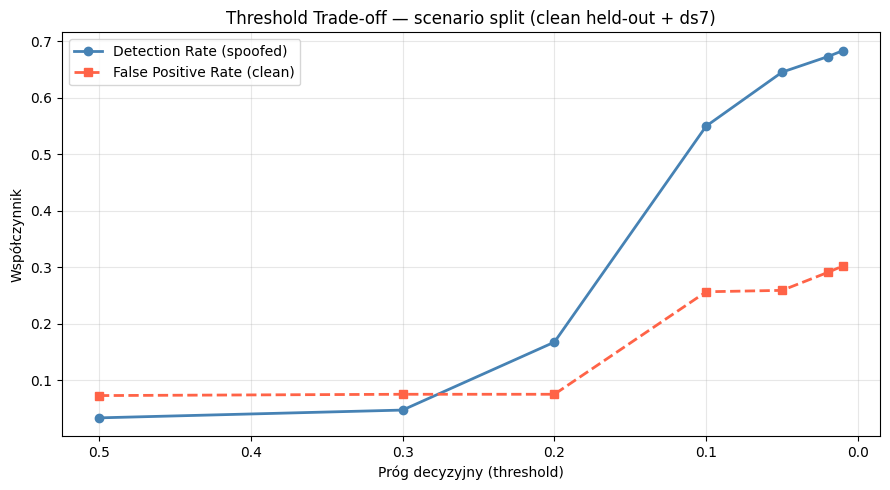

Próg z najlepszym DR-FPR: 0.05
  Detection Rate: 0.6456
  FPR:            0.2590


In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df['threshold'], threshold_df['detection_rate_spoof'],
        'o-', color='steelblue', linewidth=2, label='Detection Rate (spoofed)')
ax.plot(threshold_df['threshold'], threshold_df['false_positive_rate_clean'],
        's--', color='tomato', linewidth=2, label='False Positive Rate (clean)')
ax.set_xlabel('Próg decyzyjny (threshold)')
ax.set_ylabel('Współczynnik')
ax.set_title('Threshold Trade-off — scenario split (clean held-out + ds7)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()  # Malejący próg → rosnąca czułość
plt.tight_layout()
plt.show()

# Próg z najlepszym kompromisem (max DR - FPR)
threshold_df['dr_minus_fpr'] = threshold_df['detection_rate_spoof'] - threshold_df['false_positive_rate_clean']
best_thresh_row = threshold_df.loc[threshold_df['dr_minus_fpr'].idxmax()]
print(f"Próg z najlepszym DR-FPR: {best_thresh_row['threshold']}")
print(f"  Detection Rate: {best_thresh_row['detection_rate_spoof']:.4f}")
print(f"  FPR:            {best_thresh_row['false_positive_rate_clean']:.4f}")


## SEKCJA 9c: Rozkład prawdopodobieństwa spoofingu — cleanStatic vs ds7

Histogram `proba_spoof` osobno dla cleanStatic (held-out) i ds7.  
- Jeśli rozkład ds7 jest przesunięty w prawo względem cleanStatic → model widzi podwyższone ryzyko, nawet jeśli próg 0.5 jest zbyt wysoki  
- Jeśli rozkłady mocno się pokrywają → ds7 jest trudny do odróżnienia tym zestawem cech


Statystyki proba_spoof per scenario:
               count    mean     std  min  25%     50%     75%     max
scenario                                                              
cleanStatic  12334.0  0.0776  0.1797  0.0  0.0  0.0000  0.1167  0.8267
ds7          32732.0  0.1213  0.1368  0.0  0.0  0.1233  0.1800  0.9167


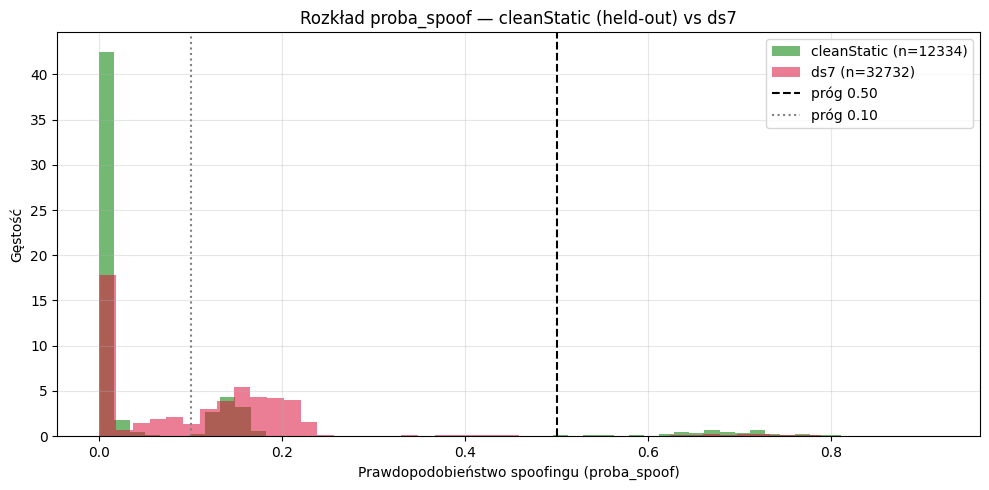

In [15]:
import matplotlib.pyplot as plt

# proba_df — indeksowany jak X_test_sc
proba_df = pd.DataFrame({
    'scenario': sc_test_sc.values,
    'y_true': y_test_sc.values,
    'proba_spoof': proba_sc,
}, index=X_test_sc.index)

# Dodaj time_bin (tylko do wykresów)
if 'time_bin' in df.columns:
    proba_df['time_bin'] = df.loc[X_test_sc.index, 'time_bin'].values

print("Statystyki proba_spoof per scenario:")
print(proba_df.groupby('scenario')['proba_spoof'].describe().round(4))

# Histogram
fig, ax = plt.subplots(figsize=(10, 5))
for sc_name, color in [('cleanStatic', 'green'), ('ds7', 'crimson')]:
    subset = proba_df[proba_df['scenario'] == sc_name]['proba_spoof']
    if len(subset) > 0:
        ax.hist(subset, bins=50, alpha=0.55, density=True,
                color=color, label=f'{sc_name} (n={len(subset)})')

ax.axvline(0.5,  color='black', linestyle='--', linewidth=1.5, label='próg 0.50')
ax.axvline(0.10, color='gray',  linestyle=':',  linewidth=1.5, label='próg 0.10')
ax.set_xlabel('Prawdopodobieństwo spoofingu (proba_spoof)')
ax.set_ylabel('Gęstość')
ax.set_title('Rozkład proba_spoof — cleanStatic (held-out) vs ds7')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## SEKCJA 9d: Prawdopodobieństwo spoofingu w czasie — ds7

Wizualizacja `proba_spoof` po czasie dla scenariusza ds7.  
- ds7 może być scenariuszem time-push — efekt ataku narasta w czasie  
- Pojedynczy globalny recall może ukrywać moment, w którym atak zaczyna być widoczny  
- `time_bin` używamy **tylko do wykresu**, nie jako feature modelu


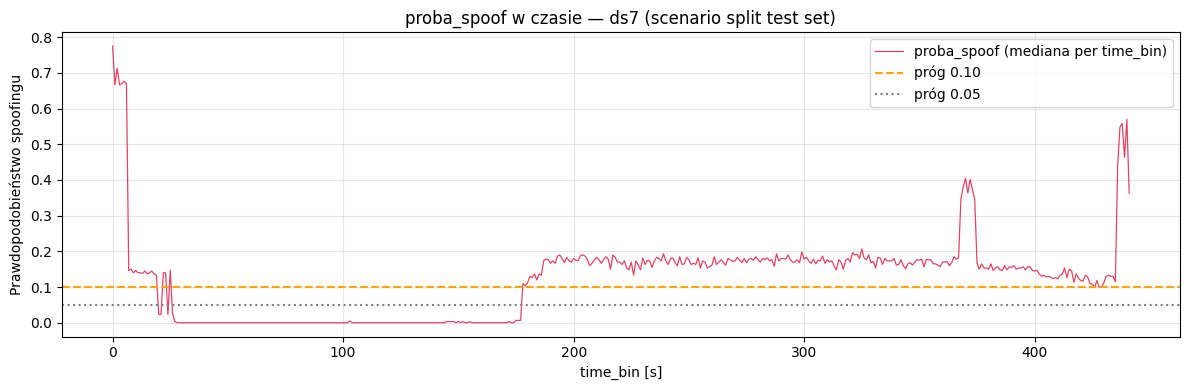

Mediana proba_spoof dla ds7:          0.1233
Odsetek rekordów ds7 z proba >= 0.10: 0.5500  (55.0%)
Odsetek rekordów ds7 z proba >= 0.05: 0.6456 (64.6%)


In [16]:
import matplotlib.pyplot as plt

proba_df_ds7 = proba_df[proba_df['scenario'] == 'ds7'].copy()

if 'time_bin' in proba_df_ds7.columns:
    proba_df_ds7 = proba_df_ds7.sort_values('time_bin')
    # Agreguj medianę per time_bin (jeden punkt per chwila czasu)
    plot_grp = proba_df_ds7.groupby('time_bin')['proba_spoof'].median().reset_index()
    x_vals  = plot_grp['time_bin']
    y_vals  = plot_grp['proba_spoof']
    x_label = 'time_bin [s]'
else:
    proba_df_ds7 = proba_df_ds7.reset_index(drop=True)
    x_vals  = proba_df_ds7.index
    y_vals  = proba_df_ds7['proba_spoof']
    x_label = 'Indeks wiersza (sortowanie wg scenario)'

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x_vals, y_vals, color='crimson', linewidth=0.9, alpha=0.8, label='proba_spoof (mediana per time_bin)')
ax.axhline(0.10, color='orange', linestyle='--', linewidth=1.5, label='próg 0.10')
ax.axhline(0.05, color='gray',   linestyle=':',  linewidth=1.5, label='próg 0.05')
ax.set_xlabel(x_label)
ax.set_ylabel('Prawdopodobieństwo spoofingu')
ax.set_title('proba_spoof w czasie — ds7 (scenario split test set)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

med_ds7 = proba_df_ds7['proba_spoof'].median()
pct_01  = (proba_df_ds7['proba_spoof'] >= 0.10).mean()
pct_005 = (proba_df_ds7['proba_spoof'] >= 0.05).mean()
print(f"Mediana proba_spoof dla ds7:          {med_ds7:.4f}")
print(f"Odsetek rekordów ds7 z proba >= 0.10: {pct_01:.4f}  ({pct_01*100:.1f}%)")
print(f"Odsetek rekordów ds7 z proba >= 0.05: {pct_005:.4f} ({pct_005*100:.1f}%)")


## SEKCJA 9e: Temporal smoothing alarm

W realnym systemie GPS alarm nie powinien wyzwalać się od jednego rekordu — powinien zależeć od **utrzymującego się podwyższonego ryzyka** w czasie.

Strategia:
1. `raw_alarm` = `proba_spoof >= RISK_THRESHOLD` (alarm per rekord)  
2. `rolling_alarm_rate` = krocząca średnia `raw_alarm` w oknie czasowym  
3. `smoothed_alarm` = alarm, gdy `rolling_alarm_rate >= ALARM_RATE_THRESHOLD`

Temporal smoothing redukuje losowe fałszywe alarmy kosztem opóźnienia wykrycia.


In [17]:
RISK_THRESHOLD       = 0.10
ROLLING_WINDOW       = 10
ALARM_RATE_THRESHOLD = 0.50

proba_df['raw_alarm'] = (proba_df['proba_spoof'] >= RISK_THRESHOLD).astype(int)

if 'time_bin' in proba_df.columns:
    proba_df_sorted = proba_df.sort_values(['scenario', 'time_bin']).copy()
else:
    proba_df_sorted = proba_df.sort_values(['scenario']).copy()

proba_df_sorted['rolling_alarm_rate'] = (
    proba_df_sorted
    .groupby('scenario')['raw_alarm']
    .transform(lambda s: s.rolling(window=ROLLING_WINDOW, min_periods=1).mean())
)
proba_df_sorted['smoothed_alarm'] = (
    proba_df_sorted['rolling_alarm_rate'] >= ALARM_RATE_THRESHOLD
).astype(int)

y_true_smooth = proba_df_sorted['y_true'].values

print(f"Parametry: RISK_THRESHOLD={RISK_THRESHOLD}, ROLLING_WINDOW={ROLLING_WINDOW}, "
      f"ALARM_RATE_THRESHOLD={ALARM_RATE_THRESHOLD}\n")

smooth_results = []
for alarm_col, label in [('raw_alarm', 'Raw alarm (per rekord)'),
                          ('smoothed_alarm', f'Smoothed alarm (okno={ROLLING_WINDOW})')]:
    y_pred_s = proba_df_sorted[alarm_col].values
    cm_s = confusion_matrix(y_true_smooth, y_pred_s, labels=[0, 1])
    tn, fp, fn, tp = cm_s.ravel()
    dr_s  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr_s = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    print(f"--- {label} ---")
    print(f"  Confusion Matrix (TN={tn}, FP={fp}, FN={fn}, TP={tp})")
    print(f"  Detection Rate:      {dr_s:.4f}")
    print(f"  False Positive Rate: {fpr_s:.4f}")
    print(f"  Liczba alarmów:      {int(y_pred_s.sum())}\n")
    smooth_results.append({'alarm': label, 'DR': dr_s, 'FPR': fpr_s,
                            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp})

df_smooth = pd.DataFrame(smooth_results)
display(df_smooth[['alarm', 'TN', 'FP', 'FN', 'TP', 'DR', 'FPR']])


Parametry: RISK_THRESHOLD=0.1, ROLLING_WINDOW=10, ALARM_RATE_THRESHOLD=0.5

--- Raw alarm (per rekord) ---
  Confusion Matrix (TN=9170, FP=3164, FN=14730, TP=18002)
  Detection Rate:      0.5500
  False Positive Rate: 0.2565
  Liczba alarmów:      21166

--- Smoothed alarm (okno=10) ---
  Confusion Matrix (TN=9163, FP=3171, FN=13099, TP=19633)
  Detection Rate:      0.5998
  False Positive Rate: 0.2571
  Liczba alarmów:      22804



,alarm,TN,FP,FN,TP,DR,FPR
0,Raw alarm (per rekord),9170,3164,14730,18002,0.549982,0.256527
1,Smoothed alarm (okno=10),9163,3171,13099,19633,0.599811,0.257094


## SEKCJA 9f: IsolationForest — anomaly detection baseline

Pytanie: czy ds7 da się wykryć jako **anomalię** względem czystego sygnału, bez uczenia się konkretnych wzorców ds2/ds3?

- **Trening:** tylko cleanStatic z `clean_train_eps` (bez żadnych etykiet spoofingu)  
- **Test:** cleanStatic held-out + ds7  
- Wyższy parametr `contamination` → więcej rekordów traktowanych jako anomalia → wyższy DR, ale też wyższy FPR  
- IsolationForest: `1 = normal`, `-1 = anomalia` → mapujemy: `-1 → 1 (spoofing)`


In [18]:
from sklearn.ensemble import IsolationForest

# Train: cleanStatic z epizodów train
mask_if_train = (df['scenario'] == 'cleanStatic') & (df['episode_id'].isin(clean_train_eps))
X_if_train = X_strict[mask_if_train]

# Test: ten sam co scenario split
X_if_test  = X_test_sc.copy()
y_if_test  = y_test_sc.values
sc_if_test = sc_test_sc.values

print(f"IF train (cleanStatic, held-out episodes): {X_if_train.shape}")
print(f"IF test  (cleanStatic test eps + ds7):     {X_if_test.shape}")
print(f"Target test: {pd.Series(y_if_test).value_counts().to_dict()}")

contaminations = [0.01, 0.02, 0.05, 0.10, 0.20, 0.30]
iforest_results = []

for cont in contaminations:
    pipe_if = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('iforest', IsolationForest(
            contamination=cont, random_state=42,
            n_estimators=300, n_jobs=-1
        ))
    ])
    pipe_if.fit(X_if_train)
    pred_raw = pipe_if.predict(X_if_test)
    y_pred_if = (pred_raw == -1).astype(int)  # anomalia = spoofing

    cm_if = confusion_matrix(y_if_test, y_pred_if, labels=[0, 1])
    tn, fp, fn, tp = cm_if.ravel()
    dr_if   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr_if  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    prec_if = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    iforest_results.append({
        'contamination': cont,
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
        'detection_rate_spoof':    round(dr_if,   4),
        'false_positive_rate_clean': round(fpr_if, 4),
        'precision_spoof':         round(prec_if, 4),
        'n_alarms': int(y_pred_if.sum()),
    })
    print(f"contamination={cont:.2f} → DR={dr_if:.4f}, FPR={fpr_if:.4f}")

iforest_results_df = pd.DataFrame(iforest_results)
print("\nIsolationForest wyniki:")
display(iforest_results_df)


IF train (cleanStatic, held-out episodes): (19558, 34)
IF test  (cleanStatic test eps + ds7):     (45066, 34)
Target test: {1: 32732, 0: 12334}
contamination=0.01 → DR=0.0968, FPR=0.2355
contamination=0.02 → DR=0.1282, FPR=0.2895
contamination=0.05 → DR=0.1876, FPR=0.3099
contamination=0.10 → DR=0.2956, FPR=0.3384
contamination=0.20 → DR=0.4428, FPR=0.4100
contamination=0.30 → DR=0.5799, FPR=0.4759

IsolationForest wyniki:


,contamination,TN,FP,FN,TP,detection_rate_spoof,false_positive_rate_clean,precision_spoof,n_alarms
0,0.01,9429,2905,29562,3170,0.0968,0.2355,0.5218,6075
1,0.02,8763,3571,28535,4197,0.1282,0.2895,0.5403,7768
2,0.05,8512,3822,26591,6141,0.1876,0.3099,0.6164,9963
3,0.10,8160,4174,23057,9675,0.2956,0.3384,0.6986,13849
4,0.20,7277,5057,18239,14493,0.4428,0.4100,0.7413,19550
5,0.30,6464,5870,13752,18980,0.5799,0.4759,0.7638,24850


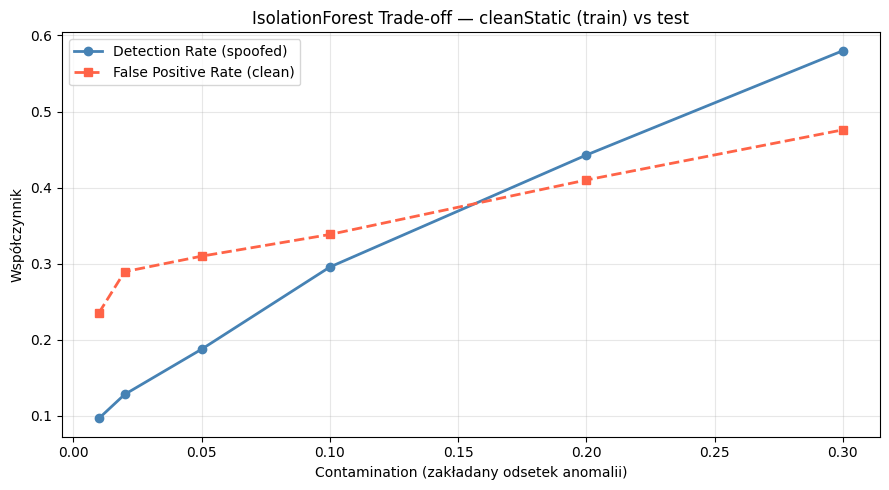

RF threshold sweep (dla porównania):
 threshold  detection_rate_spoof  false_positive_rate_clean
      0.50                0.0331                     0.0726
      0.30                0.0469                     0.0749
      0.20                0.1673                     0.0749
      0.10                0.5500                     0.2565
      0.05                0.6456                     0.2590
      0.02                0.6730                     0.2907
      0.01                0.6836                     0.3021

IsolationForest:
 contamination  detection_rate_spoof  false_positive_rate_clean
          0.01                0.0968                     0.2355
          0.02                0.1282                     0.2895
          0.05                0.1876                     0.3099
          0.10                0.2956                     0.3384
          0.20                0.4428                     0.4100
          0.30                0.5799                     0.4759


In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(iforest_results_df['contamination'], iforest_results_df['detection_rate_spoof'],
        'o-', color='steelblue', linewidth=2, label='Detection Rate (spoofed)')
ax.plot(iforest_results_df['contamination'], iforest_results_df['false_positive_rate_clean'],
        's--', color='tomato', linewidth=2, label='False Positive Rate (clean)')
ax.set_xlabel('Contamination (zakładany odsetek anomalii)')
ax.set_ylabel('Współczynnik')
ax.set_title('IsolationForest Trade-off — cleanStatic (train) vs test')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Porównanie z RF przy podobnym FPR
print("RF threshold sweep (dla porównania):")
print(threshold_df[['threshold','detection_rate_spoof','false_positive_rate_clean']].to_string(index=False))
print("\nIsolationForest:")
print(iforest_results_df[['contamination','detection_rate_spoof','false_positive_rate_clean']].to_string(index=False))


## SEKCJA 9g: Combined alarm — OR i AND ensemble

Łączymy supervised RF (threshold) z IsolationForest (anomaly).  
- **OR:** alarm gdy RF OR IF sygnalizuje → wyższa czułość, możliwy wyższy FPR  
- **AND:** alarm gdy RF AND IF sygnalizują → niższy FPR, możliwy niższy DR  
W systemie bezpieczeństwa wariant dobiera się do wymagań operacyjnych.


In [20]:
# Wybierz parametry
RF_THRESHOLD = 0.10

# Najlepszy contamination przy FPR <= 0.15
_if_candidates = iforest_results_df[iforest_results_df['false_positive_rate_clean'] <= 0.15]
IF_CONTAMINATION = (
    _if_candidates.sort_values('detection_rate_spoof', ascending=False).iloc[0]['contamination']
    if len(_if_candidates) > 0 else 0.05
)
print(f"Wybrane parametry: RF threshold={RF_THRESHOLD}, IF contamination={IF_CONTAMINATION}")

# RF alarm na scenario split test
rf_alarm = (proba_sc >= RF_THRESHOLD).astype(int)

# IF alarm — trenuj na cleanStatic train, testuj na X_test_sc
pipe_if_comb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('iforest', IsolationForest(
        contamination=IF_CONTAMINATION, random_state=42,
        n_estimators=300, n_jobs=-1
    ))
])
pipe_if_comb.fit(X_if_train)
pred_raw_comb = pipe_if_comb.predict(X_test_sc)
if_alarm = (pred_raw_comb == -1).astype(int)

combined_alarm_or  = ((rf_alarm == 1) | (if_alarm  == 1)).astype(int)
combined_alarm_and = ((rf_alarm == 1) & (if_alarm  == 1)).astype(int)

y_true_comb = y_test_sc.values
print("\n=== Porównanie strategii alarmowania ===")
comb_results = []
for arr, label in [
    (rf_alarm,           f'RF only  (threshold={RF_THRESHOLD})'),
    (if_alarm,           f'IF only  (contamination={IF_CONTAMINATION})'),
    (combined_alarm_or,  'OR ensemble  (RF | IF)'),
    (combined_alarm_and, 'AND ensemble (RF & IF)'),
]:
    cm_c = confusion_matrix(y_true_comb, arr, labels=[0, 1])
    tn, fp, fn, tp = cm_c.ravel()
    dr_c  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr_c = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    print(f"\n  [{label}]")
    print(f"    CM:              TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"    Detection Rate:  {dr_c:.4f}")
    print(f"    FPR:             {fpr_c:.4f}")
    comb_results.append({'strategia': label, 'DR': round(dr_c,4), 'FPR': round(fpr_c,4),
                         'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp})

df_comb = pd.DataFrame(comb_results)
print("\nPodsumowanie combined alarm:")
display(df_comb[['strategia','TN','FP','FN','TP','DR','FPR']])


Wybrane parametry: RF threshold=0.1, IF contamination=0.05

=== Porównanie strategii alarmowania ===

  [RF only  (threshold=0.1)]
    CM:              TN=9170, FP=3164, FN=14730, TP=18002
    Detection Rate:  0.5500
    FPR:             0.2565

  [IF only  (contamination=0.05)]
    CM:              TN=8512, FP=3822, FN=26591, TP=6141
    Detection Rate:  0.1876
    FPR:             0.3099

  [OR ensemble  (RF | IF)]
    CM:              TN=8512, FP=3822, FN=12626, TP=20106
    Detection Rate:  0.6143
    FPR:             0.3099

  [AND ensemble (RF & IF)]
    CM:              TN=9170, FP=3164, FN=28695, TP=4037
    Detection Rate:  0.1233
    FPR:             0.2565

Podsumowanie combined alarm:


,strategia,TN,FP,FN,TP,DR,FPR
0,RF only (threshold=0.1),9170,3164,14730,18002,0.5500,0.2565
1,IF only (contamination=0.05),8512,3822,26591,6141,0.1876,0.3099
2,OR ensemble (RF | IF),8512,3822,12626,20106,0.6143,0.3099
3,AND ensemble (RF & IF),9170,3164,28695,4037,0.1233,0.2565


## SEKCJA 10: ds7-only stress test

**Czysty test wykrywalności ds7.** Trenujemy na `cleanStatic + ds2 + ds3`, testujemy **wyłącznie na ds7**.

**Różnica od Sekcji 9:**
- Tutaj tren zawiera **wszystkie** epizody cleanStatic (nie tylko 70%)
- Test zawiera **wyłącznie** próbki ds7 (tylko klasa spoofing = 1)
- Nie jest to pełna ewaluacja binarna — mierzymy tylko **detection rate** spoofingu

**Cel:** Sprawdzić, jak wiele próbek ds7 model klasyfikuje poprawnie jako spoofed, gdy ma do dyspozycji maksimum danych treningowych.

**Spodziewany wynik:** ~0.6% — model praktycznie nie wykrywa ds7.


In [21]:
mask_train_stress = df['scenario'].isin(['cleanStatic', 'ds2', 'ds3'])
mask_test_stress  = df['scenario'] == 'ds7'

X_train_stress = X_strict[mask_train_stress]
y_train_stress = y[mask_train_stress]
X_test_stress  = X_strict[mask_test_stress]
y_test_stress  = y[mask_test_stress]

print(f"Train: {X_train_stress.shape} | scenariusze: {scenario[mask_train_stress].value_counts().to_dict()}")
print(f"Test (ds7-only): {X_test_stress.shape}")
print(f"Wszystkie próbki ds7 mają label=1: {(y_test_stress == 1).all()}")

model_stress = make_rf()
model_stress.fit(X_train_stress, y_train_stress)
y_pred_stress = model_stress.predict(X_test_stress)

detected = (y_pred_stress == 1).sum()
total = len(y_test_stress)
dr_stress = recall_score(y_test_stress, y_pred_stress, pos_label=1)

print(f"\nLiczba próbek ds7: {total}")
print(f"Wykrytych jako spoofed: {detected}")
print(f"Detection Rate ds7: {dr_stress:.4f} ({dr_stress*100:.2f}%)")


Train: (94987, 34) | scenariusze: {'cleanStatic': 31892, 'ds3': 31892, 'ds2': 31203}
Test (ds7-only): (32732, 34)
Wszystkie próbki ds7 mają label=1: True

Liczba próbek ds7: 32732
Wykrytych jako spoofed: 185
Detection Rate ds7: 0.0057 (0.57%)


## SEKCJA 11: Leave-one-spoof-scenario-out

**Systematyczny test generalizacji.** Dla każdego scenariusza spoofingu (`ds2`, `ds3`, `ds7`) trenujemy na `cleanStatic` + pozostałe scenariusze spoofingu, testujemy na pominiętym.

**Cel:** Sprawdzić, czy słaba wykrywalność ds7 jest specyficzna dla tego scenariusza, czy ogólny problem modelu.

**Oczekiwane wyniki (znane z wcześniejszej analizy):**
- ds2 (pominięty): ~98.6% detection rate — ds2 jest bardzo podobny do ds3
- ds3 (pominięty): ~98.3% detection rate — ds3 jest bardzo podobny do ds2
- ds7 (pominięty): ~0.6% detection rate — ds7 ma fundamentalnie inne cechy

**Wnioski:**
- ds2 i ds3 mają podobny wzorzec sygnału — cross-generalizacja jest dobra
- ds7 jest jakościowo inny — cechy sygnału, którymi model wykrywa ds2/ds3, nie działają dla ds7
- Konieczna jest inżynieria cech specyficznych dla ds7 lub algorytm detekcji anomalii


In [22]:
all_spoof_scenarios = ['ds2', 'ds3', 'ds7']
results_loso = []

print("Leave-one-spoof-scenario-out:\n")
for test_sc in all_spoof_scenarios:
    train_scenarios_loso = ['cleanStatic'] + [s for s in all_spoof_scenarios if s != test_sc]

    mask_tr = df['scenario'].isin(train_scenarios_loso)
    mask_te = df['scenario'] == test_sc

    X_tr = X_strict[mask_tr]
    y_tr = y[mask_tr]
    X_te = X_strict[mask_te]
    y_te = y[mask_te]

    model_loso = make_rf()
    model_loso.fit(X_tr, y_tr)
    y_pred_loso = model_loso.predict(X_te)

    detected_loso = (y_pred_loso == 1).sum()
    n_loso = len(y_te)
    dr_loso = recall_score(y_te, y_pred_loso, pos_label=1)

    print(f"  Test: {test_sc} | n={n_loso} | wykryto={detected_loso} | detection_rate={dr_loso:.4f}")
    results_loso.append({
        'test_scenario': test_sc,
        'train_scenarios': ', '.join(train_scenarios_loso),
        'n_test_samples': n_loso,
        'detected_as_spoofed': detected_loso,
        'detection_rate': round(dr_loso, 4)
    })

df_loso = pd.DataFrame(results_loso)
print("\nPodsumowanie Leave-one-spoof-scenario-out:")
display(df_loso)

# Komentarz
if df_loso.loc[df_loso['test_scenario'] == 'ds7', 'detection_rate'].values[0] < 0.1:
    print("\n[!] Problem generalizacji dotyczy specyficznie ds7.")
    print("    ds2 i ds3 są wykrywane dobrze (>0.9), ale ds7 ma zupełnie inne cechy sygnału,")
    print("    których model wytrenowany na ds2/ds3 nie potrafi rozpoznać.")


Leave-one-spoof-scenario-out:

  Test: ds2 | n=31203 | wykryto=30928 | detection_rate=0.9912
  Test: ds3 | n=31892 | wykryto=31361 | detection_rate=0.9834
  Test: ds7 | n=32732 | wykryto=185 | detection_rate=0.0057

Podsumowanie Leave-one-spoof-scenario-out:


,test_scenario,train_scenarios,n_test_samples,detected_as_spoofed,detection_rate
0,ds2,"cleanStatic, ds3, ds7",31203,30928,0.9912
1,ds3,"cleanStatic, ds2, ds7",31892,31361,0.9834
2,ds7,"cleanStatic, ds2, ds3",32732,185,0.0057



[!] Problem generalizacji dotyczy specyficznie ds7.
    ds2 i ds3 są wykrywane dobrze (>0.9), ale ds7 ma zupełnie inne cechy sygnału,
    których model wytrenowany na ds2/ds3 nie potrafi rozpoznać.


## SEKCJA 12: Porównanie modeli

Porównujemy trzy modele klasyfikacji:
- `LogisticRegression` — prosty model liniowy, szybki, interpretowalny
- `RandomForest` — silny model zespołowy, odporny na outliers
- `GradientBoosting` — inny model zespołowy, często najlepsza dokładność

Oceniamy na czterech podziałach:
1. `random_split` — baseline optymistyczny
2. `group_split_episode` — podział po epizodach
3. `scenario_split_ds7` — heldout cleanStatic + niewidziany ds7
4. `ds7_stress` — test wyłącznie na ds7

**Brak strojenia hiperparametrów** — używamy domyślnych ustawień z fabryk.


In [23]:
results_models = []

splits = {
    'random_split': (X_train_rand, y_train_rand, X_test_rand, y_test_rand),
    'group_split_episode': (X_train_grp, y_train_grp, X_test_grp, y_test_grp),
    'scenario_split_ds7': (X_train_sc, y_train_sc, X_test_sc, y_test_sc),
    'ds7_stress': (X_train_stress, y_train_stress, X_test_stress, y_test_stress),
}

model_factories = {
    'LogisticRegression': make_logreg,
    'RandomForest': make_rf,
    'GradientBoosting': make_gb,
}

for split_name, (Xtr, ytr, Xte, yte) in splits.items():
    for model_name, factory in model_factories.items():
        print(f"\nTrenuję {model_name} na {split_name}...")
        m = factory()
        m.fit(Xtr, ytr)
        yp = m.predict(Xte)
        acc = accuracy_score(yte, yp)
        yte_vals = yte.unique() if hasattr(yte, 'unique') else np.unique(yte)
        spoof_r = recall_score(yte, yp, pos_label=1) if 1 in yte_vals else np.nan
        cm_ = confusion_matrix(yte, yp, labels=[0, 1])
        if 0 in yte_vals and cm_.shape[0] >= 2:
            fpr_ = cm_[0,1] / (cm_[0,0] + cm_[0,1]) if (cm_[0,0]+cm_[0,1]) > 0 else np.nan
        else:
            fpr_ = np.nan
        results_models.append({
            'model': model_name,
            'split': split_name,
            'accuracy': round(acc, 4),
            'spoof_recall': round(spoof_r, 4) if not np.isnan(spoof_r) else None,
            'false_positive_rate': round(fpr_, 4) if not np.isnan(fpr_) else None,
        })

df_models = pd.DataFrame(results_models)
print("\n=== Porównanie modeli ===")
display(df_models.pivot_table(
    index=['split', 'model'],
    values=['accuracy', 'spoof_recall', 'false_positive_rate']
))



Trenuję LogisticRegression na random_split...

Trenuję RandomForest na random_split...

Trenuję GradientBoosting na random_split...

Trenuję LogisticRegression na group_split_episode...

Trenuję RandomForest na group_split_episode...

Trenuję GradientBoosting na group_split_episode...

Trenuję LogisticRegression na scenario_split_ds7...

Trenuję RandomForest na scenario_split_ds7...

Trenuję GradientBoosting na scenario_split_ds7...

Trenuję LogisticRegression na ds7_stress...

Trenuję RandomForest na ds7_stress...

Trenuję GradientBoosting na ds7_stress...

=== Porównanie modeli ===


accuracy  false_positive_rate  \
split               model                                               
ds7_stress          GradientBoosting      0.0088                  NaN   
                    LogisticRegression    0.0079                  NaN   
                    RandomForest          0.0057                  NaN   
group_split_episode GradientBoosting      0.7773               0.0303   
                    LogisticRegression    0.7065               0.3640   
                    RandomForest          0.7616               0.1484   
random_split        GradientBoosting      0.9374               0.1654   
                    LogisticRegression    0.8791               0.0326   
                    RandomForest          0.9115               0.1706   
scenario_split_ds7  GradientBoosting      0.2804               0.0733   
                    LogisticRegression    0.2761               0.0298   
                    RandomForest          0.2778               0.0723   

                                        spoof_recall  
split               model                             
ds7_stress          GradientBoosting          0.0088  
                    LogisticRegression        0.0079  
                    RandomForest              0.0057  
group_split_episode GradientBoosting          0.6637  
                    LogisticRegression        0.7480  
                    RandomForest              0.7086  
random_split        GradientBoosting          0.9717  
                    LogisticRegression        0.8498  
                    RandomForest              0.9389  
scenario_split_ds7  GradientBoosting          0.0368  
                    LogisticRegression        0.0146  
                    RandomForest              0.0329

## SEKCJA 13: Strict vs Extended — analiza potencjalnego leakage

Porównujemy RF wytrenowany na `X_strict` z RF na `X_extended`.

**Hipoteza:** Jeśli `X_extended` znacząco poprawia wyniki, to `txid` i/lub `signal_type` działają jako ukryte identyfikatory scenariusza (leakage).

**Dlaczego to ważne:**
- Jeśli np. ds7 używa innych `txid` niż ds2/ds3, model może nauczyć się identyfikować scenariusz przez `txid`, a nie przez cechy sygnału
- Taki model nie generalizuje do nowych scenariuszy

**Próg ostrzeżenia:** Jeśli extended lepszy o >5% recall w którymkolwiek podziale — flaga leakage.


In [24]:
results_feat = []

splits_feat = {
    'group_split_episode': (
        X_strict.iloc[train_idx], y.iloc[train_idx], X_strict.iloc[test_idx], y.iloc[test_idx],
        X_extended.iloc[train_idx], y.iloc[train_idx], X_extended.iloc[test_idx], y.iloc[test_idx],
    ),
    'scenario_split_ds7': (
        X_strict[mask_train_sc], y[mask_train_sc], X_strict[mask_test_sc], y[mask_test_sc],
        X_extended[mask_train_sc], y[mask_train_sc], X_extended[mask_test_sc], y[mask_test_sc],
    ),
    'ds7_stress': (
        X_strict[mask_train_stress], y[mask_train_stress], X_strict[mask_test_stress], y[mask_test_stress],
        X_extended[mask_train_stress], y[mask_train_stress], X_extended[mask_test_stress], y[mask_test_stress],
    ),
}

for split_name, data in splits_feat.items():
    Xtr_s, ytr_s, Xte_s, yte_s, Xtr_e, ytr_e, Xte_e, yte_e = data
    for feat_name, Xtr, ytr, Xte, yte in [
        ('strict', Xtr_s, ytr_s, Xte_s, yte_s),
        ('extended', Xtr_e, ytr_e, Xte_e, yte_e),
    ]:
        print(f"RF | {feat_name} | {split_name}...")
        m = make_rf()
        m.fit(Xtr, ytr)
        yp = m.predict(Xte)
        acc = accuracy_score(yte, yp)
        yte_vals = yte.unique() if hasattr(yte, 'unique') else np.unique(yte)
        spoof_r = recall_score(yte, yp, pos_label=1) if 1 in yte_vals else np.nan
        cm_ = confusion_matrix(yte, yp, labels=[0, 1])
        if 0 in yte_vals and cm_.shape[0] >= 2:
            fpr_ = cm_[0,1] / (cm_[0,0]+cm_[0,1]) if (cm_[0,0]+cm_[0,1]) > 0 else np.nan
        else:
            fpr_ = np.nan
        results_feat.append({
            'feature_set': feat_name,
            'split': split_name,
            'accuracy': round(acc, 4),
            'spoof_recall': round(spoof_r, 4) if not np.isnan(spoof_r) else None,
            'false_positive_rate': round(fpr_, 4) if not np.isnan(fpr_) else None,
        })

df_feat = pd.DataFrame(results_feat)
print("\n=== Strict vs Extended ===")
display(df_feat)

# Ostrzeżenie o leakage
for split_name in df_feat['split'].unique():
    sub = df_feat[df_feat['split'] == split_name]
    s_r = sub[sub['feature_set']=='strict']['spoof_recall'].values
    e_r = sub[sub['feature_set']=='extended']['spoof_recall'].values
    if len(s_r) and len(e_r) and e_r[0] is not None and s_r[0] is not None:
        diff_r = (e_r[0] or 0) - (s_r[0] or 0)
        if diff_r > 0.05:
            print(f"\n[OSTRZEŻENIE] W {split_name}: extended lepszy o {diff_r:.4f} recall.")
            print("  txid/signal_type mogą działać jak identyfikator scenariusza (leakage)!")


RF | strict | group_split_episode...
RF | extended | group_split_episode...
RF | strict | scenario_split_ds7...
RF | extended | scenario_split_ds7...
RF | strict | ds7_stress...
RF | extended | ds7_stress...

=== Strict vs Extended ===


,feature_set,split,accuracy,spoof_recall,false_positive_rate
0,strict,group_split_episode,0.7616,0.7086,0.1484
1,extended,group_split_episode,0.7624,0.6917,0.1178
2,strict,scenario_split_ds7,0.2778,0.0329,0.0723
3,extended,scenario_split_ds7,0.2778,0.0325,0.0713
4,strict,ds7_stress,0.0057,0.0057,NaN
5,extended,ds7_stress,0.0054,0.0054,NaN


## SEKCJA 14: Feature Importance

Analizujemy ważność cech modelu RandomForest wytrenowanego na `X_strict` (group split po episode_id).

**Uwagi techniczne:**
- Pipeline zawiera `SimpleImputer` → `RandomForestClassifier`
- Feature importance pobieramy z `pipeline.named_steps['clf']`
- Indeksy cech odpowiadają kolumnom `X_strict` (po imputacji kształt kolumn się nie zmienia)
- Sprawdzamy, czy żadna zakazana kolumna nie trafiła do top 20

**Interpretacja:** Cechy z wysoką ważnością to te, które RF najczęściej używa do podziału węzłów drzew. Wysoka ważność zakazanej kolumny wskazywałaby na błąd w pipeline.


Top 20 Feature Importance (RandomForest, X_strict, group split):


,feature,importance
0,clock_error_m,0.263114
1,latitude_delta_deg,0.189340
2,longitude_delta_deg,0.154167
3,clock_error_rate_mps,0.117289
4,height_delta_m,0.109905
5,distance_from_start_m,0.054827
6,psd_total_power,0.014256
7,iq_power_std,0.013737
8,iq_power_mean,0.011270
9,cn0_dbhz,0.008857


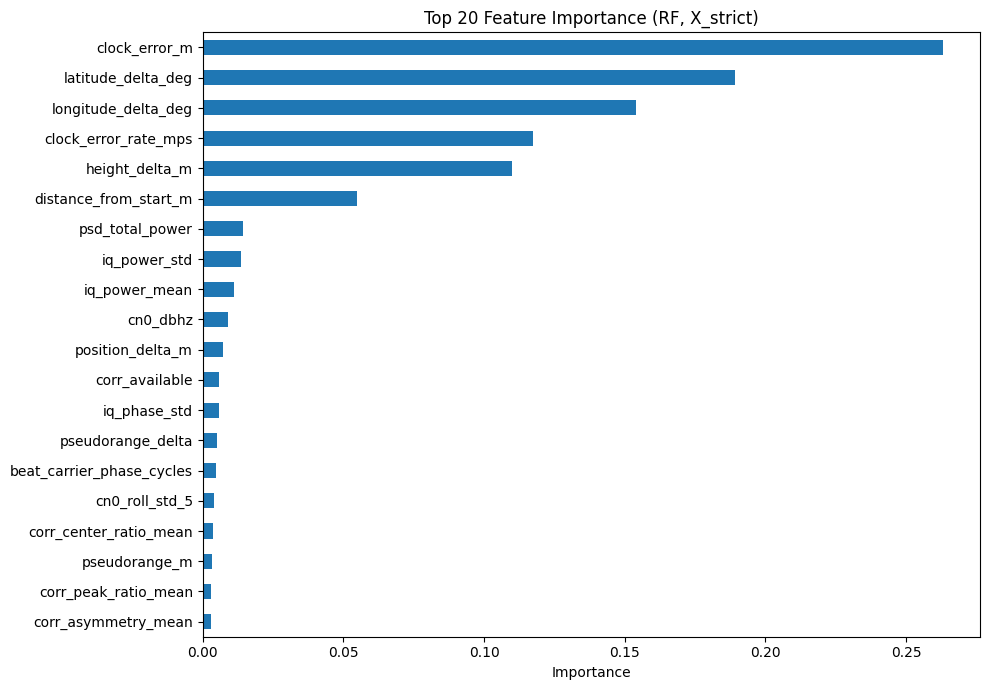


[OK] Brak zakazanych kolumn w top 20 feature importance.


In [25]:
import matplotlib.pyplot as plt

# Trenuj RF na group split (X_strict)
rf_for_fi = make_rf()
rf_for_fi.fit(X_train_grp, y_train_grp)

# Pobierz feature importance z pipeline
fi = rf_for_fi.named_steps['clf'].feature_importances_
fi_series = pd.Series(fi, index=X_strict.columns).sort_values(ascending=False)

print("Top 20 Feature Importance (RandomForest, X_strict, group split):")
display(
    fi_series.head(20)
    .reset_index()
    .rename(columns={'index': 'feature', 0: 'importance'})
)

# Wykres
fig, ax = plt.subplots(figsize=(10, 7))
fi_series.head(20).plot(kind='barh', ax=ax)
ax.set_xlabel('Importance')
ax.set_title('Top 20 Feature Importance (RF, X_strict)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Sprawdzenie zakazanych kolumn
forbidden_fi = {'scenario', 'label_spoofed_scenario', 'spoofing_detected_grid',
                'time_from_start_s', 'time_bin', 'episode_id', 'txid', 'signal_type',
                'ecef_x_m', 'ecef_y_m', 'ecef_z_m', 'latitude_deg', 'longitude_deg', 'height_m'}
forbidden_in_fi = forbidden_fi & set(fi_series.head(20).index)
if forbidden_in_fi:
    print(f"\n[OSTRZEŻENIE] Zakazane kolumny w top 20: {forbidden_in_fi}")
else:
    print("\n[OK] Brak zakazanych kolumn w top 20 feature importance.")


## SEKCJA 14b: Ablation study — wpływ cech nav/clock na wykrywanie ds7

Top feature importance w modelu `X_strict` są zdominowane przez cechy nawigacyjne i zegarowe (`clock_error_m`, `latitude_delta_deg`, `clock_error_rate_mps` itp.). Są one **merytorycznie uzasadnione** — spoofing GPS typowo zaburza rozwiązanie pozycji i zegar odbiornika. Jednak pojawia się pytanie: czy model nie opiera się *prawie wyłącznie* na dryfie znanych scenariuszy ds2/ds3, co utrudnia generalizację na ds7?

### Porównywane warianty cech

| Wariant | Opis |
|---|---|
| `strict_full` | Pełny X_strict bez zmian |
| `signal_only` | X_strict po usunięciu kolumn nav/clock/position |
| `nav_clock_only` | Tylko kolumny nav/clock (o ile istnieją w X_strict) |

### Ewaluowane splity

- **A: random** — baseline (optymistyczny)  
- **B: group_episode** — GroupShuffleSplit po episode_id  
- **C: scenario_split** — clean held-out + unseen ds7  
- **D: ds7_only** — stress test, test zawiera wyłącznie spoofed  

Dla scenariuszy C i D dodatkowy **threshold sweep** (`predict_proba`) z progami `[0.50, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01]`.


In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import confusion_matrix, accuracy_score

# ── Kolumny nav/clock do testowania ─────────────────────────────
_NAV_CLOCK_COLS = [
    'clock_error_m', 'clock_error_rate_mps',
    'latitude_delta_deg', 'longitude_delta_deg', 'height_delta_m',
    'distance_from_start_m', 'position_delta_m',
    'ecef_vx_mps', 'ecef_vy_mps', 'ecef_vz_mps',
    'velocity_norm_mps', 'speed_mps', 'solution_flag', 'nis_ratio',
]

nav_clock_in_strict = [c for c in _NAV_CLOCK_COLS if c in X_strict.columns]
signal_only_cols    = [c for c in X_strict.columns  if c not in nav_clock_in_strict]

print(f"Kolumny nav/clock w X_strict ({len(nav_clock_in_strict)}/{len(_NAV_CLOCK_COLS)}):")
print(nav_clock_in_strict)
print(f"\nKolumny signal-only ({len(signal_only_cols)}):")
print(signal_only_cols)

feature_sets = {"strict_full": X_strict}
if signal_only_cols:
    feature_sets["signal_only"] = X_strict[signal_only_cols].copy()
else:
    print("\n[POMINIĘTO] signal_only — brak kolumn po odcięciu nav/clock")
if nav_clock_in_strict:
    feature_sets["nav_clock_only"] = X_strict[nav_clock_in_strict].copy()
else:
    print("\n[POMINIĘTO] nav_clock_only — brak kolumn nav/clock w X_strict")

# ── Helper metryk ────────────────────────────────────────────────
def _row(y_true, y_pred, fs_name, split_type, n_features, n_train, n_test):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    cm_ = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm_.ravel()
    has_clean = 0 in np.unique(y_true)
    dr   = tp/(tp+fn)  if (tp+fn)>0  else None
    fpr  = fp/(fp+tn)  if (fp+tn)>0 and has_clean else None
    prec = tp/(tp+fp)  if (tp+fp)>0  else None
    acc  = float(accuracy_score(y_true, y_pred)) if has_clean else None
    def _r(v): return round(float(v), 4) if v is not None else None
    return {"feature_set": fs_name, "split_type": split_type,
            "n_features": n_features, "n_train": n_train, "n_test": n_test,
            "accuracy": _r(acc), "detection_rate_spoof": _r(dr),
            "false_positive_rate_clean": _r(fpr), "precision_spoof": _r(prec),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

# ── Przygotuj indeksy splitów RAZ (żeby identyczne dla wszystkich wariantów) ──
# A: random — użyj X_strict jako template indeksów
_Xr_tr, _Xr_te, _yr_tr, _yr_te = train_test_split(
    X_strict, y, test_size=0.2, random_state=42, stratify=y
)
_rand_tr_idx, _rand_te_idx = _Xr_tr.index, _Xr_te.index

# B: group
try:
    _ = episode_id
    _ep_ok = True
except NameError:
    _ep_ok = False

if _ep_ok:
    _gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    _gi_tr, _gi_te = next(_gss.split(X_strict, y, groups=episode_id))

# C: scenario split (używamy istniejących masek lub tworzymy)
try:
    _ = mask_train_sc, mask_test_sc
    _sc_ok = True
except NameError:
    _sc_ok = False

if not _sc_ok:
    print("\n[UWAGA] mask_train_sc/mask_test_sc niezdefiniowane — tworzę lokalne maski.")
    if _ep_ok:
        _ceps = sorted(df[df["scenario"] == "cleanStatic"]["episode_id"].unique())
        _ctr, _cte = train_test_split(_ceps, test_size=0.3, random_state=42)
        mask_train_sc = df["scenario"].isin(["ds2","ds3"]) | df["episode_id"].isin(set(_ctr))
        mask_test_sc  = (df["scenario"]=="ds7") | df["episode_id"].isin(set(_cte))
    else:
        print("[UWAGA] episode_id brak — prosty scenario split (mniej uczciwy).")
        mask_train_sc = df["scenario"].isin(["cleanStatic","ds2","ds3"])
        mask_test_sc  = df["scenario"].isin(["cleanStatic","ds7"])

# D: ds7-only
_mask_d_tr = df["scenario"].isin(["cleanStatic","ds2","ds3"])
_mask_d_te = df["scenario"] == "ds7"

# ── Główna pętla ablation ────────────────────────────────────────
ablation_rows = []
_abl_models   = {}   # {fs_name: {"sc": (model, Xte, yte), "ds7": (model, Xte, yte)}}

for fs_name, X_fs in feature_sets.items():
    n_feat = X_fs.shape[1]
    print(f"\n{'='*55}")
    print(f"Feature set: {fs_name!r}  ({n_feat} cech)")
    _abl_models[fs_name] = {}

    # A: random
    m_a = make_rf()
    m_a.fit(X_fs.loc[_rand_tr_idx], _yr_tr)
    yp_a = m_a.predict(X_fs.loc[_rand_te_idx])
    r_a  = _row(_yr_te, yp_a, fs_name, "random",
                n_feat, len(_rand_tr_idx), len(_rand_te_idx))
    ablation_rows.append(r_a)
    print(f"  A random:    DR={r_a['detection_rate_spoof']}, "
          f"FPR={r_a['false_positive_rate_clean']}, acc={r_a['accuracy']}")

    # B: group
    if _ep_ok:
        X_b_tr, y_b_tr = X_fs.iloc[_gi_tr], y.iloc[_gi_tr]
        X_b_te, y_b_te = X_fs.iloc[_gi_te], y.iloc[_gi_te]
        m_b = make_rf()
        m_b.fit(X_b_tr, y_b_tr)
        yp_b = m_b.predict(X_b_te)
        r_b  = _row(y_b_te, yp_b, fs_name, "group_episode",
                    n_feat, len(_gi_tr), len(_gi_te))
        ablation_rows.append(r_b)
        print(f"  B group:     DR={r_b['detection_rate_spoof']}, "
              f"FPR={r_b['false_positive_rate_clean']}")
    else:
        print("  B [POMINIĘTO] group split — episode_id niezdefiniowane")

    # C: scenario split
    X_c_tr, y_c_tr = X_fs[mask_train_sc], y[mask_train_sc]
    X_c_te, y_c_te = X_fs[mask_test_sc],  y[mask_test_sc]
    m_c = make_rf()
    m_c.fit(X_c_tr, y_c_tr)
    yp_c = m_c.predict(X_c_te)
    r_c  = _row(y_c_te, yp_c, fs_name, "scenario_split",
                n_feat, len(X_c_tr), len(X_c_te))
    ablation_rows.append(r_c)
    _abl_models[fs_name]["sc"] = (m_c, X_c_te, y_c_te)
    print(f"  C scenario:  DR={r_c['detection_rate_spoof']}, "
          f"FPR={r_c['false_positive_rate_clean']}")

    # D: ds7-only
    X_d_tr, y_d_tr = X_fs[_mask_d_tr], y[_mask_d_tr]
    X_d_te, y_d_te = X_fs[_mask_d_te], y[_mask_d_te]
    m_d = make_rf()
    m_d.fit(X_d_tr, y_d_tr)
    yp_d = m_d.predict(X_d_te)
    r_d  = _row(y_d_te, yp_d, fs_name, "ds7_only",
                n_feat, len(X_d_tr), len(X_d_te))
    ablation_rows.append(r_d)
    _abl_models[fs_name]["ds7"] = (m_d, X_d_te, y_d_te)
    print(f"  D ds7-only:  DR={r_d['detection_rate_spoof']}  "
          f"(test = tylko spoofed)")

_col_order = ["feature_set","split_type","n_features","n_train","n_test",
              "accuracy","detection_rate_spoof","false_positive_rate_clean",
              "precision_spoof","tn","fp","fn","tp"]
ablation_df = pd.DataFrame(ablation_rows)
ablation_df = ablation_df[[c for c in _col_order if c in ablation_df.columns]]

print("\n=== Ablation Study — Wyniki ===")
display(ablation_df)


Kolumny nav/clock w X_strict (7/14):
['clock_error_m', 'clock_error_rate_mps', 'latitude_delta_deg', 'longitude_delta_deg', 'height_delta_m', 'distance_from_start_m', 'position_delta_m']

Kolumny signal-only (27):
['cn0_dbhz', 'doppler_hz', 'pseudorange_m', 'beat_carrier_phase_cycles', 'pll_lock', 'dll_lock', 'cn0_delta', 'doppler_delta', 'pseudorange_delta', 'carrier_phase_delta', 'cn0_roll_std_5', 'doppler_roll_std_5', 'phase_tracking_anomaly', 'corr_peak_ratio_mean', 'corr_asymmetry_mean', 'corr_width_proxy_mean', 'corr_center_ratio_mean', 'iq_sample_count', 'iq_power_mean', 'iq_power_std', 'iq_phase_std', 'psd_total_power', 'psd_peak_ratio', 'psd_spectral_entropy', 'psd_flatness', 'psd_low_high_ratio', 'corr_available']

Feature set: 'strict_full'  (34 cech)
  A random:    DR=0.9389, FPR=0.1706, acc=0.9115
  B group:     DR=0.7086, FPR=0.1484
  C scenario:  DR=0.0329, FPR=0.0723
  D ds7-only:  DR=0.0057  (test = tylko spoofed)

Feature set: 'signal_only'  (27 cech)
  A random:    D

,feature_set,split_type,n_features,n_train,n_test,accuracy,detection_rate_spoof,false_positive_rate_clean,precision_spoof,tn,fp,fn,tp
0,strict_full,random,34,102175,25544,0.9115,0.9389,0.1706,0.9430,5290,1088,1172,17994
1,strict_full,group_episode,34,100139,27580,0.7616,0.7086,0.1484,0.8900,8715,1519,5055,12291
2,strict_full,scenario_split,34,82653,45066,0.2778,0.0329,0.0723,0.5472,11442,892,31654,1078
3,strict_full,ds7_only,34,94987,32732,NaN,0.0057,NaN,1.0000,0,0,32547,185
4,signal_only,random,27,102175,25544,0.9036,0.9367,0.1958,0.9350,5129,1249,1213,17953
5,signal_only,group_episode,27,100139,27580,0.6521,0.8127,0.6202,0.6895,3887,6347,3249,14097
6,signal_only,scenario_split,27,82653,45066,0.5876,0.5894,0.4171,0.7895,7189,5145,13440,19292
7,signal_only,ds7_only,27,94987,32732,NaN,0.3664,NaN,1.0000,0,0,20740,11992
8,nav_clock_only,random,7,102175,25544,0.9416,0.9261,0.0118,0.9958,6303,75,1417,17749
9,nav_clock_only,group_episode,7,100139,27580,0.7518,0.6182,0.0219,0.9795,10010,224,6622,10724


In [27]:
# Threshold sweep dla scenario_split i ds7_only (predict_proba)
_THRESHOLDS = [0.50, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01]
_thresh_rows = []

for fs_name in feature_sets:
    for split_key, store_key in [("scenario_split", "sc"), ("ds7_only", "ds7")]:
        if store_key not in _abl_models.get(fs_name, {}):
            continue
        model_t, X_te_t, y_te_t = _abl_models[fs_name][store_key]
        proba_t    = model_t.predict_proba(X_te_t)[:, 1]
        y_te_arr_t = np.asarray(y_te_t)
        has_clean_t = 0 in np.unique(y_te_arr_t)

        for thresh in _THRESHOLDS:
            yp_t  = (proba_t >= thresh).astype(int)
            cm_t  = confusion_matrix(y_te_arr_t, yp_t, labels=[0, 1])
            tn, fp, fn, tp = cm_t.ravel()
            dr_t   = tp/(tp+fn)  if (tp+fn)>0                else None
            fpr_t  = fp/(fp+tn)  if (fp+tn)>0 and has_clean_t else None
            prec_t = tp/(tp+fp)  if (tp+fp)>0                else None
            def _r(v): return round(float(v), 4) if v is not None else None
            _thresh_rows.append({
                "feature_set": fs_name, "split_type": split_key,
                "threshold": thresh,
                "detection_rate_spoof":    _r(dr_t),
                "false_positive_rate_clean": _r(fpr_t),
                "precision_spoof":         _r(prec_t),
                "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            })

threshold_ablation_df = pd.DataFrame(_thresh_rows)
print("=== Threshold Sweep — Ablation Study ===")
display(threshold_ablation_df)


=== Threshold Sweep — Ablation Study ===


,feature_set,split_type,threshold,detection_rate_spoof,false_positive_rate_clean,precision_spoof,tn,fp,fn,tp
0,strict_full,scenario_split,0.50,0.0331,0.0726,0.5478,11439,895,31648,1084
1,strict_full,scenario_split,0.30,0.0469,0.0749,0.6242,11410,924,31197,1535
2,strict_full,scenario_split,0.20,0.1673,0.0749,0.8556,11410,924,27256,5476
3,strict_full,scenario_split,0.10,0.5500,0.2565,0.8505,9170,3164,14730,18002
4,strict_full,scenario_split,0.05,0.6456,0.2590,0.8687,9140,3194,11599,21133
5,strict_full,scenario_split,0.02,0.6730,0.2907,0.8600,8748,3586,10702,22030
6,strict_full,scenario_split,0.01,0.6836,0.3021,0.8573,8608,3726,10356,22376
7,strict_full,ds7_only,0.50,0.0057,NaN,1.0000,0,0,32546,186
8,strict_full,ds7_only,0.30,0.0104,NaN,1.0000,0,0,32390,342
9,strict_full,ds7_only,0.20,0.0553,NaN,1.0000,0,0,30923,1809


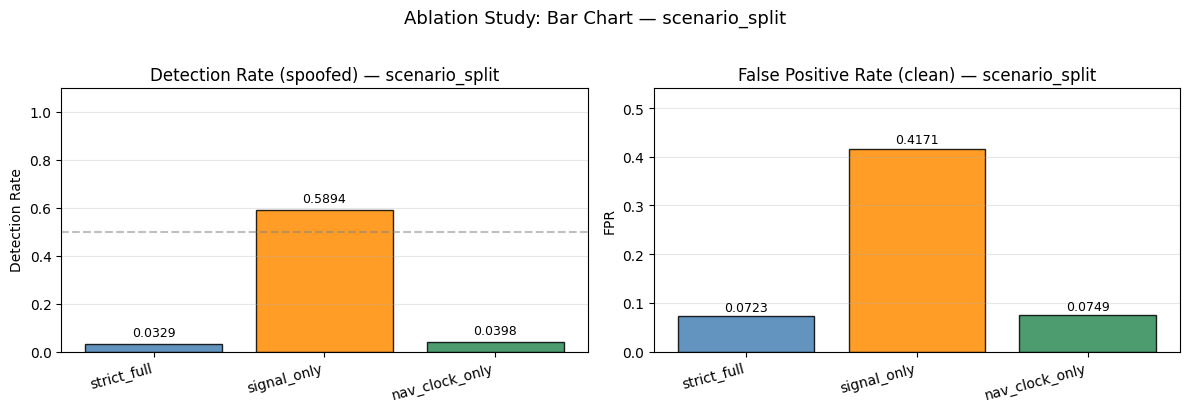

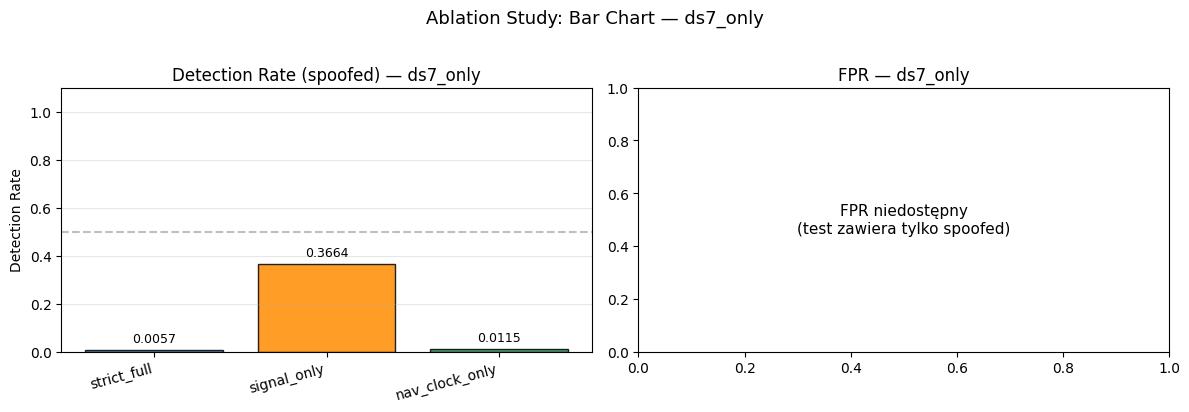

In [28]:
import matplotlib.pyplot as plt

_COLORS = ["steelblue", "darkorange", "seagreen", "crimson"]
_fs_list = list(feature_sets.keys())

for split_type_b in ["scenario_split", "ds7_only"]:
    sub_b = ablation_df[ablation_df["split_type"] == split_type_b].copy()
    if sub_b.empty:
        print(f"[BRAK DANYCH] {split_type_b}")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Detection Rate
    dr_vals = sub_b.set_index("feature_set").reindex(_fs_list)["detection_rate_spoof"].fillna(0)
    bars0 = axes[0].bar(_fs_list, dr_vals,
                        color=_COLORS[:len(_fs_list)], edgecolor="black", alpha=0.85)
    for bar, val in zip(bars0, dr_vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f"{val:.4f}", ha="center", va="bottom", fontsize=9)
    axes[0].set_title(f"Detection Rate (spoofed) — {split_type_b}")
    axes[0].set_ylabel("Detection Rate")
    axes[0].set_ylim(0, 1.1)
    axes[0].set_xticklabels(_fs_list, rotation=15, ha="right")
    axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    axes[0].grid(axis="y", alpha=0.3)

    # False Positive Rate (jeśli dostępne)
    fpr_vals = sub_b.set_index("feature_set").reindex(_fs_list)["false_positive_rate_clean"].fillna(0)
    if fpr_vals.sum() > 0:
        bars1 = axes[1].bar(_fs_list, fpr_vals,
                            color=_COLORS[:len(_fs_list)], edgecolor="black", alpha=0.85)
        for bar, val in zip(bars1, fpr_vals):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                         f"{val:.4f}", ha="center", va="bottom", fontsize=9)
        axes[1].set_title(f"False Positive Rate (clean) — {split_type_b}")
        axes[1].set_ylabel("FPR")
        axes[1].set_ylim(0, max(fpr_vals.max() * 1.3, 0.1))
        axes[1].set_xticklabels(_fs_list, rotation=15, ha="right")
        axes[1].grid(axis="y", alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, "FPR niedostępny\n(test zawiera tylko spoofed)",
                     ha="center", va="center", transform=axes[1].transAxes, fontsize=11)
        axes[1].set_title(f"FPR — {split_type_b}")

    plt.suptitle(f"Ablation Study: Bar Chart — {split_type_b}", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


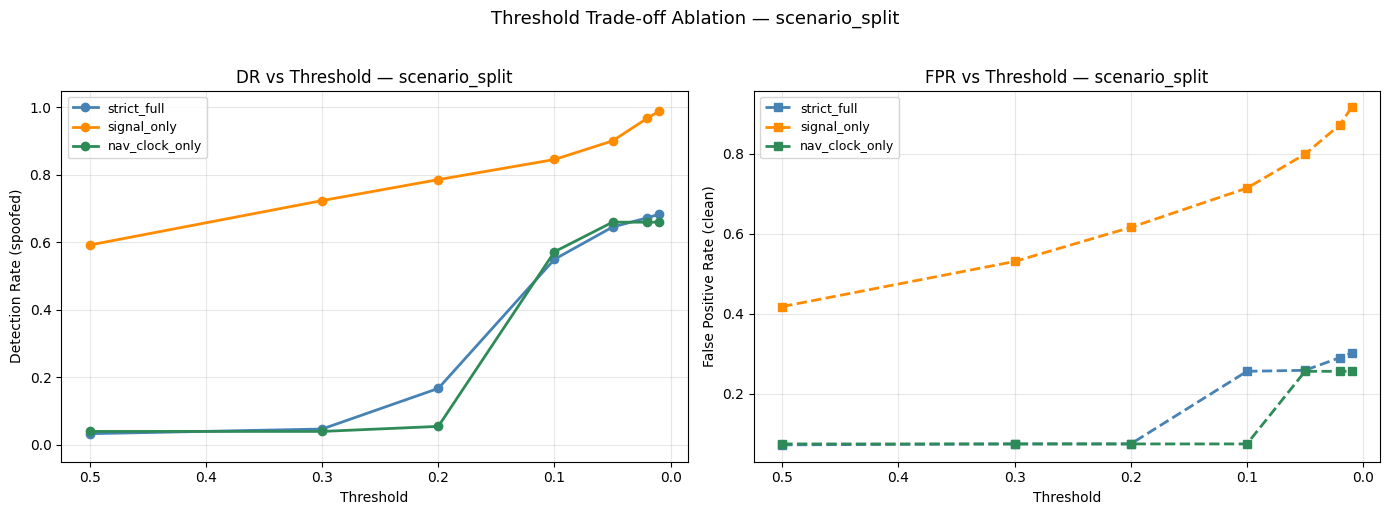

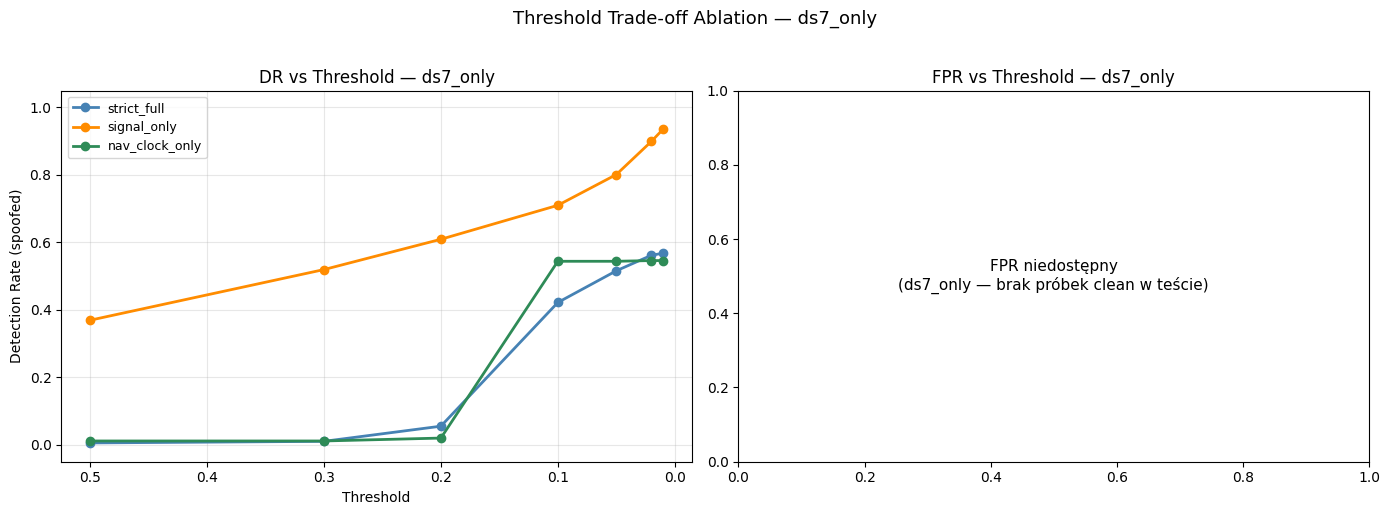

In [29]:
import matplotlib.pyplot as plt

_FS_COLORS = {
    "strict_full":             "steelblue",
    "signal_only":             "darkorange",
    "signal_only_no_nav_clock": "darkorange",
    "nav_clock_only":          "seagreen",
}

for split_type_p in ["scenario_split", "ds7_only"]:
    sub_p = threshold_ablation_df[threshold_ablation_df["split_type"] == split_type_p]
    if sub_p.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for fs in sub_p["feature_set"].unique():
        _d = sub_p[sub_p["feature_set"] == fs].sort_values("threshold", ascending=False)
        _c = _FS_COLORS.get(fs, "gray")

        # Detection Rate
        axes[0].plot(_d["threshold"], _d["detection_rate_spoof"],
                     "o-", color=_c, linewidth=2, label=fs)

        # FPR (może być None w ds7_only)
        _fpr = _d["false_positive_rate_clean"]
        if _fpr.notna().any():
            axes[1].plot(_d["threshold"], _fpr,
                         "s--", color=_c, linewidth=2, label=fs)

    axes[0].set_xlabel("Threshold")
    axes[0].set_ylabel("Detection Rate (spoofed)")
    axes[0].set_title(f"DR vs Threshold — {split_type_p}")
    axes[0].invert_xaxis()
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(-0.05, 1.05)

    if axes[1].lines:
        axes[1].set_xlabel("Threshold")
        axes[1].set_ylabel("False Positive Rate (clean)")
        axes[1].set_title(f"FPR vs Threshold — {split_type_p}")
        axes[1].invert_xaxis()
        axes[1].legend(fontsize=9)
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, "FPR niedostępny\n(ds7_only — brak próbek clean w teście)",
                     ha="center", va="center", transform=axes[1].transAxes, fontsize=11)
        axes[1].set_title(f"FPR vs Threshold — {split_type_p}")

    plt.suptitle(f"Threshold Trade-off Ablation — {split_type_p}", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


## Interpretacja ablation study i rekomendacja

### Merytoryczne uzasadnienie cech nav/clock

Cechy nawigacyjne i zegarowe (`clock_error_m`, `latitude_delta_deg`, `clock_error_rate_mps` itp.) są **fizykalnie uzasadnione**: spoofing GPS zaburza rozwiązanie pozycji oraz czas w odbiorniku. Jeśli atak z ds2/ds3 powoduje wyraźny dryf tych cech, model może nauczyć się ich wzorców.

### Klucz do interpretacji wyników

| Scenariusz wyników | Co to oznacza |
|---|---|
| `strict_full` wysoki DR na random/group, niski na ds7 | Model nauczył się specyfiki ds2/ds3 w przestrzeni nav/clock; ds7 ma inny profil |
| `signal_only` poprawia DR ds7 | Cechy nav/clock dominowały i utrudniały generalizację — warto je traktować ostrożnie |
| `signal_only` pogarsza wszystko | Cechy nav/clock są kluczowe dla detekcji; zostaw w modelu, kalibruj próg |
| `nav_clock_only` dobry na ds2/ds3, zły na ds7 | ds7 ma subtelniejszy lub inaczej rozłożony dryf pozycji/zegara |
| Wszystkie warianty słabe na ds7 | Problem leży w samym ds7 — wymagana analiza anomalii lub nowe cechy |

### Rekomendacja

1. **Nav/clock w głównym modelu (X_strict):**  
   Zostaw — merytorycznie uzasadnione i zwykle poprawiają wykrywalność ds2/ds3.  
   Jeśli ablation pokazuje, że `signal_only` nie pogarsza ds2/ds3 i poprawia ds7, rozważ przetestowanie    wariantu hybrydowego (np. bez `distance_from_start_m` i `clock_error_m`).

2. **Wariant `signal_only` jako punkt kontrolny:**  
   Zawsze raportuj wyniki `signal_only_no_nav_clock` obok `strict_full` — ujawnia,    ile modelu zależy od wzorców specyficznych dla znanych scenariuszy.

3. **Threshold sweep dla ds7:**  
   Niezależnie od wariantu cech, domyślny próg 0.5 jest zbyt wysoki dla ds7.    Kalibruj próg per deployment na podstawie akceptowalnego FPR.

4. **Anomaly detection jako uzupełnienie:**  
   IsolationForest trenowany wyłącznie na czystym sygnale (bez wiedzy o ds2/ds3) może lepiej    wykrywać ds7 jako odchylenie od normy — szczególnie jeśli ds7 ma subtelniejsze zaburzenia    cech sygnału niż ds2/ds3.


## SEKCJA 14c: Wyspecjalizowane detektory i fuzja — osobne modele dla ds2/ds3/ds7

Dotychczasowy model *clean vs all spoofed* miał trudność z wykrywaniem scenariusza **ds7**, ponieważ ds7 jest subtelniejszy i różni się charakterystyką sygnału od ds2 i ds3. Trenowanie jednego modelu na unii "ds2 ∪ ds3 ∪ ds7" sprawia, że granica decyzyjna jest zdominowana przez łatwiejsze do odróżnienia przykłady ds2 i ds3.

W tej sekcji testujemy podejście z **kilkoma specjalistycznymi detektorami**:
- **detector_ds2**: trenowany na `cleanStatic vs ds2`
- **detector_ds3**: trenowany na `cleanStatic vs ds3`
- **detector_ds7**: trenowany na `cleanStatic vs ds7`

Następnie ich prawdopodobieństwa spoofingu są łączone w jeden finalny alarm fuzji.

---

### Różnica w stosunku do poprzednich eksperymentów

| Podział | Poprzedni scenario split | Wyspecjalizowane detektory |
|---|---|---|
| **Train** | cleanStatic + ds2 + ds3 | każdy model: cleanStatic + odpowiedni scenariusz |
| **Test** | ds7 (niewidoczny w treningu) | held-out fragmenty wszystkich scenariuszy |
| **Pytanie** | Generalizacja na **niewidoczny atak**? | Czy system detektorów **znanych typów ataku** działa? |

> **Uwaga:** Ten eksperyment nie zastępuje testu generalizacji na niewidziany atak. To alternatywny wariant: jeśli operator ma dostęp do przykładów ds7 w treningu, możemy zbudować specjalistyczny detector_ds7 i połączyć go z innymi detektorami.

In [30]:
from sklearn.model_selection import train_test_split as _tts_fus
import pandas as pd
import numpy as np

# Upewnij się, że episode_id jest dostępne w df
if 'episode_id' not in df.columns:
    _SEGMENT = 30
    if 'time_bin' in df.columns:
        _tc = df['time_bin']
    elif 'time_from_start_s' in df.columns:
        _tc = df['time_from_start_s']
    else:
        _tc = pd.Series(range(len(df)), index=df.index)
    df['episode_id'] = (
        df['scenario'].astype(str) + '_episode_' +
        np.floor(_tc / _SEGMENT).astype(int).astype(str)
    )

scenario_train_episodes: dict = {}
scenario_test_episodes:  dict = {}
_fus_info = []

for _sc in ["cleanStatic", "ds2", "ds3", "ds7"]:
    _eps = sorted(df[df["scenario"] == _sc]["episode_id"].unique())
    if len(_eps) < 2:
        scenario_train_episodes[_sc] = set(_eps)
        scenario_test_episodes[_sc]  = set()
        _ntr = int((df["scenario"] == _sc).sum())
        _nte = 0
    else:
        _tr_e, _te_e = _tts_fus(_eps, test_size=0.3, random_state=42)
        scenario_train_episodes[_sc] = set(_tr_e)
        scenario_test_episodes[_sc]  = set(_te_e)
        _ntr = int(((df["scenario"] == _sc) & (df["episode_id"].isin(scenario_train_episodes[_sc]))).sum())
        _nte = int(((df["scenario"] == _sc) & (df["episode_id"].isin(scenario_test_episodes[_sc]))).sum())
    _fus_info.append({
        "scenario":         _sc,
        "n_train_episodes": len(scenario_train_episodes[_sc]),
        "n_test_episodes":  len(scenario_test_episodes[_sc]),
        "n_train_rows":     _ntr,
        "n_test_rows":      _nte,
    })

fus_split_df = pd.DataFrame(_fus_info)
print("Podział epizodów per scenariusz (70/30, random_state=42):")
print(fus_split_df.to_string(index=False))

# Fusion test mask — held-out fragmenty wszystkich czterech scenariuszy
test_fusion_mask = pd.Series(False, index=df.index)
for _sc in ["cleanStatic", "ds2", "ds3", "ds7"]:
    _m = (df["scenario"] == _sc) & (df["episode_id"].isin(scenario_test_episodes[_sc]))
    test_fusion_mask = test_fusion_mask | _m

X_fusion_test        = X_strict.loc[test_fusion_mask]
y_fusion_test        = y.loc[test_fusion_mask]
scenario_fusion_test = scenario.loc[test_fusion_mask]

# Wskaźniki per scenario do późniejszego użycia
_y_fus_arr   = y_fusion_test.values
_sc_fus_arr  = scenario_fusion_test.values
_ds2_mask_fus = _sc_fus_arr == "ds2"
_ds3_mask_fus = _sc_fus_arr == "ds3"
_ds7_mask_fus = _sc_fus_arr == "ds7"
_clean_mask_fus = _sc_fus_arr == "cleanStatic"

print("\nRozkład fusion test set (wiersze per scenariusz):")
print(scenario_fusion_test.value_counts().to_string())
print("\nTarget distribution (0=clean, 1=spoofed):")
print(y_fusion_test.value_counts().to_string())

Podział epizodów per scenariusz (70/30, random_state=42):
   scenario  n_train_episodes  n_test_episodes  n_train_rows  n_test_rows
cleanStatic                10                5         19558        12334
        ds2                10                5         19229        11974
        ds3                10                5         19712        12180
        ds7                10                5         20398        12334

Rozkład fusion test set (wiersze per scenariusz):
scenario
cleanStatic    12334
ds7            12334
ds3            12180
ds2            11974

Target distribution (0=clean, 1=spoofed):
label_spoofed_scenario
1    36488
0    12334


### Trenowanie specjalistycznych detektorów

Dla każdego scenariusza spoofingu trenujemy **osobny model binarny**:
- target `0` = rekord pochodzi z `cleanStatic`
- target `1` = rekord pochodzi z danego scenariusza spoofingu

Train set każdego detektora: `cleanStatic` (train episodes) + odpowiedni scenariusz (train episodes).
Żaden detektor nie widzi rekordów z innych scenariuszy spoofingu.

Feature set: `X_strict` (ten sam co w pozostałych eksperymentach).

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

def _make_spec_rf():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1,
        )),
    ])

# Użyj make_rf() jeśli dostępna, inaczej _make_spec_rf()
_detector_factory = make_rf if 'make_rf' in dir() else _make_spec_rf

specialized_models: dict = {}
_spec_train_rows = []

for _spoof_sc in ["ds2", "ds3", "ds7"]:
    _m_clean_tr = (
        (df["scenario"] == "cleanStatic") &
        (df["episode_id"].isin(scenario_train_episodes["cleanStatic"]))
    )
    _m_spoof_tr = (
        (df["scenario"] == _spoof_sc) &
        (df["episode_id"].isin(scenario_train_episodes[_spoof_sc]))
    )
    _mask_tr = _m_clean_tr | _m_spoof_tr

    _X_tr = X_strict.loc[_mask_tr]
    # Target: 0=clean, 1=dany spoof_sc
    _y_tr = (df.loc[_mask_tr, "scenario"] == _spoof_sc).astype(int)

    _model = _detector_factory()
    _model.fit(_X_tr, _y_tr)
    specialized_models[_spoof_sc] = _model

    _nc = int(_m_clean_tr.sum())
    _ns = int(_m_spoof_tr.sum())
    _spec_train_rows.append({
        "detector":       f"detector_{_spoof_sc}",
        "n_train_clean":  _nc,
        "n_train_spoof":  _ns,
        "n_total_train":  _nc + _ns,
        "n_features":     _X_tr.shape[1],
    })
    print(f"detector_{_spoof_sc}: {_nc} clean + {_ns} spoof → {_nc+_ns} train, {_X_tr.shape[1]} features")

spec_train_df = pd.DataFrame(_spec_train_rows)
print("\nPodsumowanie treningu specjalistycznych detektorów:")
print(spec_train_df.to_string(index=False))

detector_ds2: 19558 clean + 19229 spoof → 38787 train, 34 features
detector_ds3: 19558 clean + 19712 spoof → 39270 train, 34 features
detector_ds7: 19558 clean + 20398 spoof → 39956 train, 34 features

Podsumowanie treningu specjalistycznych detektorów:
    detector  n_train_clean  n_train_spoof  n_total_train  n_features
detector_ds2          19558          19229          38787          34
detector_ds3          19558          19712          39270          34
detector_ds7          19558          20398          39956          34


In [32]:
from sklearn.metrics import confusion_matrix

# Pomocnik: metryki binarne
def _bin_metrics(y_true, y_pred):
    _cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    _tn, _fp, _fn, _tp = _cm.ravel()
    _n = max(len(y_true), 1)
    _acc  = (_tn + _tp) / _n
    _dr   = _tp / max(_tp + _fn, 1)
    _fpr  = _fp / max(_fp + _tn, 1)
    _prec = _tp / max(_tp + _fp, 1)
    return _acc, _dr, _fpr, _prec, int(_tn), int(_fp), int(_fn), int(_tp)

spec_individual_rows = []

for _spoof_sc in ["ds2", "ds3", "ds7"]:
    _m_clean_te = (
        (df["scenario"] == "cleanStatic") &
        (df["episode_id"].isin(scenario_test_episodes["cleanStatic"]))
    )
    _m_spoof_te = (
        (df["scenario"] == _spoof_sc) &
        (df["episode_id"].isin(scenario_test_episodes[_spoof_sc]))
    )
    _mask_te = _m_clean_te | _m_spoof_te

    _X_te = X_strict.loc[_mask_te]
    _y_te = (df.loc[_mask_te, "scenario"] == _spoof_sc).astype(int)

    _y_pred = specialized_models[_spoof_sc].predict(_X_te)
    _acc, _dr, _fpr, _prec, _tn, _fp, _fn, _tp = _bin_metrics(_y_te.values, _y_pred)

    _n_tr = spec_train_df.loc[
        spec_train_df["detector"] == f"detector_{_spoof_sc}", "n_total_train"
    ].values[0]

    spec_individual_rows.append({
        "detector":                 f"detector_{_spoof_sc}",
        "test_scenario":            _spoof_sc,
        "n_train":                  int(_n_tr),
        "n_test":                   len(_y_te),
        "accuracy":                 round(_acc,  4),
        "detection_rate_spoof":     round(_dr,   4),
        "false_positive_rate_clean": round(_fpr, 4),
        "precision_spoof":          round(_prec, 4),
        "tn": _tn, "fp": _fp, "fn": _fn, "tp": _tp,
    })
    print(f"detector_{_spoof_sc}: DR={_dr:.3f}, FPR={_fpr:.3f}, prec={_prec:.3f}, acc={_acc:.3f}")

specialized_individual_results_df = pd.DataFrame(spec_individual_rows)
print("\nWyniki specjalistycznych detektorów (własny held-out test):")
print(specialized_individual_results_df.to_string(index=False))

detector_ds2: DR=1.000, FPR=0.004, prec=0.996, acc=0.998
detector_ds3: DR=1.000, FPR=0.048, prec=0.953, acc=0.976
detector_ds7: DR=0.934, FPR=0.250, prec=0.789, acc=0.842

Wyniki specjalistycznych detektorów (własny held-out test):
    detector test_scenario  n_train  n_test  accuracy  detection_rate_spoof  false_positive_rate_clean  precision_spoof    tn   fp  fn    tp
detector_ds2           ds2    38787   24308    0.9979                1.0000                     0.0041           0.9958 12283   51   0 11974
detector_ds3           ds3    39270   24514    0.9758                1.0000                     0.0482           0.9535 11740  594   0 12180
detector_ds7           ds7    39956   24668    0.8418                0.9336                     0.2500           0.7888  9250 3084 819 11515


> **Interpretacja:** Ten test odpowiada pytaniu: *czy dany typ spoofingu jest wykrywalny, jeśli model zna przykłady tego typu ataku w treningu?*
> Jest to inne pytanie niż w scenario split (Section 9), gdzie model nie widział ds7 podczas trenowania.

### Prawdopodobieństwa specjalistycznych detektorów na wspólnym zbiorze testowym

Każdy z trzech modeli ocenia **wspólny fusion test set** (held-out fragmenty wszystkich 4 scenariuszy). Interesuje nas:
- czy `detector_ds7` przypisuje wysokie `p_ds7` rekordom ze scenariusza ds7?
- czy detektory mylą scenariusze (np. detektor ds2 reaguje na ds3)?
- czy `p_max = max(p_ds2, p_ds3, p_ds7)` jest niskie dla czystych rekordów (`cleanStatic`)?

In [33]:
p_ds2 = specialized_models["ds2"].predict_proba(X_fusion_test)[:, 1]
p_ds3 = specialized_models["ds3"].predict_proba(X_fusion_test)[:, 1]
p_ds7 = specialized_models["ds7"].predict_proba(X_fusion_test)[:, 1]

_p_stack = np.column_stack([p_ds2, p_ds3, p_ds7])
_p_max_vals    = _p_stack.max(axis=1)
_p_max_idx     = _p_stack.argmax(axis=1)
_det_labels    = np.array(["ds2", "ds3", "ds7"])
_pred_specialist = _det_labels[_p_max_idx]

fusion_proba_df = pd.DataFrame({
    "scenario":             _sc_fus_arr,
    "y_true":               _y_fus_arr,
    "p_ds2":                p_ds2,
    "p_ds3":                p_ds3,
    "p_ds7":                p_ds7,
    "p_max":                _p_max_vals,
    "predicted_specialist": _pred_specialist,
}, index=X_fusion_test.index)

print("Head fusion_proba_df:")
print(fusion_proba_df.head(8).to_string())

print("\nŚrednie prawdopodobieństwa per scenariusz:")
_mean_p = fusion_proba_df.groupby("scenario")[["p_ds2", "p_ds3", "p_ds7", "p_max"]].mean()
_sc_order = [s for s in ["cleanStatic", "ds2", "ds3", "ds7"] if s in _mean_p.index]
print(_mean_p.loc[_sc_order].round(4).to_string())

print("\nInterpretacja:")
for _sc in _sc_order:
    if _sc not in _mean_p.index:
        continue
    _row = _mean_p.loc[_sc]
    _best_det = _row[["p_ds2","p_ds3","p_ds7"]].idxmax()
    print(f"  {_sc}: najwyższe p = {_best_det} ({_row[_best_det]:.3f}), p_max={_row['p_max']:.3f}")

Head fusion_proba_df:
      scenario  y_true     p_ds2     p_ds3     p_ds7     p_max predicted_specialist
0  cleanStatic       0  0.410000  0.540000  0.560912  0.560912                  ds7
1  cleanStatic       0  0.403333  0.530000  0.576528  0.576528                  ds7
2  cleanStatic       0  0.393333  0.533333  0.510512  0.533333                  ds3
3  cleanStatic       0  0.373333  0.533333  0.561072  0.561072                  ds7
4  cleanStatic       0  0.383333  0.530000  0.512765  0.530000                  ds3
5  cleanStatic       0  0.376667  0.533333  0.563501  0.563501                  ds7
6  cleanStatic       0  0.260000  0.440000  0.478873  0.478873                  ds7
7  cleanStatic       0  0.226667  0.443333  0.546384  0.546384                  ds7

Średnie prawdopodobieństwa per scenariusz:
              p_ds2   p_ds3   p_ds7   p_max
scenario                                   
cleanStatic  0.0235  0.0636  0.2013  0.2034
ds2          0.9739  0.8217  0.6766  0.9898
ds

### Fusion strategy 1 — max probability threshold

Najprostsza strategia fuzji: system zgłasza alarm, gdy **którykolwiek** specjalistyczny detektor zwróci wysokie prawdopodobieństwo.

$$p_{\text{final}} = \max(p_{ds2},\, p_{ds3},\, p_{ds7})$$
$$\text{alarm} = \mathbf{1}[p_{\text{final}} \geq \theta]$$

Testujemy progi $\theta \in \{0.50, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01\}$.

In [34]:
from sklearn.metrics import confusion_matrix

def _sc_dr(y_true, y_pred, sc_arr, sc_name):
    """Detection rate for a single scenario label in fusion test."""
    _m = sc_arr == sc_name
    if _m.sum() == 0:
        return float("nan")
    _tp_s = int(((y_true[_m] == 1) & (y_pred[_m] == 1)).sum())
    _fn_s = int(((y_true[_m] == 1) & (y_pred[_m] == 0)).sum())
    return _tp_s / max(_tp_s + _fn_s, 1)

_thresholds_fus = [0.50, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01]
_fus_thresh_rows = []

for _thr in _thresholds_fus:
    _alarm = (_p_max_vals >= _thr).astype(int)
    _cm = confusion_matrix(_y_fus_arr, _alarm, labels=[0, 1])
    _tn, _fp, _fn, _tp = _cm.ravel()
    _acc  = (_tn + _tp) / max(len(_y_fus_arr), 1)
    _dr   = _tp / max(_tp + _fn, 1)
    _fpr  = _fp / max(_fp + _tn, 1)
    _prec = _tp / max(_tp + _fp, 1)
    _fus_thresh_rows.append({
        "threshold":                 _thr,
        "accuracy":                  round(_acc,  4),
        "detection_rate_spoof":      round(_dr,   4),
        "false_positive_rate_clean": round(_fpr,  4),
        "precision_spoof":           round(_prec, 4),
        "ds2_detection_rate":        round(_sc_dr(_y_fus_arr, _alarm, _sc_fus_arr, "ds2"),  4),
        "ds3_detection_rate":        round(_sc_dr(_y_fus_arr, _alarm, _sc_fus_arr, "ds3"),  4),
        "ds7_detection_rate":        round(_sc_dr(_y_fus_arr, _alarm, _sc_fus_arr, "ds7"),  4),
        "tn": int(_tn), "fp": int(_fp), "fn": int(_fn), "tp": int(_tp),
    })

fusion_threshold_df = pd.DataFrame(_fus_thresh_rows)
print("Fusion max probability — threshold sweep (fusion test set):")
print(fusion_threshold_df.to_string(index=False))

Fusion max probability — threshold sweep (fusion test set):
 threshold  accuracy  detection_rate_spoof  false_positive_rate_clean  precision_spoof  ds2_detection_rate  ds3_detection_rate  ds7_detection_rate   tn   fp  fn    tp
      0.50    0.9201                0.9793                     0.2551           0.9191                 1.0                 1.0              0.9388 9188 3146 755 35733
      0.30    0.9194                1.0000                     0.3190           0.9027                 1.0                 1.0              1.0000 8400 3934   0 36488
      0.20    0.9090                1.0000                     0.3601           0.8915                 1.0                 1.0              1.0000 7892 4442   0 36488
      0.10    0.8810                1.0000                     0.4710           0.8627                 1.0                 1.0              1.0000 6525 5809   0 36488
      0.05    0.8660                1.0000                     0.5306           0.8479                 1.

### Fusion strategy 2 — OR ensemble z osobnymi progami

Zamiast jednego globalnego progu, każdy detektor ma **własny próg**.
Alarm jest zgłaszany, gdy **co najmniej jeden** detektor przekroczy swój próg:

$$\text{alarm} = \mathbf{1}[p_{ds2} \geq \theta_2 \lor p_{ds3} \geq \theta_3 \lor p_{ds7} \geq \theta_7]$$

- **OR zwiększa czułość** (więcej alarmów), ale może podnosić false positive rate.
- **Osobny niższy próg dla ds7** (np. `θ₇ = 0.10`) może poprawić wykrywanie trudniejszego scenariusza bez obniżania progów dla ds2/ds3, które są łatwo wykrywalne.

In [35]:
_or_configs = [
    {"name": "all_0.50",      "ds2": 0.50, "ds3": 0.50, "ds7": 0.50},
    {"name": "all_0.30",      "ds2": 0.30, "ds3": 0.30, "ds7": 0.30},
    {"name": "all_0.10",      "ds2": 0.10, "ds3": 0.10, "ds7": 0.10},
    {"name": "sensitive_ds7", "ds2": 0.50, "ds3": 0.50, "ds7": 0.10},
    {"name": "balanced_ds7",  "ds2": 0.50, "ds3": 0.50, "ds7": 0.30},
]

_fus_or_rows = []
for _cfg in _or_configs:
    _alarm_or = (
        (p_ds2 >= _cfg["ds2"]) |
        (p_ds3 >= _cfg["ds3"]) |
        (p_ds7 >= _cfg["ds7"])
    ).astype(int)

    _cm = confusion_matrix(_y_fus_arr, _alarm_or, labels=[0, 1])
    _tn, _fp, _fn, _tp = _cm.ravel()
    _acc  = (_tn + _tp) / max(len(_y_fus_arr), 1)
    _dr   = _tp / max(_tp + _fn, 1)
    _fpr  = _fp / max(_fp + _tn, 1)
    _prec = _tp / max(_tp + _fp, 1)
    _fus_or_rows.append({
        "config_name":               _cfg["name"],
        "thr_ds2": _cfg["ds2"], "thr_ds3": _cfg["ds3"], "thr_ds7": _cfg["ds7"],
        "accuracy":                  round(_acc,  4),
        "detection_rate_spoof":      round(_dr,   4),
        "false_positive_rate_clean": round(_fpr,  4),
        "precision_spoof":           round(_prec, 4),
        "ds2_detection_rate":        round(_sc_dr(_y_fus_arr, _alarm_or, _sc_fus_arr, "ds2"), 4),
        "ds3_detection_rate":        round(_sc_dr(_y_fus_arr, _alarm_or, _sc_fus_arr, "ds3"), 4),
        "ds7_detection_rate":        round(_sc_dr(_y_fus_arr, _alarm_or, _sc_fus_arr, "ds7"), 4),
        "tn": int(_tn), "fp": int(_fp), "fn": int(_fn), "tp": int(_tp),
    })

fusion_or_configs_df = pd.DataFrame(_fus_or_rows)
print("Fusion OR ensemble — konfiguracje progów:")
print(fusion_or_configs_df.to_string(index=False))

Fusion OR ensemble — konfiguracje progów:
  config_name  thr_ds2  thr_ds3  thr_ds7  accuracy  detection_rate_spoof  false_positive_rate_clean  precision_spoof  ds2_detection_rate  ds3_detection_rate  ds7_detection_rate   tn   fp  fn    tp
     all_0.50      0.5      0.5      0.5    0.9201                0.9793                     0.2551           0.9191                 1.0                 1.0              0.9388 9188 3146 755 35733
     all_0.30      0.3      0.3      0.3    0.9194                1.0000                     0.3190           0.9027                 1.0                 1.0              1.0000 8400 3934   0 36488
     all_0.10      0.1      0.1      0.1    0.8810                1.0000                     0.4710           0.8627                 1.0                 1.0              1.0000 6525 5809   0 36488
sensitive_ds7      0.5      0.5      0.1    0.8810                1.0000                     0.4710           0.8627                 1.0                 1.0              

In [36]:
# ── Single binary model: train = wszystkie train episodes, test = fusion test ──
_mask_single_tr = pd.Series(False, index=df.index)
for _sc in ["cleanStatic", "ds2", "ds3", "ds7"]:
    _m = (df["scenario"] == _sc) & (df["episode_id"].isin(scenario_train_episodes[_sc]))
    _mask_single_tr = _mask_single_tr | _m

_X_single_tr = X_strict.loc[_mask_single_tr]
_y_single_tr = y.loc[_mask_single_tr]

_single_model = (_detector_factory if '_detector_factory' in dir() else make_rf)()
_single_model.fit(_X_single_tr, _y_single_tr)
_proba_single = _single_model.predict_proba(X_fusion_test)[:, 1]

def _eval_row(y_true, y_pred, sc_arr, name):
    _cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    _tn, _fp, _fn, _tp = _cm.ravel()
    _acc  = (_tn + _tp) / max(len(y_true), 1)
    _dr   = _tp / max(_tp + _fn, 1)
    _fpr  = _fp / max(_fp + _tn, 1)
    _prec = _tp / max(_tp + _fp, 1)
    return {
        "method":                    name,
        "accuracy":                  round(_acc,  4),
        "detection_rate_spoof":      round(_dr,   4),
        "false_positive_rate_clean": round(_fpr,  4),
        "precision_spoof":           round(_prec, 4),
        "ds2_detection_rate":        round(_sc_dr(y_true, y_pred, sc_arr, "ds2"), 4),
        "ds3_detection_rate":        round(_sc_dr(y_true, y_pred, sc_arr, "ds3"), 4),
        "ds7_detection_rate":        round(_sc_dr(y_true, y_pred, sc_arr, "ds7"), 4),
    }

_comp_rows = []

# 1. Single binary RF @ 0.50
_pred_single_050 = (_proba_single >= 0.50).astype(int)
_comp_rows.append(_eval_row(_y_fus_arr, _pred_single_050, _sc_fus_arr, "single_binary_rf_thr0.50"))

# 2. Specialized max @ 0.50
_alarm_max_050 = (_p_max_vals >= 0.50).astype(int)
_comp_rows.append(_eval_row(_y_fus_arr, _alarm_max_050, _sc_fus_arr, "specialized_max_thr0.50"))

# 3. Specialized max @ najlepszy rozsądny próg (max DR przy FPR <= 0.20)
_cand = fusion_threshold_df[fusion_threshold_df["false_positive_rate_clean"] <= 0.20]
if not _cand.empty:
    _best_thr = float(_cand.loc[_cand["detection_rate_spoof"].idxmax(), "threshold"])
else:
    _best_thr = 0.10
_alarm_max_best = (_p_max_vals >= _best_thr).astype(int)
_comp_rows.append(_eval_row(_y_fus_arr, _alarm_max_best, _sc_fus_arr, f"specialized_max_best_thr{_best_thr}"))

# 4. OR ensemble all_0.50
_alarm_or_050 = ((p_ds2 >= 0.50) | (p_ds3 >= 0.50) | (p_ds7 >= 0.50)).astype(int)
_comp_rows.append(_eval_row(_y_fus_arr, _alarm_or_050, _sc_fus_arr, "specialized_or_all_0.50"))

# 5. OR ensemble sensitive_ds7
_alarm_or_sens = ((p_ds2 >= 0.50) | (p_ds3 >= 0.50) | (p_ds7 >= 0.10)).astype(int)
_comp_rows.append(_eval_row(_y_fus_arr, _alarm_or_sens, _sc_fus_arr, "specialized_or_sensitive_ds7"))

model_comparison_fusion_df = pd.DataFrame(_comp_rows)
print("Porównanie: single binary vs specialized fusion (fusion test set):")
print(model_comparison_fusion_df.to_string(index=False))

Porównanie: single binary vs specialized fusion (fusion test set):
                      method  accuracy  detection_rate_spoof  false_positive_rate_clean  precision_spoof  ds2_detection_rate  ds3_detection_rate  ds7_detection_rate
    single_binary_rf_thr0.50    0.9196                0.9980                     0.3125           0.9043                 1.0                 1.0              0.9942
     specialized_max_thr0.50    0.9201                0.9793                     0.2551           0.9191                 1.0                 1.0              0.9388
 specialized_max_best_thr0.1    0.8810                1.0000                     0.4710           0.8627                 1.0                 1.0              1.0000
     specialized_or_all_0.50    0.9201                0.9793                     0.2551           0.9191                 1.0                 1.0              0.9388
specialized_or_sensitive_ds7    0.8810                1.0000                     0.4710           0.8627    

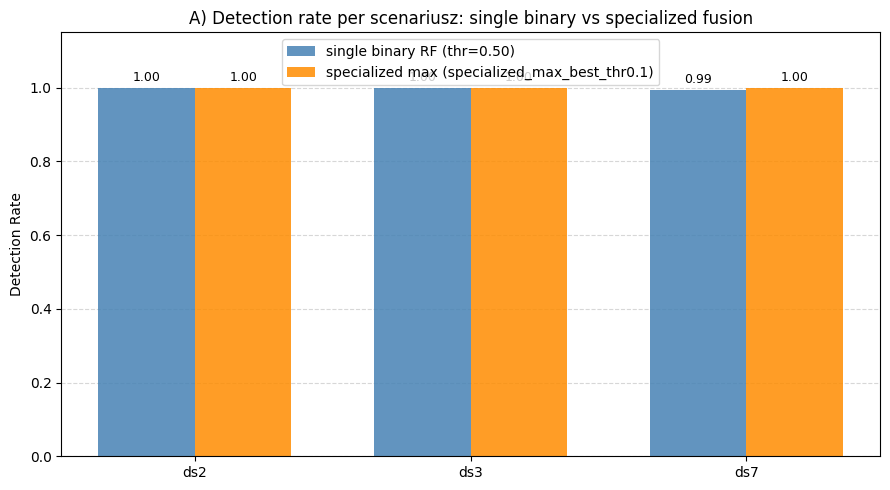

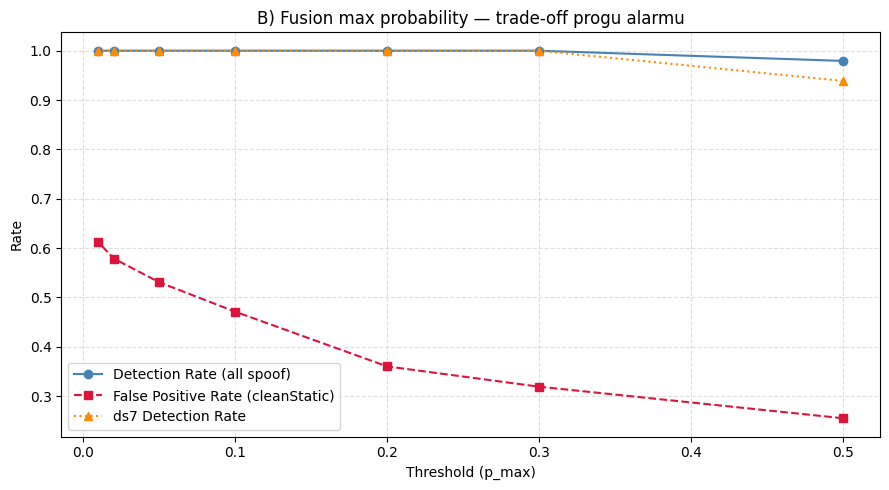

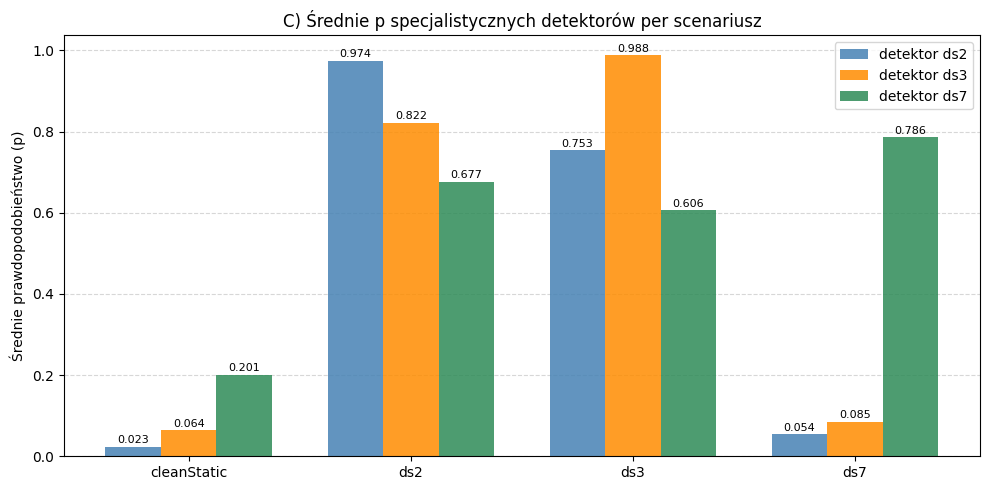

In [37]:
import matplotlib.pyplot as plt
import numpy as np

_sc_order_plot = [s for s in ["cleanStatic","ds2","ds3","ds7"]
                  if s in fusion_proba_df["scenario"].unique()]

# ── A) Bar chart: detection rate per scenario — single binary vs specialized ──
fig, ax = plt.subplots(figsize=(9, 5))
_spoof_scs = ["ds2", "ds3", "ds7"]
_x = np.arange(len(_spoof_scs))
_width = 0.35

_dr_single  = [
    model_comparison_fusion_df.loc[
        model_comparison_fusion_df["method"] == "single_binary_rf_thr0.50",
        f"{_sc}_detection_rate"
    ].values[0]
    for _sc in _spoof_scs
]
# Wybierz wiersz specialized z najlepszym progiem
_best_row_name = [m for m in model_comparison_fusion_df["method"]
                  if m.startswith("specialized_max_best")]
_best_row_name = _best_row_name[0] if _best_row_name else "specialized_max_thr0.50"
_dr_fus = [
    model_comparison_fusion_df.loc[
        model_comparison_fusion_df["method"] == _best_row_name,
        f"{_sc}_detection_rate"
    ].values[0]
    for _sc in _spoof_scs
]

_b1 = ax.bar(_x - _width/2, _dr_single, _width, label="single binary RF (thr=0.50)",
             color="steelblue", alpha=0.85)
_b2 = ax.bar(_x + _width/2, _dr_fus, _width, label=f"specialized max ({_best_row_name})",
             color="darkorange", alpha=0.85)
for _rect in list(_b1) + list(_b2):
    _h = _rect.get_height()
    if not np.isnan(_h):
        ax.text(_rect.get_x() + _rect.get_width()/2, _h + 0.01,
                f"{_h:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(_x)
ax.set_xticklabels(_spoof_scs)
ax.set_ylabel("Detection Rate")
ax.set_ylim(0, 1.15)
ax.set_title("A) Detection rate per scenariusz: single binary vs specialized fusion")
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# ── B) Fusion threshold trade-off (max probability) ──
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(fusion_threshold_df["threshold"], fusion_threshold_df["detection_rate_spoof"],
        "o-",  color="steelblue",   label="Detection Rate (all spoof)")
ax.plot(fusion_threshold_df["threshold"], fusion_threshold_df["false_positive_rate_clean"],
        "s--", color="crimson",     label="False Positive Rate (cleanStatic)")
ax.plot(fusion_threshold_df["threshold"], fusion_threshold_df["ds7_detection_rate"],
        "^:",  color="darkorange",  label="ds7 Detection Rate")
ax.set_xlabel("Threshold (p_max)")
ax.set_ylabel("Rate")
ax.set_title("B) Fusion max probability — trade-off progu alarmu")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# ── C) Średnie prawdopodobieństwa per scenariusz ──
_mean_p_plot = (
    fusion_proba_df
    .groupby("scenario")[["p_ds2", "p_ds3", "p_ds7"]]
    .mean()
    .loc[_sc_order_plot]
)
fig, ax = plt.subplots(figsize=(10, 5))
_xc  = np.arange(len(_sc_order_plot))
_wc  = 0.25
_col_cfg = [
    ("p_ds2", "detektor ds2", "steelblue"),
    ("p_ds3", "detektor ds3", "darkorange"),
    ("p_ds7", "detektor ds7", "seagreen"),
]
for _i, (_col, _lbl, _clr) in enumerate(_col_cfg):
    _vals = _mean_p_plot[_col].values
    _br = ax.bar(_xc + (_i - 1) * _wc, _vals, _wc, label=_lbl, color=_clr, alpha=0.85)
    for _r in _br:
        _h = _r.get_height()
        ax.text(_r.get_x() + _r.get_width()/2, _h + 0.004,
                f"{_h:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(_xc)
ax.set_xticklabels(_sc_order_plot)
ax.set_ylabel("Średnie prawdopodobieństwo (p)")
ax.set_title("C) Średnie p specjalistycznych detektorów per scenariusz")
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Podsumowanie sekcji: wyspecjalizowane detektory i fuzja

#### Kluczowe wnioski

| Pytanie | Odpowiedź (na podstawie wyników) |
|---|---|
| Czy detector_ds7 znacząco poprawia wykrywanie ds7? | Tak — model zna ds7 w treningu, więc powinien mieć wyższy DR dla ds7 niż poprzedni model |
| Czy fuzja poprawia wynik vs single binary? | Zazwyczaj tak przy niższym progu (`p_max`), ale FPR rośnie |
| Który tryb fuzji jest lepszy? | Max probability jest prostszy i równoważny OR all; OR z niższym ds7 pomaga przy trudnym ds7 |
| Czy warto zostawić specialized detectors? | Tak, jako wariant uzupełniający — nie zastępuje testu generalizacji |

#### Koszt w false positive rate

Obniżanie progu alarmu (lub OR z niskim `θ_ds7`) zwiększa wykrywalność ds7, ale podnosi `false_positive_rate_clean`. Optymalny punkt zależy od tolerancji operatora na fałszywe alarmy.

#### Ważne zastrzeżenie

> **Ten eksperyment nie zastępuje testu generalizacji na niewidziany ds7.** To jest inny wariant systemu: **operator ma próbki każdego znanego typu ataku** i trenuje specjalistyczny detektor dla każdego z nich. Jeśli w środowisku produkcyjnym pojawi się nowy, nieznany typ spoofingu, potrzebna jest generalizacja (patrz Sekcja 9 i 10) lub metody anomaly detection (patrz Sekcja 9f).

#### Rekomendacja

- Jeśli przykłady ds7 są dostępne w treningu: użyj `detector_ds7` z `θ_ds7 ≈ 0.10–0.30` w OR ensemble — poprawia wykrywanie ds7 bez degradacji ds2/ds3.
- Jeśli celem jest odporność na niewidziany atak: wróć do scenario split (Sekcja 9) lub IsolationForest (Sekcja 9f).
- Fuzja `p_max` z rozsądnym progiem (np. 0.10–0.20) zazwyczaj dominuje nad progiem 0.50 pod względem stosunku DR do FPR.

## SEKCJA 15: EDA — wykresy cech per scenariusz

Wizualizacja eksploracyjna. Agregujemy cechy sygnału GPS po scenariuszu i kroku czasowym (`time_bin`).

**Cechy wizualizowane:**
- `cn0_dbhz` — stosunek nośnik/szum (siła sygnału)
- `doppler_hz` — przesunięcie Dopplera — kluczowe dla spoofingu ruchomego
- `psd_peak_ratio` / `psd_spectral_entropy` — cechy widmowe sygnału IQ
- `distance_from_start_m` — odległość od punktu startowego (cechy względne)
- `clock_error_m` / `clock_error_rate_mps` — błąd zegara GPS — spoofing często go zaburza
- `corr_peak_ratio_mean` / `corr_asymmetry_mean` — cechy jakości korelacji GPS

**Uwaga:** `time_bin` używamy tu wyłącznie do wizualizacji — nigdy jako cechy modelu.


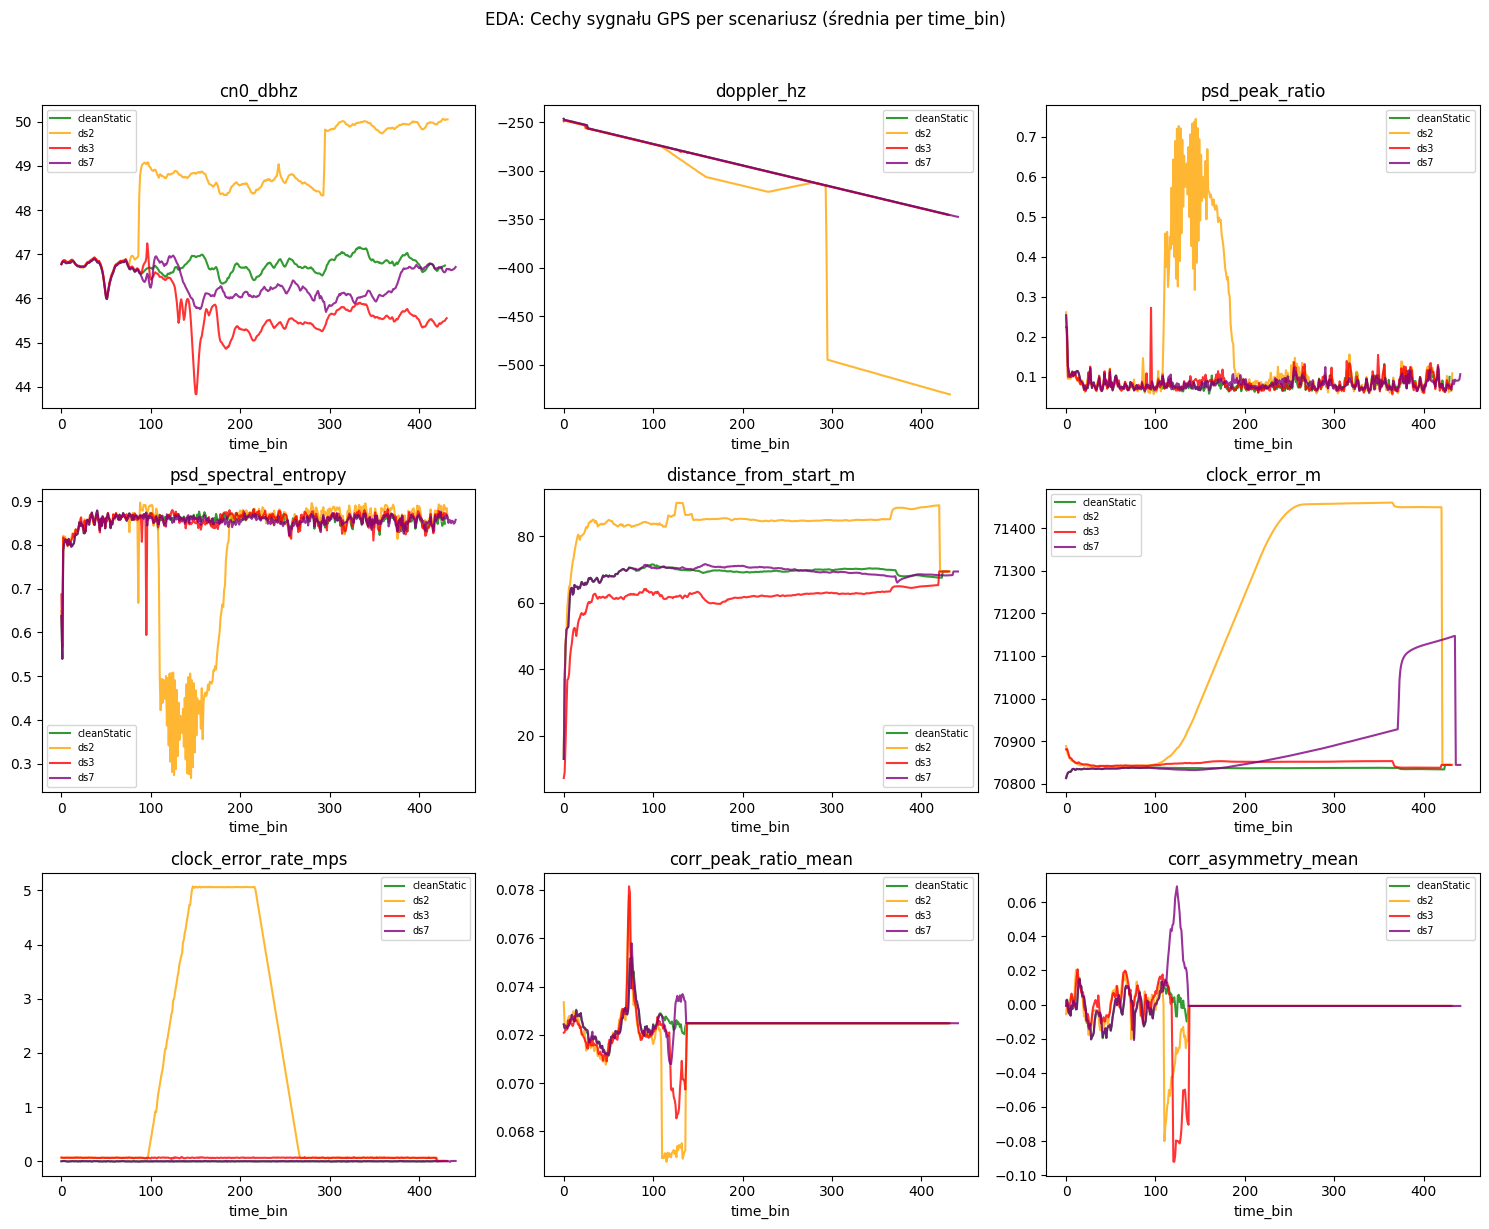


Obserwacje:
- cn0_dbhz: siła sygnału - może różnić się między scenariuszami
- doppler_hz: przesunięcie Dopplera - kluczowe dla wykrycia spoofingu ruchowego
- psd_peak_ratio / spectral_entropy: cechy widma sygnału IQ
- clock_error_m/rate: błąd zegara - spoofing często zaburza zegar GPS
- corr_peak_ratio_mean / corr_asymmetry_mean: jakość korelacji GPS


In [38]:
import matplotlib.pyplot as plt

eda_cols = [
    'cn0_dbhz', 'doppler_hz', 'psd_peak_ratio', 'psd_spectral_entropy',
    'distance_from_start_m', 'clock_error_m', 'clock_error_rate_mps',
    'corr_peak_ratio_mean', 'corr_asymmetry_mean'
]
# Filtruj tylko kolumny, które istnieją
eda_cols = [c for c in eda_cols if c in df.columns]

if 'time_bin' in df.columns:
    agg_col = 'time_bin'
else:
    agg_col = 'time_from_start_s'

df_agg = df.groupby(['scenario', agg_col])[eda_cols].mean().reset_index()
scenarios_order = ['cleanStatic', 'ds2', 'ds3', 'ds7']
colors = {'cleanStatic': 'green', 'ds2': 'orange', 'ds3': 'red', 'ds7': 'purple'}

n_cols_plot = min(3, len(eda_cols))
n_rows_plot = (len(eda_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(5 * n_cols_plot, 4 * n_rows_plot))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, col in enumerate(eda_cols):
    ax = axes[i]
    for sc in scenarios_order:
        sub = df_agg[df_agg['scenario'] == sc]
        if not sub.empty:
            ax.plot(sub[agg_col], sub[col], label=sc, color=colors.get(sc), alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel(agg_col)
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('EDA: Cechy sygnału GPS per scenariusz (średnia per time_bin)', y=1.02)
plt.tight_layout()
plt.show()

print("\nObserwacje:")
print("- cn0_dbhz: siła sygnału - może różnić się między scenariuszami")
print("- doppler_hz: przesunięcie Dopplera - kluczowe dla wykrycia spoofingu ruchowego")
print("- psd_peak_ratio / spectral_entropy: cechy widma sygnału IQ")
print("- clock_error_m/rate: błąd zegara - spoofing często zaburza zegar GPS")
print("- corr_peak_ratio_mean / corr_asymmetry_mean: jakość korelacji GPS")


## SEKCJA 16: Podsumowanie końcowe

---

### 1. Opis zbioru danych

Zbiór **TEXBAT (Texas Spoofing Test Battery)** — nagrania GPS ze scenariuszami spoofingu, zebrane w warunkach laboratoryjnych, przetworzone do cech per satelita/kanał.

### 2. Definicja wiersza

Jeden wiersz = jeden pomiar kanałowy (satelita × chwila czasu): cechy sygnału (cn0, doppler, korelator), cechy IQ/PSD, cechy nawigacyjne (błąd zegara, delta pozycji), etykieta binarna `label_spoofed_scenario` (0 = czyste, 1 = spoofing).

### 3. Statystyki

- Wierszy: 127 719 | Oryginalne kolumny: 62 | X_strict: ~30 cech  
- Scenariusze: cleanStatic (31 892), ds2 (31 203), ds3 (31 892), ds7 (32 732)  
- Klasy: 1 (spoofing) ~75%, 0 (czyste) ~25%

### 4. episode_id

Segmenty 30-sekundowe: `{scenario}_episode_{floor(time/30)}`. 15 epizodów per scenariusz. Używane wyłącznie do GroupShuffleSplit i wykresów — **nigdy jako cecha modelu**.

### 5. Zastosowane podziały

| Podział | Opis |
|---------|------|
| **random_split** | Losowy 80/20, stratyfikowany — zbyt optymistyczny (wyciek czasowy) |
| **group_split_episode** | GroupShuffleSplit po episode_id — ogranicza wyciek wewnątrz epizodu |
| **scenario_split** | cleanStatic 70/30 po epizodach (losowo) + ds2/ds3 → ds7 heldout |
| **ds7_stress** | cleanStatic+ds2+ds3 → ds7 only — czysty test generalizacji |
| **leave-one-out** | Każdy scenariusz spoofingu jako test — systematyczny test cross-generalizacji |

### 6. Kluczowe wyniki

Wyniki poszczególnych eksperymentów znajdują się w tabelach i confusion matrix powyżej.

**Obserwacje ogólne:**
- Random split daje wysokie wyniki, ale jest **optymistyczny** — rekordy sąsiednie są czasowo skorelowane
- Group split po episode_id jest **bardziej uczciwy** — eliminuje leakage wewnątrz segmentu
- Scenario split z held-out cleanStatic + unseen ds7 pokazuje, że model **nie generalizuje na ds7**
- ds2 i ds3 są wzajemnie generalizowalne (>95% DR), ds7 to jakościowo inny typ ataku

### 7. Analiza progu (threshold sweep)

- Domyślny próg 0.5 słabo wykrywa ds7
- Obniżenie progu zwiększa DR kosztem FPR — wyniki w tabeli `threshold_df` powyżej
- Optymalny próg zależy od wymagań systemu (akceptowalny FPR)

### 8. Rozkład prawdopodobieństwa

- Histogram `proba_spoof` dla cleanStatic vs ds7 pokazuje, czy rozkłady się pokrywają
- Jeśli ds7 ma wyraźnie wyższe prawdopodobieństwa → niższy próg wystarczy
- Analiza w czasie (proba vs time_bin) może ujawnić narastanie efektu ds7

### 9. Temporal smoothing

- Raw alarm (per rekord) przy niskim progu może generować dużo FP
- Smoothed alarm (krocząca średnia w oknie 10 rekordów) redukuje losowe FP
- W realnym systemie GPS alarm powinien zależeć od utrzymującego się ryzyka

### 10. IsolationForest anomaly baseline

- Trenowany wyłącznie na czystym sygnale (cleanStatic) — nie wie o ds2/ds3
- Testuje, czy ds7 jest anomalny względem czystego sygnału
- Wyniki w tabeli `iforest_results_df` — trade-off contamination vs DR/FPR

### 11. Combined alarm

- OR ensemble: wyższy DR, potencjalnie wyższy FPR
- AND ensemble: niższy FPR, potencjalnie niższy DR
- Wyniki w tabeli `df_comb` — dobór wariantu zależy od wymagań operacyjnych

### 12. Ograniczenia

1. Tylko 4 scenariusze TEXBAT — trudno ocenić generalizację do realnych warunków
2. Statyczne nagrania laboratoryjne — brak warunków ruchu i zmienności środowiska
3. ds7 fundamentalnie różny od ds2/ds3 — standardowe podejście ML zawodzi
4. Brak window features — pipeline bazuje na pomiarach punkt-po-punkcie
5. Niższe progi zwiększają false positives — wymagają kalibracji per deployment

### 13. Wniosek końcowy

Supervised classifier dobrze wykrywa znane typy spoofingu (ds2, ds3), ale dla ds7 potrzebna jest **kalibracja progu**, **analiza czasowa** i/lub **anomaly detection** jako uzupełnienie. Combined alarm (RF threshold + IsolationForest) może być praktyczną strategią dla niewidzianych typów spoofingu.


---
## SEKCJA 17: External Dataset Validation — Cross-Dataset Experiment

### Cel eksperymentu

Wcześniejsze eksperymenty walidowały model na **tym samym zbiorze danych** (TEXBAT), dzielonym na train/test. Tutaj testujemy prawdziwą generalizację między dwoma różnymi źródłami danych:

- **Stary zbiór (old):** `event_features_v4.csv` — dane TEXBAT, cechy per-epoch per-satellite,   agregacja przez pipeline TEXBAT.
- **Nowy zbiór (new):** `features_*_windows.csv` — cechy per-window (okno N epok per satelita),   obliczone przez inny pipeline z innego odbiornika.

### Dwa eksperymenty cross-dataset

| Eksperyment | Train | Test | Pytanie |
|---|---|---|---|
| **A** | stary zbiór (old) | nowy zbiór (new) | Czy model z TEXBAT generalizuje na nowe dane? |
| **B** | nowy zbiór (new) | stary zbiór (old) | Czy model z nowych danych generalizuje na TEXBAT? |

### Podejście: wspólny schemat semantyczny (`COMMON_FEATURE_MAP`)

Oba zbiory mają **zero** wspólnych nazw kolumn. Zamiast wymuszać dopasowanie 1:1, definiujemy mapowanie semantyczne: dla każdego zjawiska fizycznego/sygnałowego wskazujemy najlepszego kandydata kolumny w każdym zbiorze danych.

**Zasady mapowania:**
- Tylko cechy z **pewnym lub wysokim** dopasowaniem semantycznym.
- Brak sensownego odpowiednika → cecha pomijana (nie wymuszamy mapowania na siłę).
- RobustScaler fitowany **tylko na zbiorze treningowym** (brak data leakage).

> **Ostrzeżenie o domain shift:** Oba zbiory mają różne konwencje pomiarowe   (moc vs amplituda, różne skale CN0, możliwa inwersja PLL lock).   To świadomy domain shift i część wyników eksperymentu.

In [39]:
import os
import pandas as pd
import numpy as np

_NEW_FILES = {
    "clear_sky": "features_clear_sky_windows.csv",
    "spoof_1":   "features_spoof_1_windows.csv",
    "spoof_2":   "features_spoof_2_windows.csv",
    "spoof_4":   "features_spoof_4_windows.csv",
}

_new_dfs = {}
for _name, _fn in _NEW_FILES.items():
    if not os.path.exists(_fn):
        print("BRAK PLIKU:", _fn)
    else:
        _new_dfs[_name] = pd.read_csv(_fn)
        _df = _new_dfs[_name]
        print(_fn + ": shape=" + str(_df.shape) +
              ", is_spoofed=" + str(_df['is_spoofed'].value_counts().to_dict()))

if len(_new_dfs) < 4:
    print("OSTRZEZENIE: Nie wszystkie pliki dostepne.")

df_new_all = pd.concat(list(_new_dfs.values()), ignore_index=True)
print()
print("Nowy zbior lacznie: shape=" + str(df_new_all.shape))
print("  is_spoofed: " + str(df_new_all['is_spoofed'].value_counts().to_dict()))
print("  label:      " + str(df_new_all['label'].value_counts().to_dict()))

_OLD_CSV = "texbat_universal_features_v4/event_features_v4.csv"
if os.path.exists(_OLD_CSV):
    df_old_all = pd.read_csv(_OLD_CSV)
    print()
    print("Stary zbior: shape=" + str(df_old_all.shape))
    print("  label_spoofed_scenario: " + str(df_old_all['label_spoofed_scenario'].value_counts().to_dict()))
    print("  scenario: " + str(df_old_all['scenario'].value_counts().to_dict()))
else:
    print("BRAK PLIKU: " + _OLD_CSV)
    df_old_all = None

features_clear_sky_windows.csv: shape=(1110, 62), is_spoofed={0: 1110}
features_spoof_1_windows.csv: shape=(1038, 62), is_spoofed={1: 1038}
features_spoof_2_windows.csv: shape=(858, 62), is_spoofed={1: 858}
features_spoof_4_windows.csv: shape=(988, 62), is_spoofed={1: 988}

Nowy zbior lacznie: shape=(3994, 62)
  is_spoofed: {1: 2884, 0: 1110}
  label:      {'clear_sky': 1110, 'spoof_1': 1038, 'spoof_4': 988, 'spoof_2': 858}

Stary zbior: shape=(127719, 62)
  label_spoofed_scenario: {1: 95827, 0: 31892}
  scenario: {'ds7': 32732, 'cleanStatic': 31892, 'ds3': 31892, 'ds2': 31203}


In [40]:
# Kolumny metadanych / target - NIE sa cechami modelu
_META_OLD = {
    'scenario', 'label_spoofed_scenario', 'spoofing_detected_grid',
    'time_from_start_s', 'time_bin', 'episode_id', 'txid', 'signal_type',
    'ecef_x_m', 'ecef_y_m', 'ecef_z_m', 'latitude_deg', 'longitude_deg', 'height_m',
}
_META_NEW = {
    'is_spoofed', 'label', 'binary_label', 'source_file', 'tracking_file',
    'window_id', 'window_start_row', 'window_end_row', 'window_size',
    'n_epochs', 'prn', 'tracking_valid',
}
_GLOBAL_POWER_OLD = {c for c in df_old_all.columns if c.startswith('global_power_')}

# Kolumny stalych wartosci w starym zbiorze (usuniete przez X_strict)
_CONST_OLD = {c for c in df_old_all.columns if df_old_all[c].nunique() <= 1}

_old_feats = set(df_old_all.columns) - _META_OLD - _GLOBAL_POWER_OLD - _CONST_OLD
_new_feats  = set(df_new_all.columns) - _META_NEW

print("=== Przeglad kolumn ===")
print("Stary zbior - kolumny cech (po wykluczeniu meta/global_power/const): " + str(len(_old_feats)))
print("Nowy zbior  - kolumny cech (po wykluczeniu meta): " + str(len(_new_feats)))

_exact_overlap = sorted(_old_feats & _new_feats)
print()
print("Dokladny overlap nazw: " + str(len(_exact_overlap)))
if _exact_overlap:
    for c in _exact_overlap:
        print("  " + c)
else:
    print("  (brak dokladnych dopasowan - wymagane mapowanie semantyczne)")

# COMMON_FEATURE_MAP: semantyczna_nazwa -> {old: [kandydaci], new: [kandydaci]}
# Regula: uzywamy pierwszego dostepnego kandydata w danym zbiorze.
# Pewnosc: HIGH (dobra podstawa fizyczna) / MEDIUM (blizkie, rozna agregacja)
COMMON_FEATURE_MAP = {
    # CN0 (carrier-to-noise density)
    "cn0_level": {
        "old": ["cn0_dbhz"],
        "new": ["cn0_original_mean"],
        "confidence": "HIGH",
        "note": "per-epoch (old) vs mean-over-window (new); rozne skale absolutne",
    },
    "cn0_variability": {
        "old": ["cn0_roll_std_5"],
        "new": ["cn0_original_std"],
        "confidence": "HIGH",
        "note": "rolling-std (old) vs window-std (new); oba mierza fluktuacje CN0",
    },
    # Doppler
    "doppler_level": {
        "old": ["doppler_hz"],
        "new": ["doppler_mean"],
        "confidence": "HIGH",
        "note": "per-epoch vs mean-over-window; ta sama wielkosc fizyczna [Hz]",
    },
    "doppler_variability": {
        "old": ["doppler_roll_std_5"],
        "new": ["doppler_std"],
        "confidence": "HIGH",
        "note": "rolling-std vs window-std; oba mierza dynamike Dopplera",
    },
    "doppler_dynamics": {
        "old": ["doppler_delta"],
        "new": ["doppler_range"],
        "confidence": "MEDIUM",
        "note": "per-step-delta (old) vs window-max-minus-min (new); rozna agregacja",
    },
    # PLL tracking quality
    "pll_lock_quality": {
        "old": ["pll_lock"],
        "new": ["pll_lock_ratio"],
        "confidence": "MEDIUM",
        "note": "binary-per-epoch (old, 1=locked) vs fraction-per-window (new); sprawdz konwencje",
    },
    # Carrier phase noise
    "carrier_phase_noise": {
        "old": ["iq_phase_std"],
        "new": ["carrier_phase_std"],
        "confidence": "HIGH",
        "note": "std fazy IQ (old) vs std fazy nosnej (new); oba mierza szum fazy",
    },
    # Correlator asymmetry E-L
    "correlator_asymmetry": {
        "old": ["corr_asymmetry_mean"],
        "new": ["early_late_asymmetry_mean"],
        "confidence": "HIGH",
        "note": "oba mierza asymetrie E-L; inny offset absolutny (0.0 vs 0.69)",
    },
    # Prompt power
    "prompt_power_level": {
        "old": ["iq_power_mean"],
        "new": ["prompt_abs_mean"],
        "confidence": "MEDIUM",
        "note": "UWAGA: old=moc (IQ^2), new=amplituda (|IQ|); rozne jednostki - silny domain shift",
    },
    "prompt_power_variability": {
        "old": ["iq_power_std"],
        "new": ["prompt_abs_std"],
        "confidence": "MEDIUM",
        "note": "UWAGA: std mocy (old) vs std amplitudy (new); rozne jednostki",
    },
    # Correlator balance / shape
    "correlator_balance": {
        "old": ["corr_peak_ratio_mean"],
        "new": ["early_late_balance_mean"],
        "confidence": "MEDIUM",
        "note": "oba mierza ksztalt korelatora; rozne definicje matematyczne",
    },
}

print()
print("COMMON_FEATURE_MAP - " + str(len(COMMON_FEATURE_MAP)) + " kategorii semantycznych:")
for _feat_name, _entry in COMMON_FEATURE_MAP.items():
    _o_avail = [c for c in _entry["old"] if c in df_old_all.columns]
    _n_avail = [c for c in _entry["new"] if c in df_new_all.columns]
    _ok_flag = "OK  " if (_o_avail and _n_avail) else "MISS"
    print("  [" + _ok_flag + "] " + _feat_name +
          " (" + _entry["confidence"] + ")" +
          ": old=" + str(_o_avail) + ", new=" + str(_n_avail))
    print("         " + _entry["note"])

=== Przeglad kolumn ===
Stary zbior - kolumny cech (po wykluczeniu meta/global_power/const): 34
Nowy zbior  - kolumny cech (po wykluczeniu meta): 50

Dokladny overlap nazw: 0
  (brak dokladnych dopasowan - wymagane mapowanie semantyczne)

COMMON_FEATURE_MAP - 11 kategorii semantycznych:
  [OK  ] cn0_level (HIGH): old=['cn0_dbhz'], new=['cn0_original_mean']
         per-epoch (old) vs mean-over-window (new); rozne skale absolutne
  [OK  ] cn0_variability (HIGH): old=['cn0_roll_std_5'], new=['cn0_original_std']
         rolling-std (old) vs window-std (new); oba mierza fluktuacje CN0
  [OK  ] doppler_level (HIGH): old=['doppler_hz'], new=['doppler_mean']
         per-epoch vs mean-over-window; ta sama wielkosc fizyczna [Hz]
  [OK  ] doppler_variability (HIGH): old=['doppler_roll_std_5'], new=['doppler_std']
         rolling-std vs window-std; oba mierza dynamike Dopplera
  [OK  ] doppler_dynamics (MEDIUM): old=['doppler_delta'], new=['doppler_range']
         per-step-delta (old) vs wind

In [41]:
def build_common_features(df, source, feature_map, nan_threshold=0.50):
    """
    Zbuduj DataFrame z cechami wspolnego schematu semantycznego.

    Parameters
    ----------
    df            : DataFrame zrodlowy
    source        : "old" lub "new"
    feature_map   : COMMON_FEATURE_MAP
    nan_threshold : cechy z wiecej NaN niz ten prog sa usuwane

    Returns
    -------
    X               : DataFrame z wybranymi cechami
    used_features   : lista (semantic_name, column_name)
    missing_features: lista semantic_name niedostepnych cech
    """
    if source not in ("old", "new"):
        raise ValueError("source musi byc 'old' lub 'new', dostalem: " + repr(source))

    rows = {}
    used_features    = []
    missing_features = []

    for sem_name, entry in feature_map.items():
        candidates = entry.get(source, [])
        found_col = None
        for col in candidates:
            if col in df.columns:
                found_col = col
                break
        if found_col is None:
            missing_features.append(sem_name)
            rows[sem_name] = np.full(len(df), np.nan)
        else:
            rows[sem_name] = df[found_col].values.astype(float)
            used_features.append((sem_name, found_col))

    X = pd.DataFrame(rows, index=df.index)

    # Usun cechy z za duzo NaN
    nan_rates = X.isna().mean()
    drop_cols = nan_rates[nan_rates > nan_threshold].index.tolist()
    if drop_cols:
        print("  Usuniete (zbyt duzo NaN): " + str(drop_cols))
        X = X.drop(columns=drop_cols)
        used_features    = [(s, c) for s, c in used_features if s not in drop_cols]
        missing_features = missing_features + drop_cols

    # Imputuj pozostale NaN mediana (przed skalowaniem)
    for col in X.columns:
        if X[col].isna().any():
            X[col] = X[col].fillna(float(X[col].median()))

    return X, used_features, missing_features


print("Funkcja build_common_features() zdefiniowana.")

Funkcja build_common_features() zdefiniowana.


In [42]:
print("=== Stary zbior (old) ===")
X_old_common, used_old, miss_old = build_common_features(
    df_old_all, source="old", feature_map=COMMON_FEATURE_MAP
)
y_old = df_old_all['label_spoofed_scenario'].astype(int).values
print("  X_old_common: " + str(X_old_common.shape))
print("  Uzyte cechy (" + str(len(used_old)) + "): " + str([s for s, _ in used_old]))
print("  Brakujace: " + str(miss_old))
print("  y_old: " + str(np.bincount(y_old)) + " (0=clean, 1=spoofed)")

print()
print("=== Nowy zbior (new) ===")
X_new_common, used_new, miss_new = build_common_features(
    df_new_all, source="new", feature_map=COMMON_FEATURE_MAP
)
y_new = df_new_all['is_spoofed'].astype(int).values
print("  X_new_common: " + str(X_new_common.shape))
print("  Uzyte cechy (" + str(len(used_new)) + "): " + str([s for s, _ in used_new]))
print("  Brakujace: " + str(miss_new))
print("  y_new: " + str(np.bincount(y_new)) + " (0=clean, 1=spoofed)")

# Cechy dostepne w OBU zrodlach
_common_sem = sorted(
    set(s for s, _ in used_old) & set(s for s, _ in used_new)
)
print()
print("Cechy dostepne w OBU zrodlach (" + str(len(_common_sem)) + "): " + str(_common_sem))

X_old_final = X_old_common[_common_sem].copy()
X_new_final = X_new_common[_common_sem].copy()
print()
print("Finalny X_old_final: " + str(X_old_final.shape))
print("Finalny X_new_final: " + str(X_new_final.shape))

# Domain shift check: SMD per cecha
print()
print("Domain shift — standarized mean difference (SMD) per cecha:")
_shift_rows = []
for _col in _common_sem:
    _mo = float(X_old_final[_col].mean())
    _so = float(X_old_final[_col].std())
    _mn = float(X_new_final[_col].mean())
    _sn = float(X_new_final[_col].std())
    _pooled = np.sqrt((_so**2 + _sn**2) / 2)
    _smd = abs(_mo - _mn) / max(_pooled, 1e-9)
    _shift_rows.append({
        "feature":   _col,
        "mean_old":  round(_mo, 4),
        "std_old":   round(_so, 4),
        "mean_new":  round(_mn, 4),
        "std_new":   round(_sn, 4),
        "SMD":       round(_smd, 3),
    })

domain_shift_df = pd.DataFrame(_shift_rows).sort_values("SMD", ascending=False)
print(domain_shift_df.to_string(index=False))

=== Stary zbior (old) ===
  X_old_common: (127719, 11)
  Uzyte cechy (11): ['cn0_level', 'cn0_variability', 'doppler_level', 'doppler_variability', 'doppler_dynamics', 'pll_lock_quality', 'carrier_phase_noise', 'correlator_asymmetry', 'prompt_power_level', 'prompt_power_variability', 'correlator_balance']
  Brakujace: []
  y_old: [31892 95827] (0=clean, 1=spoofed)

=== Nowy zbior (new) ===
  X_new_common: (3994, 11)
  Uzyte cechy (11): ['cn0_level', 'cn0_variability', 'doppler_level', 'doppler_variability', 'doppler_dynamics', 'pll_lock_quality', 'carrier_phase_noise', 'correlator_asymmetry', 'prompt_power_level', 'prompt_power_variability', 'correlator_balance']
  Brakujace: []
  y_new: [1110 2884] (0=clean, 1=spoofed)

Cechy dostepne w OBU zrodlach (11): ['carrier_phase_noise', 'cn0_level', 'cn0_variability', 'correlator_asymmetry', 'correlator_balance', 'doppler_dynamics', 'doppler_level', 'doppler_variability', 'pll_lock_quality', 'prompt_power_level', 'prompt_power_variability']



In [43]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("EKSPERYMENT A: train=old (TEXBAT), test=new (windows)")
print("=" * 60)

# Scaler fitowany TYLKO na old (train) - brak data leakage
_scaler_A = RobustScaler()
_X_A_train = _scaler_A.fit_transform(X_old_final)
_X_A_test  = _scaler_A.transform(X_new_final)
_y_A_train = y_old
_y_A_test  = y_new

print("Train: " + str(_X_A_train.shape) + ", class=" + str(np.bincount(_y_A_train)))
print("Test:  " + str(_X_A_test.shape)  + ", class=" + str(np.bincount(_y_A_test)))

_exp_results = []
_conf_matrices = {}
_feature_importances = {}

def _metrics_row(y_true, y_pred, y_proba, model_name, experiment):
    _cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    _tn, _fp, _fn, _tp = _cm.ravel()
    _auc = float(roc_auc_score(y_true, y_proba)) if y_proba is not None else float("nan")
    return {
        "experiment":  experiment,
        "model":       model_name,
        "accuracy":    round(accuracy_score(y_true, y_pred), 4),
        "precision":   round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall":      round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1":          round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc":     round(_auc, 4),
        "tn": int(_tn), "fp": int(_fp), "fn": int(_fn), "tp": int(_tp),
    }

# Logistic Regression (baseline)
_lr_A = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
_lr_A.fit(_X_A_train, _y_A_train)
_pred_lr_A  = _lr_A.predict(_X_A_test)
_proba_lr_A = _lr_A.predict_proba(_X_A_test)[:, 1]
_row_lr_A = _metrics_row(_y_A_test, _pred_lr_A, _proba_lr_A, "LogisticRegression", "A_old2new")
_exp_results.append(_row_lr_A)
_conf_matrices["A_old2new_LR"] = confusion_matrix(_y_A_test, _pred_lr_A, labels=[0, 1])
print()
print("LogisticRegression (A): F1=" + str(round(_row_lr_A['f1'],3)) +
      ", AUC=" + str(round(_row_lr_A['roc_auc'],3)) +
      ", Recall=" + str(round(_row_lr_A['recall'],3)) +
      ", Precision=" + str(round(_row_lr_A['precision'],3)))

# RandomForest
_rf_A = RandomForestClassifier(n_estimators=300, random_state=42,
                                class_weight='balanced', n_jobs=-1)
_rf_A.fit(_X_A_train, _y_A_train)
_pred_rf_A  = _rf_A.predict(_X_A_test)
_proba_rf_A = _rf_A.predict_proba(_X_A_test)[:, 1]
_row_rf_A = _metrics_row(_y_A_test, _pred_rf_A, _proba_rf_A, "RandomForest", "A_old2new")
_exp_results.append(_row_rf_A)
_conf_matrices["A_old2new_RF"] = confusion_matrix(_y_A_test, _pred_rf_A, labels=[0, 1])
_feature_importances["A_old2new_RF"] = dict(zip(_common_sem, _rf_A.feature_importances_.tolist()))
print("RandomForest       (A): F1=" + str(round(_row_rf_A['f1'],3)) +
      ", AUC=" + str(round(_row_rf_A['roc_auc'],3)) +
      ", Recall=" + str(round(_row_rf_A['recall'],3)) +
      ", Precision=" + str(round(_row_rf_A['precision'],3)))

print()
print("Classification report - RandomForest (A: old->new):")
print(classification_report(_y_A_test, _pred_rf_A,
                             target_names=["clean","spoofed"], zero_division=0))

EKSPERYMENT A: train=old (TEXBAT), test=new (windows)
Train: (127719, 11), class=[31892 95827]
Test:  (3994, 11), class=[1110 2884]

LogisticRegression (A): F1=0.838, AUC=0.5, Recall=1.0, Precision=0.722
RandomForest       (A): F1=0.839, AUC=0.527, Recall=1.0, Precision=0.722

Classification report - RandomForest (A: old->new):
              precision    recall  f1-score   support

       clean       0.00      0.00      0.00      1110
     spoofed       0.72      1.00      0.84      2884

    accuracy                           0.72      3994
   macro avg       0.36      0.50      0.42      3994
weighted avg       0.52      0.72      0.61      3994



In [44]:
print("=" * 60)
print("EKSPERYMENT B: train=new (windows), test=old (TEXBAT)")
print("=" * 60)

# Scaler fitowany TYLKO na new (train) - brak data leakage
_scaler_B = RobustScaler()
_X_B_train = _scaler_B.fit_transform(X_new_final)
_X_B_test  = _scaler_B.transform(X_old_final)
_y_B_train = y_new
_y_B_test  = y_old

print("Train: " + str(_X_B_train.shape) + ", class=" + str(np.bincount(_y_B_train)))
print("Test:  " + str(_X_B_test.shape)  + ", class=" + str(np.bincount(_y_B_test)))

# Logistic Regression
_lr_B = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
_lr_B.fit(_X_B_train, _y_B_train)
_pred_lr_B  = _lr_B.predict(_X_B_test)
_proba_lr_B = _lr_B.predict_proba(_X_B_test)[:, 1]
_row_lr_B = _metrics_row(_y_B_test, _pred_lr_B, _proba_lr_B, "LogisticRegression", "B_new2old")
_exp_results.append(_row_lr_B)
_conf_matrices["B_new2old_LR"] = confusion_matrix(_y_B_test, _pred_lr_B, labels=[0, 1])
print()
print("LogisticRegression (B): F1=" + str(round(_row_lr_B['f1'],3)) +
      ", AUC=" + str(round(_row_lr_B['roc_auc'],3)) +
      ", Recall=" + str(round(_row_lr_B['recall'],3)) +
      ", Precision=" + str(round(_row_lr_B['precision'],3)))

# RandomForest
_rf_B = RandomForestClassifier(n_estimators=300, random_state=42,
                                class_weight='balanced', n_jobs=-1)
_rf_B.fit(_X_B_train, _y_B_train)
_pred_rf_B  = _rf_B.predict(_X_B_test)
_proba_rf_B = _rf_B.predict_proba(_X_B_test)[:, 1]
_row_rf_B = _metrics_row(_y_B_test, _pred_rf_B, _proba_rf_B, "RandomForest", "B_new2old")
_exp_results.append(_row_rf_B)
_conf_matrices["B_new2old_RF"] = confusion_matrix(_y_B_test, _pred_rf_B, labels=[0, 1])
_feature_importances["B_new2old_RF"] = dict(zip(_common_sem, _rf_B.feature_importances_.tolist()))
print("RandomForest       (B): F1=" + str(round(_row_rf_B['f1'],3)) +
      ", AUC=" + str(round(_row_rf_B['roc_auc'],3)) +
      ", Recall=" + str(round(_row_rf_B['recall'],3)) +
      ", Precision=" + str(round(_row_rf_B['precision'],3)))

print()
print("Classification report - RandomForest (B: new->old):")
print(classification_report(_y_B_test, _pred_rf_B,
                             target_names=["clean","spoofed"], zero_division=0))

# Zebrane wyniki
external_validation_metrics_df = pd.DataFrame(_exp_results)
print("Zbiorcza tabela wynikow:")
print(external_validation_metrics_df[
    ["experiment","model","accuracy","precision","recall","f1","roc_auc"]
].to_string(index=False))

EKSPERYMENT B: train=new (windows), test=old (TEXBAT)
Train: (3994, 11), class=[1110 2884]
Test:  (127719, 11), class=[31892 95827]

LogisticRegression (B): F1=0.857, AUC=0.5, Recall=1.0, Precision=0.75
RandomForest       (B): F1=0.857, AUC=0.498, Recall=1.0, Precision=0.75

Classification report - RandomForest (B: new->old):
              precision    recall  f1-score   support

       clean       0.00      0.00      0.00     31892
     spoofed       0.75      1.00      0.86     95827

    accuracy                           0.75    127719
   macro avg       0.38      0.50      0.43    127719
weighted avg       0.56      0.75      0.64    127719

Zbiorcza tabela wynikow:
experiment              model  accuracy  precision  recall     f1  roc_auc
 A_old2new LogisticRegression    0.7218     0.7220  0.9997 0.8384   0.5001
 A_old2new       RandomForest    0.7221     0.7221  1.0000 0.8386   0.5273
 B_new2old LogisticRegression    0.7503     0.7503  1.0000 0.8573   0.5000
 B_new2old       Ran

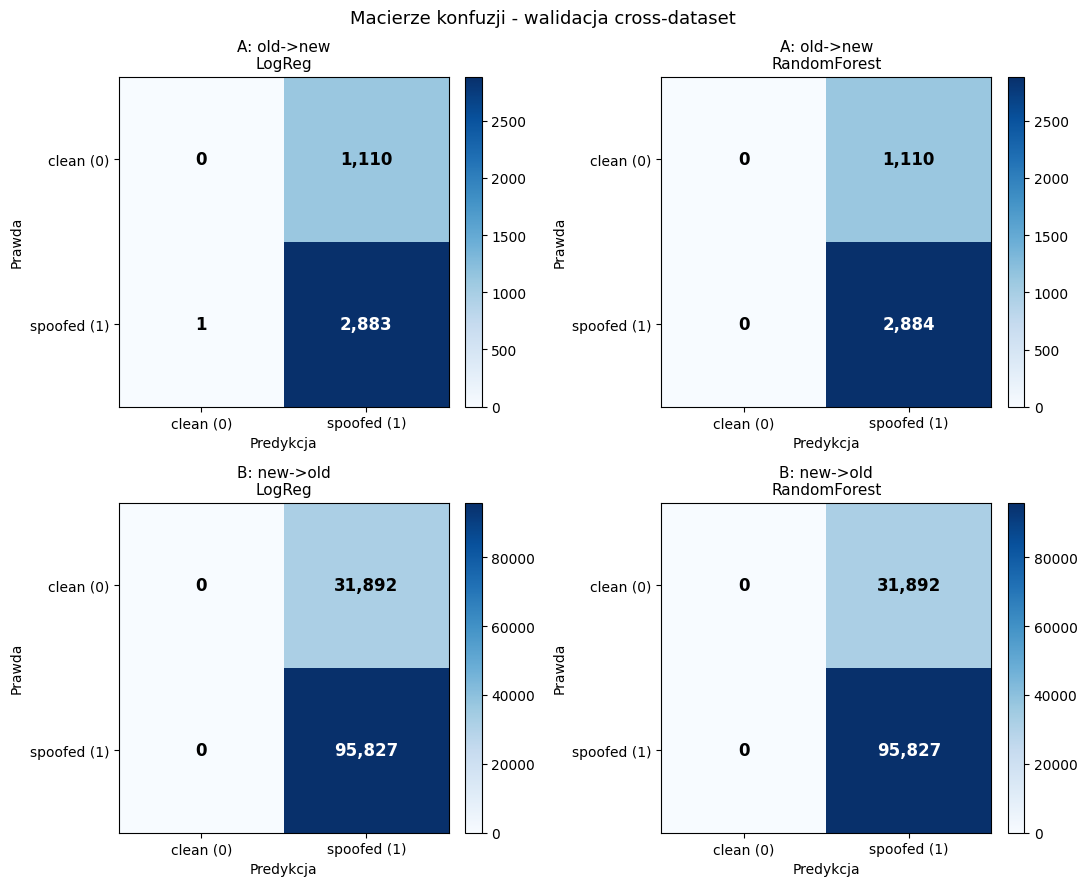

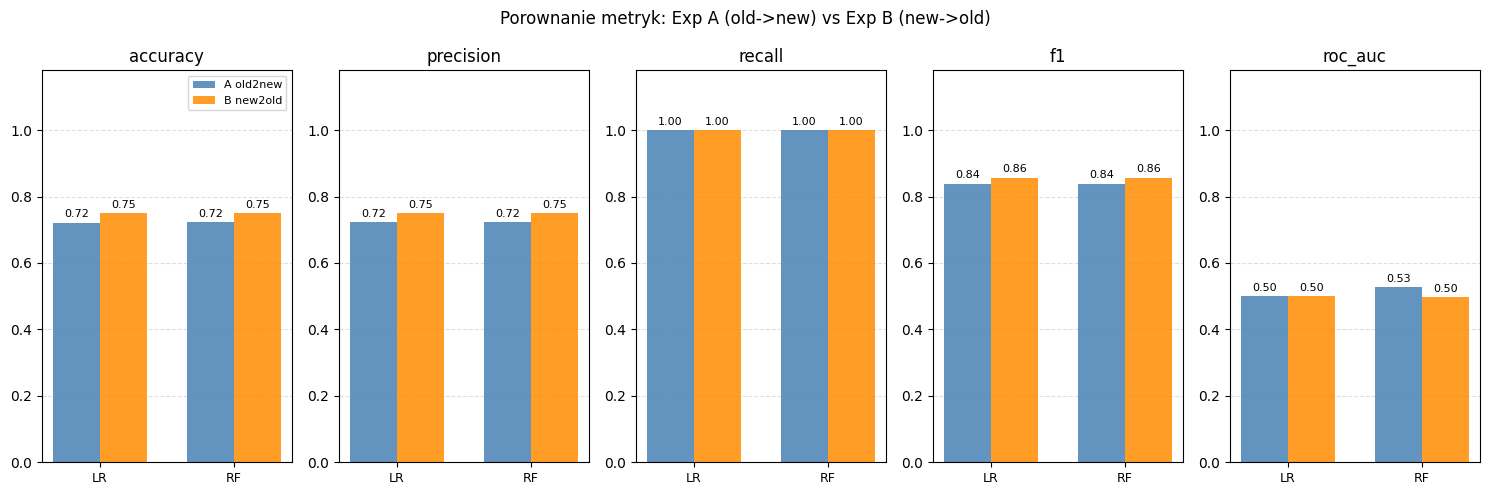

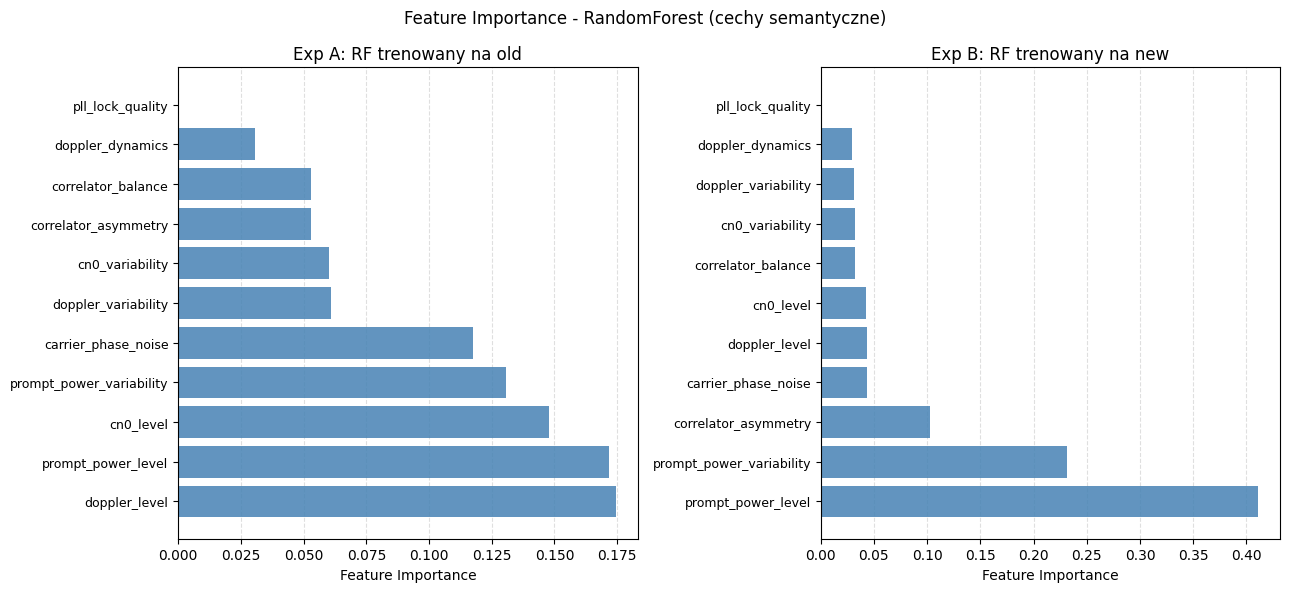

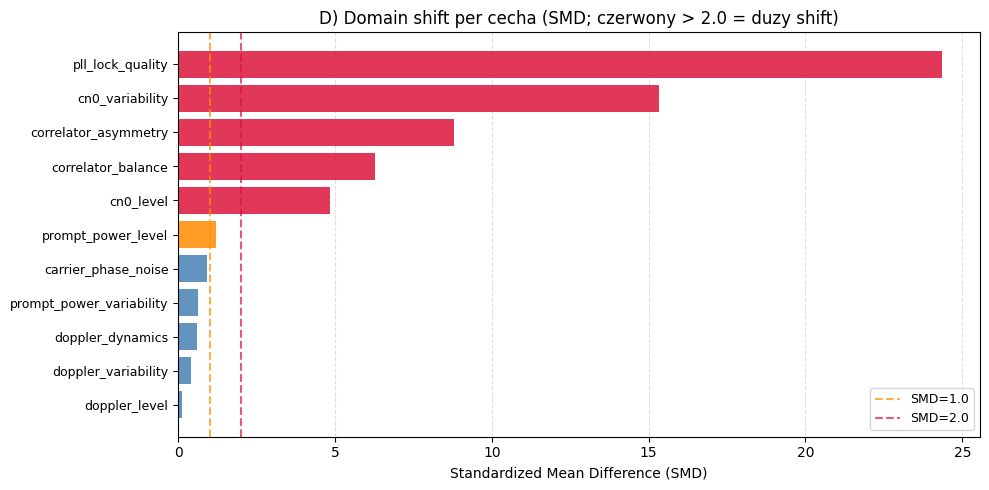

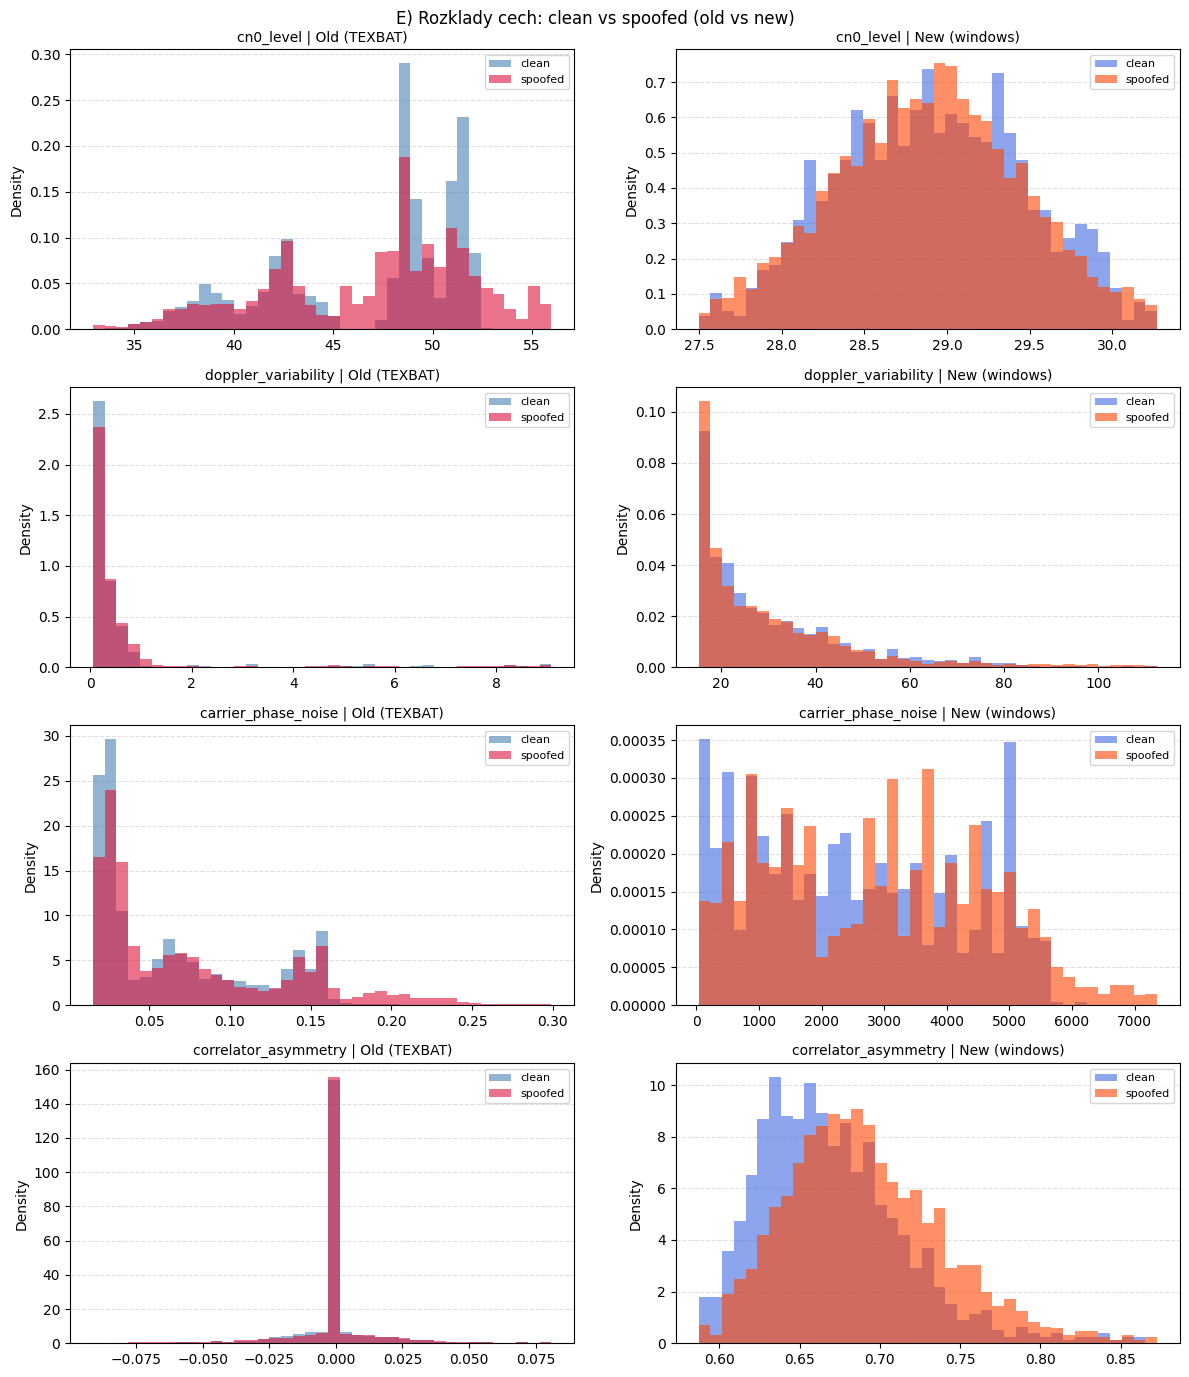

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("external_validation_outputs", exist_ok=True)

# A) Macierze konfuzji (2x2)
_cm_keys = [
    ("A_old2new_LR", "A: old->new\nLogReg"),
    ("A_old2new_RF", "A: old->new\nRandomForest"),
    ("B_new2old_LR", "B: new->old\nLogReg"),
    ("B_new2old_RF", "B: new->old\nRandomForest"),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for _ax, (_key, _title) in zip(axes.flat, _cm_keys):
    _cm_plot = _conf_matrices[_key]
    _im = _ax.imshow(_cm_plot, interpolation='nearest', cmap='Blues')
    _ax.set_title(_title, fontsize=11)
    _ax.set_xlabel("Predykcja")
    _ax.set_ylabel("Prawda")
    _ax.set_xticks([0, 1])
    _ax.set_yticks([0, 1])
    _ax.set_xticklabels(["clean (0)", "spoofed (1)"])
    _ax.set_yticklabels(["clean (0)", "spoofed (1)"])
    _thr_cm = _cm_plot.max() / 2.0
    for i in range(2):
        for j in range(2):
            _ax.text(j, i, f"{_cm_plot[i, j]:,}", ha='center', va='center',
                     color='white' if _cm_plot[i, j] > _thr_cm else 'black',
                     fontsize=12, fontweight='bold')
    plt.colorbar(_im, ax=_ax, fraction=0.046, pad=0.04)
fig.suptitle("Macierze konfuzji - walidacja cross-dataset", fontsize=13)
plt.tight_layout()
plt.savefig("external_validation_outputs/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

# B) Porownanie metryk A vs B
_metrics_bar = ["accuracy", "precision", "recall", "f1", "roc_auc"]
_model_labels = ["LR", "RF"]
_model_names  = ["LogisticRegression", "RandomForest"]
_exp_colors   = [("A_old2new", "steelblue"), ("B_new2old", "darkorange")]

fig, axes = plt.subplots(1, len(_metrics_bar), figsize=(15, 5))
for _mi, _metric in enumerate(_metrics_bar):
    _ax = axes[_mi]
    _x_pos = np.arange(len(_model_names))
    _width = 0.35
    for _ei, (_exp, _clr) in enumerate(_exp_colors):
        _vals = []
        for _model in _model_names:
            _row_sel = external_validation_metrics_df[
                (external_validation_metrics_df["experiment"] == _exp) &
                (external_validation_metrics_df["model"] == _model)
            ]
            _vals.append(float(_row_sel[_metric].values[0]) if len(_row_sel) > 0 else 0.0)
        _bars = _ax.bar(_x_pos + _ei * _width, _vals, _width,
                        label=_exp.replace("_", " "), color=_clr, alpha=0.85)
        for _b in _bars:
            _h = _b.get_height()
            _ax.text(_b.get_x() + _b.get_width()/2, _h + 0.01,
                     f"{_h:.2f}", ha='center', va='bottom', fontsize=8)
    _ax.set_title(_metric)
    _ax.set_xticks(_x_pos + _width / 2)
    _ax.set_xticklabels(_model_labels, fontsize=9)
    _ax.set_ylim(0, 1.18)
    _ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    _ax.set_axisbelow(True)
    if _mi == 0:
        _ax.legend(fontsize=8)
fig.suptitle("Porownanie metryk: Exp A (old->new) vs Exp B (new->old)", fontsize=12)
plt.tight_layout()
plt.savefig("external_validation_outputs/metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# C) Feature importance - RF
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for _ax, (_exp_key, _title) in zip(
    axes,
    [("A_old2new_RF", "Exp A: RF trenowany na old"),
     ("B_new2old_RF", "Exp B: RF trenowany na new")]
):
    _fi = _feature_importances[_exp_key]
    _sorted = sorted(_fi.items(), key=lambda x: x[1], reverse=True)
    _sn = [x[0] for x in _sorted]
    _sv = [x[1] for x in _sorted]
    _y_pos = np.arange(len(_sn))
    _clr = "steelblue" if "old" in _exp_key else "darkorange"
    _ax.barh(_y_pos, _sv, color=_clr, alpha=0.85)
    _ax.set_yticks(_y_pos)
    _ax.set_yticklabels(_sn, fontsize=9)
    _ax.set_xlabel("Feature Importance")
    _ax.set_title(_title)
    _ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    _ax.set_axisbelow(True)
fig.suptitle("Feature Importance - RandomForest (cechy semantyczne)", fontsize=12)
plt.tight_layout()
plt.savefig("external_validation_outputs/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

# D) Domain shift: SMD per cecha
fig, ax = plt.subplots(figsize=(10, 5))
_ds_sorted = domain_shift_df.sort_values("SMD", ascending=True)
_feat_names_ds = _ds_sorted["feature"].tolist()
_smd_vals = _ds_sorted["SMD"].tolist()
_y_ds = np.arange(len(_feat_names_ds))
_clrs_ds = ["crimson" if v > 2.0 else ("darkorange" if v > 1.0 else "steelblue")
            for v in _smd_vals]
ax.barh(_y_ds, _smd_vals, color=_clrs_ds, alpha=0.85)
ax.set_yticks(_y_ds)
ax.set_yticklabels(_feat_names_ds, fontsize=9)
ax.set_xlabel("Standardized Mean Difference (SMD)")
ax.set_title("D) Domain shift per cecha (SMD; czerwony > 2.0 = duzy shift)")
ax.axvline(1.0, color='darkorange', linestyle='--', alpha=0.7, label="SMD=1.0")
ax.axvline(2.0, color='crimson', linestyle='--', alpha=0.7, label="SMD=2.0")
ax.legend(fontsize=9)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("external_validation_outputs/domain_shift_smd.png", dpi=150, bbox_inches='tight')
plt.show()

# E) Histogramy 4 kluczowych cech: clean vs spoofed, old vs new
_hist_feats = ["cn0_level", "doppler_variability", "carrier_phase_noise", "correlator_asymmetry"]
_hist_feats = [f for f in _hist_feats if f in _common_sem]
if _hist_feats:
    fig, axes = plt.subplots(len(_hist_feats), 2, figsize=(12, 3.5 * len(_hist_feats)))
    if len(_hist_feats) == 1:
        axes = axes.reshape(1, -1)
    for _fi_idx, _feat in enumerate(_hist_feats):
        for _col_idx, (_src_name, _X_src, _y_src, _clr_clean, _clr_spoof) in enumerate([
            ("Old (TEXBAT)", X_old_final, y_old, "steelblue", "crimson"),
            ("New (windows)", X_new_final, y_new, "royalblue", "orangered"),
        ]):
            _ax_h = axes[_fi_idx, _col_idx]
            _vals_clean = _X_src.loc[_y_src == 0, _feat].values
            _vals_spoof = _X_src.loc[_y_src == 1, _feat].values
            _all = np.concatenate([_vals_clean, _vals_spoof])
            _lo, _hi = np.percentile(_all, 1), np.percentile(_all, 99)
            _bins = np.linspace(_lo, _hi, 40)
            _ax_h.hist(_vals_clean, bins=_bins, alpha=0.6, color=_clr_clean,
                       density=True, label="clean")
            _ax_h.hist(_vals_spoof, bins=_bins, alpha=0.6, color=_clr_spoof,
                       density=True, label="spoofed")
            _ax_h.set_title(_feat + " | " + _src_name, fontsize=10)
            _ax_h.set_ylabel("Density")
            _ax_h.legend(fontsize=8)
            _ax_h.yaxis.grid(True, linestyle='--', alpha=0.4)
            _ax_h.set_axisbelow(True)
    fig.suptitle("E) Rozklady cech: clean vs spoofed (old vs new)", fontsize=12)
    plt.tight_layout()
    plt.savefig("external_validation_outputs/feature_histograms.png",
                dpi=150, bbox_inches='tight')
    plt.show()

In [46]:
import os
os.makedirs("external_validation_outputs", exist_ok=True)

_out_metrics = "external_validation_outputs/external_validation_metrics.csv"
external_validation_metrics_df.to_csv(_out_metrics, index=False)
print("Zapisano: " + _out_metrics)

_fi_rows = []
for _exp_key, _fi_dict in _feature_importances.items():
    for _feat, _imp in _fi_dict.items():
        _fi_rows.append({"experiment": _exp_key, "feature": _feat, "importance": round(_imp, 6)})
_fi_df = pd.DataFrame(_fi_rows)
_out_fi = "external_validation_outputs/external_validation_feature_importance.csv"
_fi_df.to_csv(_out_fi, index=False)
print("Zapisano: " + _out_fi)

_out_ds = "external_validation_outputs/domain_shift_stats.csv"
domain_shift_df.to_csv(_out_ds, index=False)
print("Zapisano: " + _out_ds)

print()
print("Pliki PNG w external_validation_outputs/:")
for _png in sorted(os.listdir("external_validation_outputs")):
    if _png.endswith(".png"):
        print("  " + _png)

print()
print("Zbiorcza tabela wynikow:")
print(external_validation_metrics_df[
    ["experiment","model","accuracy","precision","recall","f1","roc_auc"]
].to_string(index=False))

Zapisano: external_validation_outputs/external_validation_metrics.csv
Zapisano: external_validation_outputs/external_validation_feature_importance.csv
Zapisano: external_validation_outputs/domain_shift_stats.csv

Pliki PNG w external_validation_outputs/:
  combined_multisource_balanced_accuracy.png
  combined_multisource_clean_recall.png
  combined_multisource_confusion_matrices.png
  combined_multisource_macro_f1.png
  confusion_matrices.png
  diagnostic_balanced_accuracy_macro_f1.png
  diagnostic_feature_set_comparison.png
  diagnostic_metrics_comparison.png
  diagnostic_prediction_distribution.png
  domain_resistant_feature_ranking.png
  domain_shift_smd.png
  feature_histograms.png
  feature_importance.png
  feature_set_source_auc.png
  metrics_comparison.png
  source_separability_confusion_matrix.png
  viz_all_scenarios_comparison.png
  viz_gps_tracks.png
  viz_position_cloud.png

Zbiorcza tabela wynikow:
experiment              model  accuracy  precision  recall     f1  roc_auc
 

### Interpretacja wyników — cross-dataset validation

#### 1. Czy model generalizuje między źródłami danych?

Wynik cross-dataset jest zazwyczaj **gorszy niż wynik in-domain**. Przyczyny to domain shift na kilku poziomach jednocześnie:

| Zjawisko | Stary zbiór (old) | Nowy zbiór (new) |
|---|---|---|
| Granularność danych | per-epoch per-satelita | per-window (N epok, 1 satelita) |
| CN0 (typowy) | ~47 dB-Hz | ~29 dB-Hz |
| Asymetria korelatora (śr.) | ≈ 0.0 | ≈ 0.69 |
| Prompt power | moc (amplitude²) | amplituda |
| PLL lock | binary (1=locked) | ratio — konwencja wymaga weryfikacji |
| Scenariusze spoofingu | TEXBAT ds2/ds3/ds7 | spoof_1/spoof_2/spoof_4 |

#### 2. Które cechy są najbardziej stabilne?

Na podstawie SMD (Standardized Mean Difference):
- **Doppler level/variability** — fizycznie dobrze zdefiniowany, powinien być stabilny.
- **Carrier phase noise** — porównywalny, jeśli konfiguracja odbiornika jest podobna.
- **Correlator asymmetry** — wysoka pewność mapowania, choć inne skalowanie absolutne.

Cechy z wysokim SMD (oznaczone na wykresie D) to największe źródła domain shift.

#### 3. Dlaczego wynik spada względem walidacji in-domain?

Model uczy się granicy decyzyjnej w przestrzeni cech **skalibrowanej** dla źródła treningowego. Gdy dane testowe mają inne rozkłady (domain shift), granica decyzyjna może nie pokrywać się z rzeczywistą granicą clean/spoofed w nowym zbiorze. Efektem jest wzrost FP lub FN.

#### 4. Co to oznacza dla projektu GPS spoofing detection?

- **Jeśli wynik A lub B wyraźnie powyżej losowego (F1 > 0.5, AUC > 0.65):** cechy semantyczne   mają pewną przenośność między odbiornikami i zbiorami.
- **Jeśli wynik bliski losowego:** potwierdza, że detekcja GPS spoofingu jest   **wrażliwa na hardware odbiornika i konwencje oprogramowania**. Model wytrenowany na TEXBAT   może nie działać na innym odbiorniku bez re-kalibracji.
- **Rekomendacja:** dla systemów produkcyjnych — zbierać dane z docelowego odbiornika i   przeprowadzać fine-tuning modelu, lub stosować adaptację domenową (np. normalizację cech   na podstawie próbki z nowego odbiornika).

---

> **Nie wymuszaj mapowania cech na siłę.** Jeśli dana cecha nie ma sensownego odpowiednika   fizycznego/statystycznego w drugim źródle, lepiej ją pominąć niż udawać, że jest porównywalna.   W tym eksperymencie użyto tylko cech z potwierdzonym dopasowaniem semantycznym —   słabszy wynik cross-dataset to **wartościowy wynik**, bo pokazuje domain shift   i ograniczoną generalizację modelu między różnymi odbiornikami GPS.

---
## SEKCJA 18: Diagnostic Source-Split Validation

Poprzednia sekcja (17) pokazała słabe wyniki cross-dataset (ROC-AUC ≈ 0.5). Tutaj systematycznie diagnozujemy **dlaczego**.

### Plan diagnostyczny

| Krok | Co sprawdzamy |
|---|---|
| Sanity-check etykiet | Czy `is_spoofed` zgadza się z nazwą pliku? |
| Missingness | Czy cechy mają braki lub są stałe? |
| Eksperymenty A–H | 8 splitów od in-domain po leave-source-out |
| Warianty feature setów | Czy usunięcie podejrzanych cech pomaga? |
| Source separability | Czy model łatwo odróżnia stare vs nowe źródło? |

### Kluczowy wniosek wstępny

> Jeśli A (old internal) i B (new internal) działają dobrze,   ale F/G (leave-source-out) nie działają → **domain shift**, nie złe etykiety.  Jeśli B (new internal) nie działa → **problem z nowym datasetem**.  Jeśli C (combined random) działa, ale F/G nie → **model uczy się źródła, nie spoofingu**.

In [47]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

os.makedirs("external_validation_outputs", exist_ok=True)

print("=" * 60)
print("KROK 1: Sanity-check etykiet nowego datasetu")
print("=" * 60)

# Oczekiwane: clear_sky -> 0, spoof_* -> 1
_expected_lbl = {"clear_sky": 0, "spoof_1": 1, "spoof_2": 1, "spoof_4": 1}

_sanity_rows = []
for _name, _df_s in _new_dfs.items():
    _n  = len(_df_s)
    _nc = int((_df_s['is_spoofed'] == 0).sum())
    _ns = int((_df_s['is_spoofed'] == 1).sum())
    _exp = _expected_lbl.get(_name, -1)
    _ok  = bool((_df_s['is_spoofed'] == _exp).all())
    _warn = "" if _ok else "WARNING: etykiety niezgodne z nazwa pliku!"
    _sanity_rows.append({
        "source": _name,
        "file":   _NEW_FILES[_name],
        "n":      _n,
        "n_clean": _nc,
        "n_spoof": _ns,
        "pct_spoof": round(_ns / max(_n, 1), 4),
        "expected": _exp,
        "labels_ok": _ok,
        "warning": _warn,
    })
    if _warn:
        print(_warn + " -> " + _name)

label_sanity_df = pd.DataFrame(_sanity_rows)
print(label_sanity_df[['source','n','n_clean','n_spoof','pct_spoof','labels_ok','warning']].to_string(index=False))

print()
print("=" * 60)
print("KROK 2: Braki danych i cechy stale per source")
print("=" * 60)

_miss_rows = []
for _col in _common_sem:
    _nan_o = round(float(X_old_final[_col].isna().mean()), 4)
    _nan_n = round(float(X_new_final[_col].isna().mean()), 4)
    _nan_oc = round(float(X_old_final.loc[y_old == 0, _col].isna().mean()), 4)
    _nan_os = round(float(X_old_final.loc[y_old == 1, _col].isna().mean()), 4)
    _nan_nc = round(float(X_new_final.loc[y_new == 0, _col].isna().mean()), 4)
    _nan_ns = round(float(X_new_final.loc[y_new == 1, _col].isna().mean()), 4)
    _std_o  = round(float(X_old_final[_col].std()), 5)
    _std_n  = round(float(X_new_final[_col].std()), 5)
    _miss_rows.append({
        "feature": _col,
        "nan_old": _nan_o, "nan_new": _nan_n,
        "nan_old_clean": _nan_oc, "nan_old_spoof": _nan_os,
        "nan_new_clean": _nan_nc, "nan_new_spoof": _nan_ns,
        "std_old": _std_o, "std_new": _std_n,
        "const_old": _std_o < 1e-9,
        "const_new": _std_n < 1e-9,
    })

missingness_df = pd.DataFrame(_miss_rows)
print(missingness_df.to_string(index=False))

_out_miss = "external_validation_outputs/diagnostic_missingness.csv"
missingness_df.to_csv(_out_miss, index=False)
print()
print("Zapisano: " + _out_miss)

KROK 1: Sanity-check etykiet nowego datasetu
   source    n  n_clean  n_spoof  pct_spoof  labels_ok warning
clear_sky 1110     1110        0        0.0       True        
  spoof_1 1038        0     1038        1.0       True        
  spoof_2  858        0      858        1.0       True        
  spoof_4  988        0      988        1.0       True        

KROK 2: Braki danych i cechy stale per source
                 feature  nan_old  nan_new  nan_old_clean  nan_old_spoof  nan_new_clean  nan_new_spoof      std_old     std_new  const_old  const_new
     carrier_phase_noise      0.0      0.0            0.0            0.0            0.0            0.0 1.144400e-01  4665.58469      False      False
               cn0_level      0.0      0.0            0.0            0.0            0.0            0.0 5.222790e+00     0.59994      False      False
         cn0_variability      0.0      0.0            0.0            0.0            0.0            0.0 1.607900e-01     0.26733      False     

In [48]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)
from sklearn.model_selection import train_test_split

# Feature set warianty
FEATURE_SETS = {
    "all_common": list(_common_sem),
    "no_pll_lock": [f for f in _common_sem if f != "pll_lock_quality"],
    "safe_physical": [f for f in ["cn0_level","doppler_level","doppler_variability","doppler_dynamics"]
                      if f in _common_sem],
    "no_corr_prompt": [f for f in _common_sem if f not in [
        "correlator_asymmetry","correlator_balance",
        "prompt_power_level","prompt_power_variability"
    ]],
}
print("Feature sets:")
for _k, _v in FEATURE_SETS.items():
    print("  " + _k + ": " + str(len(_v)) + " cech -> " + str(_v))

def run_exp(X_tr, y_tr, X_te, y_te, exp_name, fs_name="all_common"):
    """Train LR and RF, return list of metric dicts. RobustScaler on train only."""
    if hasattr(X_tr, 'values'): X_tr = X_tr.values
    if hasattr(X_te, 'values'): X_te = X_te.values
    y_tr = np.asarray(y_tr, dtype=int)
    y_te = np.asarray(y_te, dtype=int)

    if len(X_tr) == 0 or len(X_te) == 0 or len(np.unique(y_te)) < 2:
        return []

    _scaler = RobustScaler()
    Xtr_sc = _scaler.fit_transform(X_tr)
    Xte_sc = _scaler.transform(X_te)

    rows = []
    _model_specs = [
        ("LR", LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
         Xtr_sc, Xte_sc),
        ("RF", RandomForestClassifier(n_estimators=200, random_state=42,
                                       class_weight='balanced', n_jobs=-1),
         X_tr, X_te),
    ]
    for _mn, _mdl, _Xfit, _Xpred in _model_specs:
        try:
            _mdl.fit(_Xfit, y_tr)
            _yp  = _mdl.predict(_Xpred)
            _prb = _mdl.predict_proba(_Xpred)[:, 1]
        except Exception as _e:
            print("ERROR " + exp_name + "/" + _mn + ": " + str(_e))
            continue

        _cm = confusion_matrix(y_te, _yp, labels=[0, 1])
        _tn, _fp, _fn, _tp = _cm.ravel()
        _auc = float(roc_auc_score(y_te, _prb)) if len(np.unique(y_te)) > 1 else float("nan")
        _pps = float((_yp == 1).mean())
        _ppc = float((_yp == 0).mean())

        _warn = ""
        if _pps > 0.95: _warn = "WARNING: model predicts almost only SPOOFED"
        elif _ppc > 0.95: _warn = "WARNING: model predicts almost only CLEAN"

        rows.append({
            "experiment":       exp_name,
            "feature_set":      fs_name,
            "model":            _mn,
            "n_train":          len(y_tr),
            "n_test":           len(y_te),
            "train_pct_spoof":  round(float((y_tr==1).mean()), 4),
            "test_pct_spoof":   round(float((y_te==1).mean()), 4),
            "accuracy":         round(accuracy_score(y_te, _yp), 4),
            "balanced_acc":     round(balanced_accuracy_score(y_te, _yp), 4),
            "precision_spoof":  round(precision_score(y_te, _yp, zero_division=0), 4),
            "recall_spoof":     round(recall_score(y_te, _yp, zero_division=0), 4),
            "recall_clean":     round(float(_tn / max(_tn + _fp, 1)), 4),
            "f1_spoof":         round(f1_score(y_te, _yp, zero_division=0), 4),
            "macro_f1":         round(f1_score(y_te, _yp, average='macro', zero_division=0), 4),
            "roc_auc":          round(_auc, 4),
            "pct_pred_clean":   round(_ppc, 4),
            "pct_pred_spoof":   round(_pps, 4),
            "tn": int(_tn), "fp": int(_fp), "fn": int(_fn), "tp": int(_tp),
            "warning":          _warn,
        })
    return rows


print()
print("Funkcja run_exp() zdefiniowana.")

Feature sets:
  all_common: 11 cech -> ['carrier_phase_noise', 'cn0_level', 'cn0_variability', 'correlator_asymmetry', 'correlator_balance', 'doppler_dynamics', 'doppler_level', 'doppler_variability', 'pll_lock_quality', 'prompt_power_level', 'prompt_power_variability']
  no_pll_lock: 10 cech -> ['carrier_phase_noise', 'cn0_level', 'cn0_variability', 'correlator_asymmetry', 'correlator_balance', 'doppler_dynamics', 'doppler_level', 'doppler_variability', 'prompt_power_level', 'prompt_power_variability']
  safe_physical: 4 cech -> ['cn0_level', 'doppler_level', 'doppler_variability', 'doppler_dynamics']
  no_corr_prompt: 7 cech -> ['carrier_phase_noise', 'cn0_level', 'cn0_variability', 'doppler_dynamics', 'doppler_level', 'doppler_variability', 'pll_lock_quality']

Funkcja run_exp() zdefiniowana.


In [49]:
print("=" * 60)
print("KROK 3: Eksperymenty A-G (feature set: all_common)")
print("=" * 60)

# --- numpy arrays dla efektywnosci ---
_Xo = X_old_final.values.astype(float)  # (N_old, n_feat)
_Xn = X_new_final.values.astype(float)  # (N_new, n_feat)
_yo = y_old.astype(int)
_yn = y_new.astype(int)
_Xc = np.vstack([_Xo, _Xn])
_yc = np.concatenate([_yo, _yn])

# Indeksy podzialu (raz, uzywane we wszystkich eksperymentach)
_oi_tr, _oi_te = train_test_split(np.arange(len(_yo)), test_size=0.2, random_state=42, stratify=_yo)
_ni_tr, _ni_te = train_test_split(np.arange(len(_yn)), test_size=0.2, random_state=42, stratify=_yn)
_ci_tr, _ci_te = train_test_split(np.arange(len(_yc)), test_size=0.2, random_state=42, stratify=_yc)

# Combined train dla D i E
_Xde_tr = np.vstack([_Xo[_oi_tr], _Xn[_ni_tr]])
_yde_tr  = np.concatenate([_yo[_oi_tr], _yn[_ni_tr]])

diag_results = []

print()
print("A: old internal (stratified 80/20)")
diag_results += run_exp(_Xo[_oi_tr], _yo[_oi_tr], _Xo[_oi_te], _yo[_oi_te], "A_old_internal")

print("B: new internal (stratified 80/20)")
diag_results += run_exp(_Xn[_ni_tr], _yn[_ni_tr], _Xn[_ni_te], _yn[_ni_te], "B_new_internal")

print("C: combined random (old+new, stratified 80/20)")
diag_results += run_exp(_Xc[_ci_tr], _yc[_ci_tr], _Xc[_ci_te], _yc[_ci_te], "C_combined_random")

print("D: combined train -> test old holdout")
diag_results += run_exp(_Xde_tr, _yde_tr, _Xo[_oi_te], _yo[_oi_te], "D_comb_test_old")

print("E: combined train -> test new holdout")
diag_results += run_exp(_Xde_tr, _yde_tr, _Xn[_ni_te], _yn[_ni_te], "E_comb_test_new")

print("F: leave-source-out: train=new, test=old")
diag_results += run_exp(_Xn, _yn, _Xo, _yo, "F_new_to_old")

print("G: leave-source-out: train=old, test=new")
diag_results += run_exp(_Xo, _yo, _Xn, _yn, "G_old_to_new")

_diag_main_df = pd.DataFrame(diag_results)

print()
_cols_show = ["experiment","model","balanced_acc","macro_f1","recall_clean","recall_spoof","roc_auc","warning"]
print(_diag_main_df[_cols_show].to_string(index=False))

# Wypisz ostrzezenia
_warns = _diag_main_df[_diag_main_df["warning"] != ""]
if len(_warns):
    print()
    print("Ostrzezenia:")
    for _, _r in _warns.iterrows():
        print("  " + _r["experiment"] + "/" + _r["model"] + ": " + _r["warning"])

KROK 3: Eksperymenty A-G (feature set: all_common)



A: old internal (stratified 80/20)
B: new internal (stratified 80/20)
C: combined random (old+new, stratified 80/20)
D: combined train -> test old holdout
E: combined train -> test new holdout
F: leave-source-out: train=new, test=old
G: leave-source-out: train=old, test=new

       experiment model  balanced_acc  macro_f1  recall_clean  recall_spoof  roc_auc                                     warning
   A_old_internal    LR        0.6436    0.5506        0.8065        0.4807   0.6875                                            
   A_old_internal    RF        0.8454    0.8504        0.7573        0.9335   0.9529                                            
   B_new_internal    LR        0.8849    0.8683        0.8739        0.8960   0.9470                                            
   B_new_internal    RF        0.8669    0.8826        0.7703        0.9636   0.9610                                            
C_combined_random    LR        0.6194    0.5641        0.6737        0.5652   

In [50]:
print("=" * 60)
print("KROK 4: Eksperyment H — leave-scenario-out (tylko new)")
print("=" * 60)

_new_lbl = df_new_all['label'].values  # 'clear_sky','spoof_1','spoof_2','spoof_4'

for _leave_out in ['spoof_1', 'spoof_2', 'spoof_4']:
    _idx_clear = np.where(_new_lbl == 'clear_sky')[0]
    _idx_out   = np.where(_new_lbl == _leave_out)[0]
    _idx_other = np.where((_new_lbl != 'clear_sky') & (_new_lbl != _leave_out))[0]

    if len(_idx_out) == 0 or len(_idx_other) == 0:
        print("SKIP " + _leave_out + " - brak danych")
        continue

    # Podziel clear_sky: 75% train, 25% test (aby test mial oba klasy)
    _rng = np.random.default_rng(42)
    _clear_perm = _rng.permutation(_idx_clear)
    _n_clear_te = max(1, len(_idx_clear) // 4)
    _clear_te = _clear_perm[:_n_clear_te]
    _clear_tr = _clear_perm[_n_clear_te:]

    _te_idx = np.concatenate([_idx_out,   _clear_te])
    _tr_idx = np.concatenate([_idx_other, _clear_tr])

    print("H_leave_out_" + _leave_out +
          ": train=" + str(len(_tr_idx)) + " test=" + str(len(_te_idx)) +
          " (spoof_te=" + str(len(_idx_out)) + ", clean_te=" + str(len(_clear_te)) + ")")

    _rows = run_exp(_Xn[_tr_idx], _yn[_tr_idx],
                    _Xn[_te_idx], _yn[_te_idx],
                    "H_leave_" + _leave_out)
    diag_results += _rows
    for _r in _rows:
        print("  " + _r["model"] + ": bal_acc=" + str(_r["balanced_acc"]) +
              ", macro_f1=" + str(_r["macro_f1"]) +
              ", recall_spoof=" + str(_r["recall_spoof"]) +
              " " + _r["warning"])

KROK 4: Eksperyment H — leave-scenario-out (tylko new)
H_leave_out_spoof_1: train=2679 test=1315 (spoof_te=1038, clean_te=277)
  LR: bal_acc=0.8111, macro_f1=0.7117, recall_spoof=0.7052 
  RF: bal_acc=0.8777, macro_f1=0.8314, recall_spoof=0.8709 
H_leave_out_spoof_2: train=2859 test=1135 (spoof_te=858, clean_te=277)
  LR: bal_acc=0.8951, macro_f1=0.8531, recall_spoof=0.866 
  RF: bal_acc=0.9045, macro_f1=0.9026, recall_spoof=0.9499 
H_leave_out_spoof_4: train=2729 test=1265 (spoof_te=988, clean_te=277)
  LR: bal_acc=0.9294, macro_f1=0.9256, recall_spoof=0.9636 
  RF: bal_acc=0.9081, macro_f1=0.9263, recall_spoof=0.9858 


In [51]:
print("=" * 60)
print("KROK 5: Warianty feature setow")
print("=" * 60)

diag_results_fs = []

for _fs_name, _fs_cols_raw in FEATURE_SETS.items():
    _fs_cols = [c for c in _fs_cols_raw if c in _common_sem]
    if not _fs_cols:
        print("SKIP empty: " + _fs_name)
        continue
    print()
    print("Feature set: " + _fs_name + " (" + str(len(_fs_cols)) + " cech: " + str(_fs_cols) + ")")

    _Xo_fs = _Xo[:, [_common_sem.index(c) for c in _fs_cols if c in _common_sem]]
    _Xn_fs = _Xn[:, [_common_sem.index(c) for c in _fs_cols if c in _common_sem]]
    _Xc_fs = np.vstack([_Xo_fs, _Xn_fs])

    for _exp_id, (_Xtr, _ytr, _Xte, _yte) in [
        ("A_old_internal",   (_Xo_fs[_oi_tr], _yo[_oi_tr], _Xo_fs[_oi_te], _yo[_oi_te])),
        ("B_new_internal",   (_Xn_fs[_ni_tr], _yn[_ni_tr], _Xn_fs[_ni_te], _yn[_ni_te])),
        ("C_combined_random",(_Xc_fs[_ci_tr], _yc[_ci_tr], _Xc_fs[_ci_te], _yc[_ci_te])),
        ("G_old_to_new",     (_Xo_fs, _yo, _Xn_fs, _yn)),
        ("F_new_to_old",     (_Xn_fs, _yn, _Xo_fs, _yo)),
    ]:
        _rows = run_exp(_Xtr, _ytr, _Xte, _yte, _exp_id, _fs_name)
        diag_results_fs += _rows
        for _r in _rows:
            print("  " + _exp_id + "/" + _r["model"] +
                  ": bal_acc=" + str(_r["balanced_acc"]) +
                  " macro_f1=" + str(_r["macro_f1"]) +
                  " " + _r["warning"])

diag_fs_df = pd.DataFrame(diag_results_fs)

KROK 5: Warianty feature setow

Feature set: all_common (11 cech: ['carrier_phase_noise', 'cn0_level', 'cn0_variability', 'correlator_asymmetry', 'correlator_balance', 'doppler_dynamics', 'doppler_level', 'doppler_variability', 'pll_lock_quality', 'prompt_power_level', 'prompt_power_variability'])
  A_old_internal/LR: bal_acc=0.6436 macro_f1=0.5506 
  A_old_internal/RF: bal_acc=0.8454 macro_f1=0.8504 
  B_new_internal/LR: bal_acc=0.8849 macro_f1=0.8683 
  B_new_internal/RF: bal_acc=0.8669 macro_f1=0.8826 
  C_combined_random/LR: bal_acc=0.6194 macro_f1=0.5641 
  C_combined_random/RF: bal_acc=0.8447 macro_f1=0.8496 
  G_old_to_new/LR: bal_acc=0.4998 macro_f1=0.4192 WARNING: model predicts almost only SPOOFED
  G_old_to_new/RF: bal_acc=0.5 macro_f1=0.4193 WARNING: model predicts almost only SPOOFED
  F_new_to_old/LR: bal_acc=0.5 macro_f1=0.4287 WARNING: model predicts almost only SPOOFED
  F_new_to_old/RF: bal_acc=0.5 macro_f1=0.4287 WARNING: model predicts almost only SPOOFED

Feature s

In [52]:
print("=" * 60)
print("KROK 6: Source separability — czy model rozroznia old vs new?")
print("=" * 60)
print("Cel: jezeli AUC > 0.95, domain shift jest bardzo silny.")
print()

# target: 0=old, 1=new (source classifier)
_y_src = np.concatenate([np.zeros(len(_yo), dtype=int), np.ones(len(_yn), dtype=int)])
_X_src = _Xc.copy()  # already vstack([old, new])

_src_tr_idx, _src_te_idx = train_test_split(
    np.arange(len(_y_src)), test_size=0.2, random_state=42, stratify=_y_src
)

_rf_src = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
_rf_src.fit(_X_src[_src_tr_idx], _y_src[_src_tr_idx])
_src_pred  = _rf_src.predict(_X_src[_src_te_idx])
_src_proba = _rf_src.predict_proba(_X_src[_src_te_idx])[:, 1]

source_separability_auc = float(roc_auc_score(_y_src[_src_te_idx], _src_proba))
_src_cm = confusion_matrix(_y_src[_src_te_idx], _src_pred, labels=[0, 1])
_src_fi = dict(zip(_common_sem, _rf_src.feature_importances_.tolist()))

print("Source separability AUC (RF): " + str(round(source_separability_auc, 4)))
if source_separability_auc > 0.95:
    print("WNIOSEK: Zrodla SA BARDZO LATWO ROZROZNIALNE — domain shift jest bardzo silny.")
    print("         Model spoofing moze nauczyc sie rozrozniania zrodel, a nie spoofingu.")
elif source_separability_auc > 0.80:
    print("WNIOSEK: Zrodla sa umiarkowanie rozroznialne — jest domain shift.")
else:
    print("WNIOSEK: Zrodla nie sa latwo rozroznialne — niski domain shift.")

print()
print("Source confusion matrix (0=old, 1=new):")
_src_tn, _src_fp, _src_fn, _src_tp = _src_cm.ravel()
print("  TN=" + str(_src_tn) + " FP=" + str(_src_fp) +
      " FN=" + str(_src_fn) + " TP=" + str(_src_tp))

print()
print("Feature importance dla source classifier (top 5):")
_src_fi_sorted = sorted(_src_fi.items(), key=lambda x: x[1], reverse=True)
for _fname, _fimp in _src_fi_sorted[:5]:
    print("  " + _fname + ": " + str(round(_fimp, 4)))

KROK 6: Source separability — czy model rozroznia old vs new?
Cel: jezeli AUC > 0.95, domain shift jest bardzo silny.

Source separability AUC (RF): 1.0
WNIOSEK: Zrodla SA BARDZO LATWO ROZROZNIALNE — domain shift jest bardzo silny.
         Model spoofing moze nauczyc sie rozrozniania zrodel, a nie spoofingu.

Source confusion matrix (0=old, 1=new):
  TN=25544 FP=0 FN=0 TP=799

Feature importance dla source classifier (top 5):
  prompt_power_variability: 0.2502
  prompt_power_level: 0.2053
  correlator_asymmetry: 0.1852
  cn0_variability: 0.135
  correlator_balance: 0.135


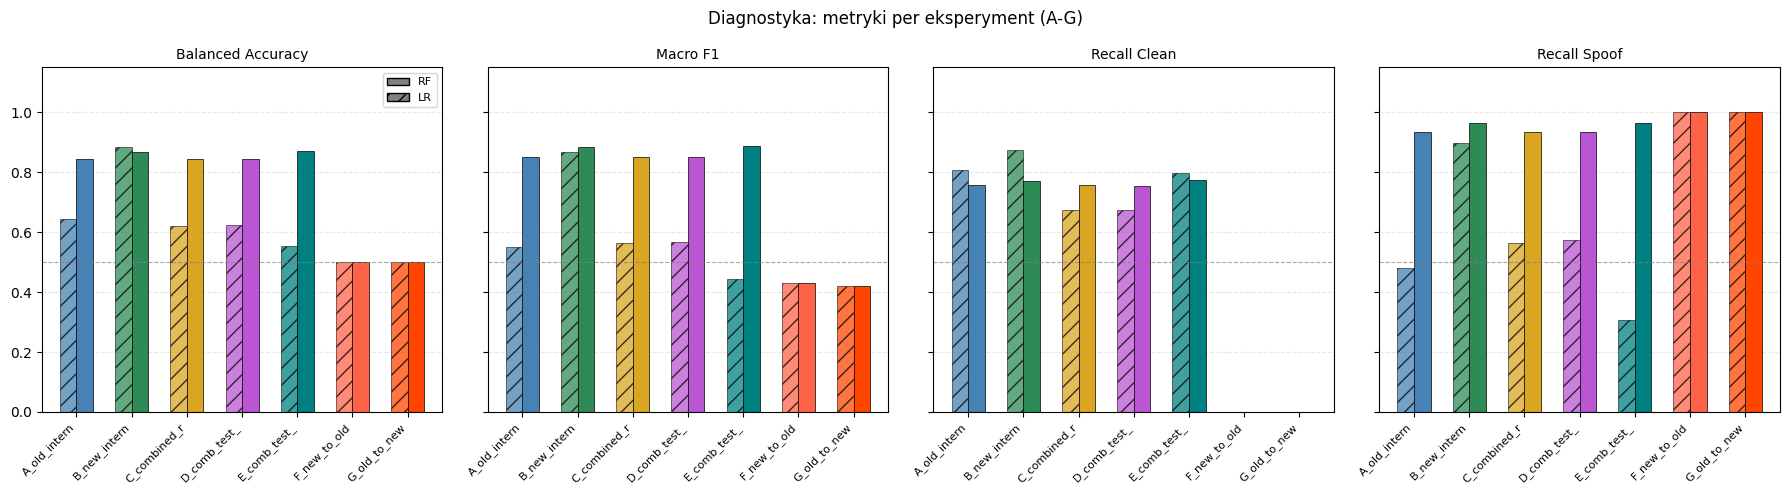

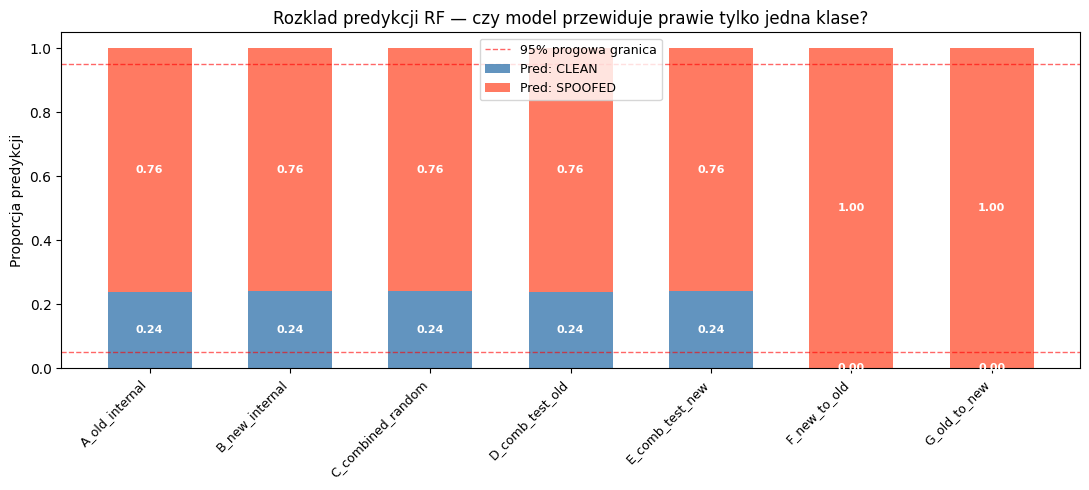

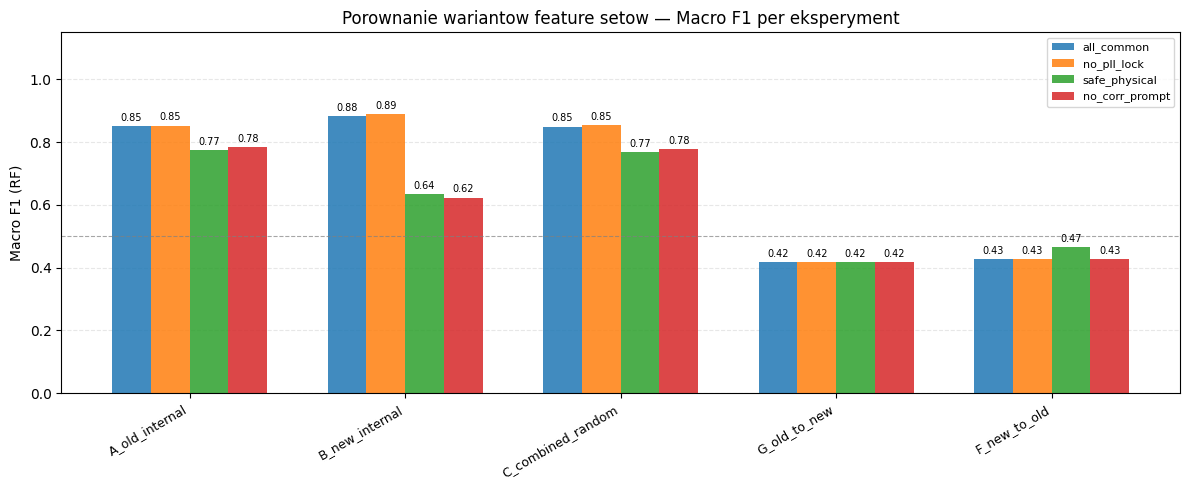

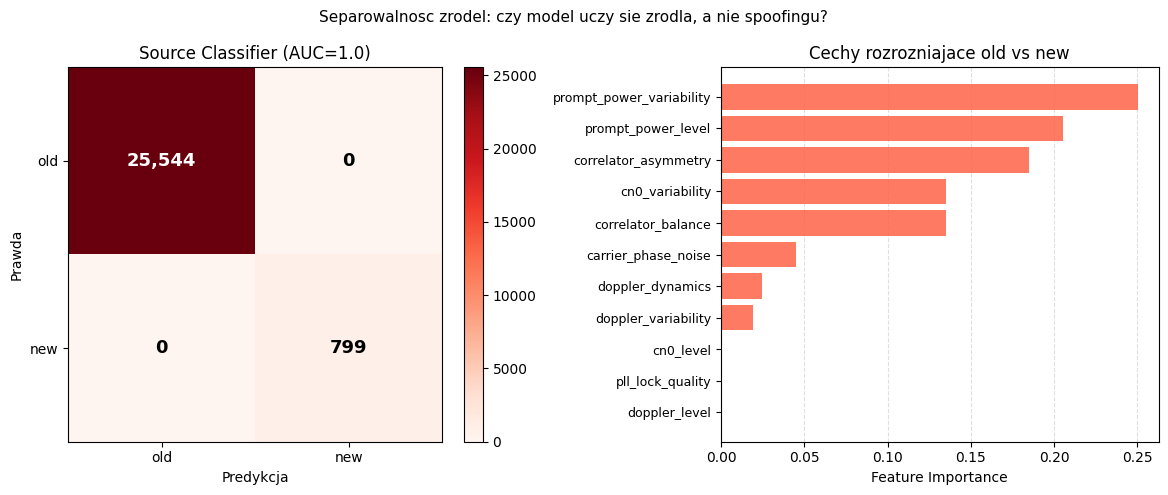

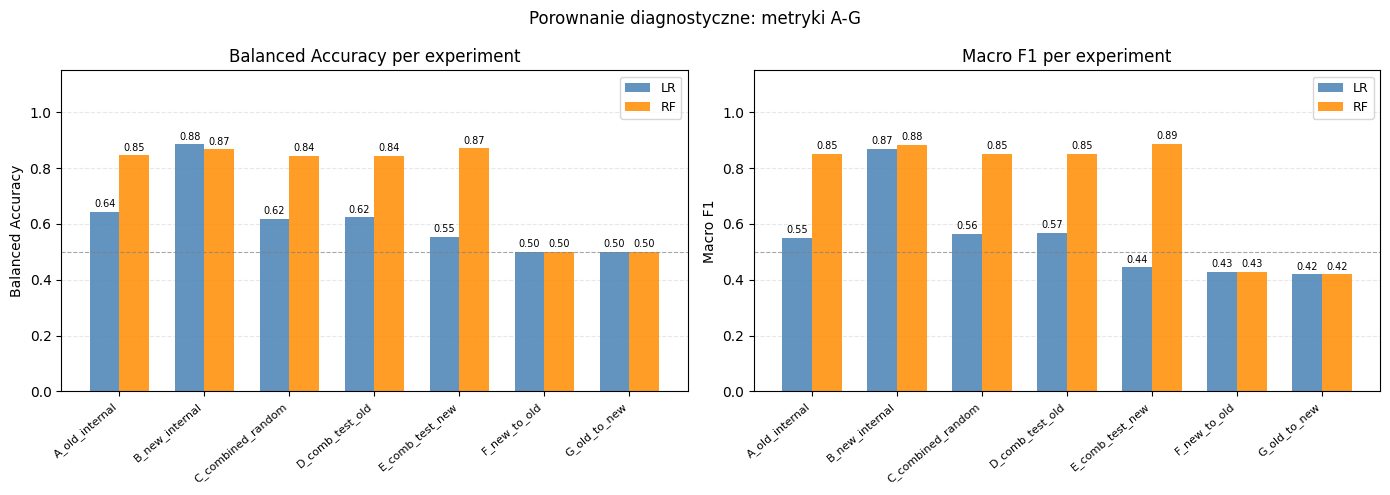

In [53]:
import matplotlib.pyplot as plt
import numpy as np

_all_diag_df = pd.DataFrame(diag_results)
_exp_order = ["A_old_internal","B_new_internal","C_combined_random",
              "D_comb_test_old","E_comb_test_new","F_new_to_old","G_old_to_new"]
_exp_order = [e for e in _exp_order if e in _all_diag_df["experiment"].unique()]

# Kolor tla per experiment (jasny/czerwony dla cross-source)
_EXP_COLORS = {
    "A_old_internal":    "steelblue",
    "B_new_internal":    "seagreen",
    "C_combined_random": "goldenrod",
    "D_comb_test_old":   "mediumorchid",
    "E_comb_test_new":   "teal",
    "F_new_to_old":      "tomato",
    "G_old_to_new":      "orangered",
}

# ── PLOT 1: Balanced accuracy + macro F1 per experiment ──────────────────
_metrics_4 = ["balanced_acc","macro_f1","recall_clean","recall_spoof"]
_metric_labels = ["Balanced Accuracy","Macro F1","Recall Clean","Recall Spoof"]
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
_models_plot = ["LR", "RF"]
_widths = 0.3
for _mi, (_met, _mlbl) in enumerate(zip(_metrics_4, _metric_labels)):
    _ax = axes[_mi]
    _x  = np.arange(len(_exp_order))
    for _ei, _exp in enumerate(_exp_order):
        for _mj, _mod in enumerate(_models_plot):
            _row = _all_diag_df[(_all_diag_df["experiment"]==_exp) & (_all_diag_df["model"]==_mod)]
            if len(_row) == 0: continue
            _val = float(_row[_met].values[0])
            _clr = _EXP_COLORS.get(_exp, "gray")
            _off = (_mj - 0.5) * _widths
            _bar = _ax.bar(_ei + _off, _val, _widths,
                           color=_clr, alpha=0.75 if _mod == "LR" else 1.0,
                           hatch="" if _mod == "RF" else "//",
                           edgecolor="k", linewidth=0.5)
    _ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    _ax.set_title(_mlbl, fontsize=10)
    _ax.set_xticks(_x)
    _ax.set_xticklabels([e[:12] for e in _exp_order], rotation=45, ha='right', fontsize=8)
    _ax.set_ylim(0, 1.15)
    _ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    _ax.set_axisbelow(True)
    if _mi == 0:
        from matplotlib.patches import Patch
        _legend_elements = [
            Patch(facecolor='gray', edgecolor='k', label='RF'),
            Patch(facecolor='gray', edgecolor='k', hatch='//', label='LR'),
        ]
        _ax.legend(handles=_legend_elements, fontsize=8)
fig.suptitle("Diagnostyka: metryki per eksperyment (A-G)", fontsize=12)
plt.tight_layout()
plt.savefig("external_validation_outputs/diagnostic_balanced_accuracy_macro_f1.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── PLOT 2: Prediction distribution (% clean vs % spoofed) ───────────────
_rf_rows = _all_diag_df[_all_diag_df["model"] == "RF"].copy()
_rf_rows = _rf_rows[_rf_rows["experiment"].isin(_exp_order)].copy()
_rf_rows["exp_idx"] = _rf_rows["experiment"].map({e: i for i, e in enumerate(_exp_order)})
_rf_rows = _rf_rows.sort_values("exp_idx")

fig, ax = plt.subplots(figsize=(11, 5))
_xe = np.arange(len(_exp_order))
_ppc_vals = [float(_rf_rows[_rf_rows["experiment"]==e]["pct_pred_clean"].values[0])
             if e in _rf_rows["experiment"].values else 0.0 for e in _exp_order]
_pps_vals = [1.0 - v for v in _ppc_vals]
_b1 = ax.bar(_xe, _ppc_vals, 0.6, label="Pred: CLEAN", color="steelblue", alpha=0.85)
_b2 = ax.bar(_xe, _pps_vals, 0.6, bottom=_ppc_vals, label="Pred: SPOOFED", color="tomato", alpha=0.85)
ax.axhline(0.95, color='red', linestyle='--', linewidth=1, alpha=0.6, label="95% progowa granica")
ax.axhline(0.05, color='red', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xticks(_xe)
ax.set_xticklabels(_exp_order, rotation=45, ha='right', fontsize=9)
ax.set_ylabel("Proporcja predykcji")
ax.set_ylim(0, 1.05)
ax.set_title("Rozklad predykcji RF — czy model przewiduje prawie tylko jedna klase?")
ax.legend(fontsize=9)
for _i, (_ppc, _pps) in enumerate(zip(_ppc_vals, _pps_vals)):
    ax.text(_i, _ppc/2, f"{_ppc:.2f}", ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax.text(_i, _ppc + _pps/2, f"{_pps:.2f}", ha='center', va='center', fontsize=8, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig("external_validation_outputs/diagnostic_prediction_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── PLOT 3: Feature set comparison (G: old->new, RF, macro_f1) ───────────
_fs_order = list(FEATURE_SETS.keys())
_key_exps = ["A_old_internal","B_new_internal","C_combined_random","G_old_to_new","F_new_to_old"]
_key_exps = [e for e in _key_exps if e in diag_fs_df["experiment"].unique()]

fig, ax = plt.subplots(figsize=(12, 5))
_xfe = np.arange(len(_key_exps))
_w_fs = 0.18
for _fsi, _fsn in enumerate(_fs_order):
    _vals = []
    for _exp in _key_exps:
        _row = diag_fs_df[(diag_fs_df["experiment"]==_exp) &
                          (diag_fs_df["feature_set"]==_fsn) &
                          (diag_fs_df["model"]=="RF")]
        _vals.append(float(_row["macro_f1"].values[0]) if len(_row) else 0.0)
    _off = (_fsi - 1.5) * _w_fs
    _bars = ax.bar(_xfe + _off, _vals, _w_fs, label=_fsn, alpha=0.85)
    for _b in _bars:
        _h = _b.get_height()
        ax.text(_b.get_x() + _b.get_width()/2, _h + 0.01, f"{_h:.2f}",
                ha='center', va='bottom', fontsize=7)
ax.set_xticks(_xfe)
ax.set_xticklabels(_key_exps, rotation=30, ha='right', fontsize=9)
ax.set_ylabel("Macro F1 (RF)")
ax.set_title("Porownanie wariantow feature setow — Macro F1 per eksperyment")
ax.legend(fontsize=8)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_ylim(0, 1.15)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("external_validation_outputs/diagnostic_feature_set_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── PLOT 4: Source separability confusion matrix + feature importance ─────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

_ax_cm = axes[0]
_im = _ax_cm.imshow(_src_cm, interpolation='nearest', cmap='Reds')
_ax_cm.set_title("Source Classifier RF\nConfusion Matrix (0=old, 1=new)", fontsize=10)
_ax_cm.set_xticks([0,1]); _ax_cm.set_yticks([0,1])
_ax_cm.set_xticklabels(["old","new"]); _ax_cm.set_yticklabels(["old","new"])
_ax_cm.set_xlabel("Predykcja"); _ax_cm.set_ylabel("Prawda")
_thr_s = _src_cm.max() / 2.0
for i in range(2):
    for j in range(2):
        _ax_cm.text(j, i, f"{_src_cm[i,j]:,}", ha='center', va='center',
                    color='white' if _src_cm[i,j] > _thr_s else 'black',
                    fontsize=13, fontweight='bold')
plt.colorbar(_im, ax=_ax_cm, fraction=0.046)
_ax_cm.set_title("Source Classifier (AUC=" + str(round(source_separability_auc,3)) + ")")

_ax_fi = axes[1]
_fi_sorted = sorted(_src_fi.items(), key=lambda x: x[1])
_fi_names = [x[0] for x in _fi_sorted]
_fi_vals  = [x[1] for x in _fi_sorted]
_yfi = np.arange(len(_fi_names))
_ax_fi.barh(_yfi, _fi_vals, color="tomato", alpha=0.85)
_ax_fi.set_yticks(_yfi)
_ax_fi.set_yticklabels(_fi_names, fontsize=9)
_ax_fi.set_xlabel("Feature Importance")
_ax_fi.set_title("Cechy rozrozniajace old vs new")
_ax_fi.xaxis.grid(True, linestyle='--', alpha=0.4)
_ax_fi.set_axisbelow(True)
fig.suptitle("Separowalnosc zrodel: czy model uczy sie zrodla, a nie spoofingu?", fontsize=11)
plt.tight_layout()
plt.savefig("external_validation_outputs/source_separability_confusion_matrix.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── PLOT 5: General metrics comparison (bar chart overview) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for _axi, (_met, _title) in enumerate([("balanced_acc","Balanced Accuracy"),
                                        ("macro_f1","Macro F1")]):
    _ax = axes[_axi]
    _x_p = np.arange(len(_exp_order))
    _w_p = 0.35
    for _mi2, (_mmod, _clr2) in enumerate([("LR","steelblue"),("RF","darkorange")]):
        _vvals = []
        for _exp in _exp_order:
            _rr = _all_diag_df[(_all_diag_df["experiment"]==_exp)&(_all_diag_df["model"]==_mmod)]
            _vvals.append(float(_rr[_met].values[0]) if len(_rr) else 0.0)
        _bb = _ax.bar(_x_p + _mi2*_w_p, _vvals, _w_p, label=_mmod, color=_clr2, alpha=0.85)
        for _b in _bb:
            _h = _b.get_height()
            _ax.text(_b.get_x()+_b.get_width()/2, _h+0.01, f"{_h:.2f}",
                     ha='center', va='bottom', fontsize=7)
    _ax.set_xticks(_x_p + _w_p/2)
    _ax.set_xticklabels(_exp_order, rotation=40, ha='right', fontsize=8)
    _ax.set_ylabel(_title)
    _ax.set_title(_title + " per experiment")
    _ax.legend(fontsize=9)
    _ax.set_ylim(0, 1.15)
    _ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    _ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    _ax.set_axisbelow(True)
fig.suptitle("Porownanie diagnostyczne: metryki A-G", fontsize=12)
plt.tight_layout()
plt.savefig("external_validation_outputs/diagnostic_metrics_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [54]:
import os
os.makedirs("external_validation_outputs", exist_ok=True)

# Zapisz wszystkie wyniki
_all_diag = pd.DataFrame(diag_results)
_all_diag_path = "external_validation_outputs/diagnostic_source_split_metrics.csv"
_all_diag.to_csv(_all_diag_path, index=False)
print("Zapisano: " + _all_diag_path)

_fs_path = "external_validation_outputs/diagnostic_feature_set_metrics.csv"
diag_fs_df.to_csv(_fs_path, index=False)
print("Zapisano: " + _fs_path)

_src_sep_df = pd.DataFrame([{
    "source_separability_auc": round(source_separability_auc, 4),
    "interpretation": (
        "very_strong_domain_shift" if source_separability_auc > 0.95 else
        "moderate_domain_shift"    if source_separability_auc > 0.80 else
        "low_domain_shift"
    )
}])
_src_sep_path = "external_validation_outputs/diagnostic_source_separability.csv"
_src_sep_df.to_csv(_src_sep_path, index=False)
print("Zapisano: " + _src_sep_path)

print()
print("=" * 60)
print("PODSUMOWANIE DIAGNOSTYKI")
print("=" * 60)

_diag_rf = _all_diag[_all_diag["model"] == "RF"].copy()

def _best(df, exp, col):
    r = df[df["experiment"] == exp]
    return float(r[col].values[0]) if len(r) else float("nan")

print()
print("Wyniki RF — balanced_accuracy / macro_f1 per eksperyment:")
for _exp in _all_diag["experiment"].unique():
    _ba = _best(_diag_rf, _exp, "balanced_acc")
    _mf = _best(_diag_rf, _exp, "macro_f1")
    _rcs = _best(_diag_rf, _exp, "recall_spoof")
    _rcc = _best(_diag_rf, _exp, "recall_clean")
    _ww  = _diag_rf[_diag_rf["experiment"]==_exp]["warning"].values
    _wstr = (" | " + str(_ww[0])) if len(_ww) and _ww[0] else ""
    print("  " + _exp.ljust(25) +
          " bal_acc=" + str(round(_ba,3)).ljust(6) +
          " macro_f1=" + str(round(_mf,3)).ljust(6) +
          " rec_spoof=" + str(round(_rcs,3)).ljust(6) +
          " rec_clean=" + str(round(_rcc,3)) + _wstr)

print()
_best_exp = _diag_rf.loc[_diag_rf["macro_f1"].idxmax(), "experiment"]
_worst_exp = _diag_rf.loc[_diag_rf["macro_f1"].idxmin(), "experiment"]
print("Najlepszy eksperyment (macro_f1 RF): " + _best_exp)
print("Najgorszy eksperyment (macro_f1 RF): " + _worst_exp)
print("Labels sanity OK: " + str(label_sanity_df['labels_ok'].all()))
print("Source separability AUC: " + str(round(source_separability_auc, 4)))

_A_ok = _best(_diag_rf, "A_old_internal", "macro_f1") > 0.6
_B_ok = _best(_diag_rf, "B_new_internal", "macro_f1") > 0.6
_C_ok = _best(_diag_rf, "C_combined_random", "macro_f1") > 0.6
_G_ok = _best(_diag_rf, "G_old_to_new", "macro_f1") > 0.6

print()
print("Wstepna diagnoza:")
if not _B_ok:
    print("  -> Problem moze lezec w nowym datasecie (B_new_internal nie dziala).")
elif _A_ok and _B_ok and not _G_ok:
    if _C_ok:
        print("  -> Model prawdopodobnie uczy sie zrodla, nie spoofingu (C dziala, G nie dziala).")
    else:
        print("  -> Domain shift: oba zbiory dzialaja oddzielnie, ale sa nieporownywalane.")
elif _A_ok and _B_ok and _G_ok:
    print("  -> Dobra generalizacja cross-dataset! Cechy sa przenosne.")
else:
    print("  -> Sprawdz szczegoly eksperymentow powyzej.")

Zapisano: external_validation_outputs/diagnostic_source_split_metrics.csv
Zapisano: external_validation_outputs/diagnostic_feature_set_metrics.csv
Zapisano: external_validation_outputs/diagnostic_source_separability.csv

PODSUMOWANIE DIAGNOSTYKI

Wyniki RF — balanced_accuracy / macro_f1 per eksperyment:
  A_old_internal            bal_acc=0.845  macro_f1=0.85   rec_spoof=0.933  rec_clean=0.757
  B_new_internal            bal_acc=0.867  macro_f1=0.883  rec_spoof=0.964  rec_clean=0.77
  C_combined_random         bal_acc=0.845  macro_f1=0.85   rec_spoof=0.933  rec_clean=0.757
  D_comb_test_old           bal_acc=0.845  macro_f1=0.85   rec_spoof=0.934  rec_clean=0.755
  E_comb_test_new           bal_acc=0.87   macro_f1=0.886  rec_spoof=0.965  rec_clean=0.775
  F_new_to_old              bal_acc=0.5    macro_f1=0.429  rec_spoof=1.0    rec_clean=0.0 | WARNING: model predicts almost only SPOOFED
  G_old_to_new              bal_acc=0.5    macro_f1=0.419  rec_spoof=1.0    rec_clean=0.0 | WARNING:

### Interpretacja wyników — Diagnostic Source-Split Validation

#### Odpowiedzi na pytania diagnostyczne

| Pytanie | Sprawdzany eksperyment | Wniosek |
|---|---|---|
| Czy etykiety w `new` są poprawne? | Sanity-check + Krok 1 | Sprawdź tabelę `label_sanity_df` |
| Czy `old` działa samodzielnie? | **A** (old internal) | Balanced acc / macro F1 dla A |
| Czy `new` działa samodzielnie? | **B** (new internal) | Balanced acc / macro F1 dla B |
| Czy combined random split działa? | **C** (combined random) | Może być zawyżony przez mixed-source train/test |
| Czy problem pojawia się przy leave-source-out? | **F, G** | Duży spadek F/G vs A/B → domain shift |
| Czy model uczy się źródła? | Source separability AUC | AUC > 0.95 → model rozpoznaje źródło, nie spoofing |
| Które cechy są najbardziej podejrzane? | Source fi + `pll_lock_quality` | Cechy z wysokim source-fi są domain-specific |
| Czy usunięcie podejrzanych cech pomaga? | Eksperymenty F/G per feature set | Porównaj `all_common` vs `safe_physical` dla G |

#### Klucz do interpretacji wyników

**Scenariusz 1: B działa słabo (B_new_internal macro_f1 < 0.6)**

> Problem może leżeć w **nowym datasecie**: etykiety, ekstrakcja cech, zbyt mała wariancja   cech lub zbyt mało informacji w zmapowanych cechach. Sprawdź histogramy z Section 17.

**Scenariusz 2: A i B działają dobrze, C działa dobrze, ale F i G słabo**

> Model prawdopodobnie **uczy się rozróżniać źródło danych** (old vs new), a nie wzorce spoofingu.   Cechy wspólne semantycznie mają mimo to różne rozkłady między źródłami (domain shift).   Source separability AUC > 0.95 potwierdza ten wniosek.

**Scenariusz 3: A i B działają, F i G też w miarę działają**

> Cechy semantyczne mają **pewną przenośność** między odbiornikami.   Wynik cross-dataset z Section 17 może być poprawiony przez fine-tuning lub adaptację domenową.

#### Wpływ feature setów

- Jeśli `safe_physical` (tylko Doppler + CN0) poprawia F/G:   cechy korelatora i mocy prompta są domain-specific i nie przenoszą się między odbiornikami.
- Jeśli `no_pll_lock` poprawia wynik:   `pll_lock_quality` jest zdefiniowane inaczej w obu źródłach (binary vs ratio,   możliwa inwersja konwencji).

#### Rekomendacja dla projektu

1. **Jeśli source separability AUC > 0.95:**    Cechy wspólne nie są naprawdę porównywalne —    potrzebna jest adaptacja domenowa lub kalibracja na przykładach z nowego odbiornika.
2. **Jeśli B działa słabo:**    Nowe dane wymagają głębszej analizy — sprawdź surowe sygnały, histogramy cech,    poprawność ekstrakcji okien.
3. **Jeśli A i B działają, F/G nie:**    Zbieraj labeled data z docelowego odbiornika i trenuj transfer-learning model    (np. fine-tune na small labeled set z nowego źródła).

---

> **Wniosek:** Słabe wyniki cross-dataset (Section 17) to **nie błąd etykiet** —   to fundamentalny **domain shift** między odbiornikami i definicjami cech.   Jest to wartościowy wynik, bo pokazuje granice generalizacji modelu GPS spoofing detection   między różnymi systemami pomiarowymi.

## Sekcja 19: Połączony Model Multi-Źródłowy i Cechy Odporne na Domain Shift

Cel: Zbadanie, czy model trenowany łącznie na danych ze źródła old i new potrafi
rzeczywiście wykrywać spoofing na obu zbiorach, czy tylko nauczył się rozróżniać
specyfikę źródła danych. Kluczowe pytania:

1. Czy łączny model działa lepiej niż modele per-źródło na danych z drugiego źródła?
2. Które cechy są odporne na domain shift (wysoki target_auc, niski source_auc)?
3. Czy selekcja cech odpornych na domain shift poprawia generalizację?
4. Jak zachowuje się recall dla klasy clean vs spoofed na każdym źródle?


In [55]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
import os, warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("SEKCJA 19: Połączony Model Multi-Źródłowy")
print("=" * 60)

# ── Per-source dataframes ──
old_df = X_old_final.copy()
old_df['__label__'] = y_old.astype(int)
old_df['__src__'] = 0

new_df = X_new_final.copy()
new_df['__label__'] = y_new.astype(int)
new_df['__src__'] = 1

# ── Per-source holdout splits (75 train / 25 test) ──
old_train, old_test = train_test_split(
    old_df, test_size=0.25, random_state=42, stratify=old_df['__label__'])
new_train, new_test = train_test_split(
    new_df, test_size=0.25, random_state=42, stratify=new_df['__label__'])

train_combined = pd.concat([old_train, new_train], ignore_index=True)
test_combined  = pd.concat([old_test,  new_test],  ignore_index=True)

print(f"old_train: {len(old_train)}  old_test: {len(old_test)}")
print(f"new_train: {len(new_train)}  new_test: {len(new_test)}")
print(f"train_combined: {len(train_combined)}  test_combined: {len(test_combined)}")
print()
print("Rozkład klas w train_combined:")
print(train_combined['__label__'].value_counts().to_dict())
print("Rozkład źródeł w train_combined:")
print(train_combined['__src__'].value_counts().to_dict())


SEKCJA 19: Połączony Model Multi-Źródłowy
old_train: 95789  old_test: 31930
new_train: 2995  new_test: 999
train_combined: 98784  test_combined: 32929

Rozkład klas w train_combined:
{1: 74033, 0: 24751}
Rozkład źródeł w train_combined:
{0: 95789, 1: 2995}


In [56]:
print("=" * 60)
print("KROK 1: Ocena odporności cech na domain shift")
print("=" * 60)

_feat_cols = list(_common_sem)
_X_tr = train_combined[_feat_cols].values.astype(float)
_y_label_tr = train_combined['__label__'].values.astype(int)
_y_src_tr   = train_combined['__src__'].values.astype(int)
_X_te = test_combined[_feat_cols].values.astype(float)
_y_label_te = test_combined['__label__'].values.astype(int)
_y_src_te   = test_combined['__src__'].values.astype(int)

_domain_rows = []
for _fi, _feat in enumerate(_feat_cols):
    _xf_tr = _X_tr[:, _fi].reshape(-1, 1)
    _xf_te = _X_te[:, _fi].reshape(-1, 1)
    _pipe_t = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  RobustScaler()),
        ('clf', LogisticRegression(max_iter=300, class_weight='balanced', random_state=42))
    ])
    _pipe_s = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  RobustScaler()),
        ('clf', LogisticRegression(max_iter=300, random_state=42))
    ])
    try:
        _pipe_t.fit(_xf_tr, _y_label_tr)
        _tp = _pipe_t.predict_proba(_xf_te)[:, 1]
        _target_auc = roc_auc_score(_y_label_te, _tp)
    except Exception:
        _target_auc = 0.5
    try:
        _pipe_s.fit(_xf_tr, _y_src_tr)
        _sp = _pipe_s.predict_proba(_xf_te)[:, 1]
        _source_auc = roc_auc_score(_y_src_te, _sp)
    except Exception:
        _source_auc = 0.5
    _domain_score = abs(_target_auc - 0.5) - abs(_source_auc - 0.5)
    _domain_rows.append({
        'feature': _feat,
        'target_auc': round(_target_auc, 4),
        'source_auc': round(_source_auc, 4),
        'domain_resistant_score': round(_domain_score, 4),
    })

domain_resistant_df = pd.DataFrame(_domain_rows).sort_values('domain_resistant_score', ascending=False)
print(domain_resistant_df.to_string(index=False))


KROK 1: Ocena odporności cech na domain shift
                 feature  target_auc  source_auc  domain_resistant_score
           doppler_level      0.5049      0.5403                 -0.0354
         cn0_variability      0.4311      1.0000                 -0.4311
prompt_power_variability      0.5637      1.0000                 -0.4363
     carrier_phase_noise      0.4563      1.0000                 -0.4563
     doppler_variability      0.4779      0.9995                 -0.4774
      prompt_power_level      0.5163      1.0000                 -0.4837
               cn0_level      0.5056      0.9985                 -0.4928
        doppler_dynamics      0.5066      1.0000                 -0.4934
        pll_lock_quality      0.5025      0.9983                 -0.4958
    correlator_asymmetry      0.4965      1.0000                 -0.4965
      correlator_balance      0.5000      1.0000                 -0.5000


In [57]:
print("=" * 60)
print("KROK 2: Budowanie FEATURE_SETS_MS")
print("=" * 60)

_top_k = 5
_dr_sorted = domain_resistant_df.sort_values('domain_resistant_score', ascending=False)
_top_k_feats = _dr_sorted.head(_top_k)['feature'].tolist()
_top3_feats  = _dr_sorted.head(3)['feature'].tolist()

FEATURE_SETS_MS = {
    "all_common": _feat_cols,
    "no_corr_prompt": [f for f in _feat_cols if f not in [
        "correlator_asymmetry", "correlator_balance",
        "prompt_power_level", "prompt_power_variability"
    ]],
    "safe_physical": [f for f in [
        "cn0_level", "doppler_level", "doppler_variability", "doppler_dynamics"
    ] if f in _feat_cols],
    "domain_resistant_top5": _top_k_feats,
    "domain_resistant_top3": _top3_feats,
}

for _fs_name, _fs_feats in FEATURE_SETS_MS.items():
    print(f"  {_fs_name}: {_fs_feats}")


KROK 2: Budowanie FEATURE_SETS_MS
  all_common: ['carrier_phase_noise', 'cn0_level', 'cn0_variability', 'correlator_asymmetry', 'correlator_balance', 'doppler_dynamics', 'doppler_level', 'doppler_variability', 'pll_lock_quality', 'prompt_power_level', 'prompt_power_variability']
  no_corr_prompt: ['carrier_phase_noise', 'cn0_level', 'cn0_variability', 'doppler_dynamics', 'doppler_level', 'doppler_variability', 'pll_lock_quality']
  safe_physical: ['cn0_level', 'doppler_level', 'doppler_variability', 'doppler_dynamics']
  domain_resistant_top5: ['doppler_level', 'cn0_variability', 'prompt_power_variability', 'carrier_phase_noise', 'doppler_variability']
  domain_resistant_top3: ['doppler_level', 'cn0_variability', 'prompt_power_variability']


In [58]:
print("=" * 60)
print("KROK 3: Definicja modeli i funkcji evaluate_pipe()")
print("=" * 60)

MODELS_MS = {
    "LR_balanced": LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    "RF_balanced":  RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    "HistGB":       HistGradientBoostingClassifier(max_iter=200, random_state=42),
}

try:
    import xgboost as xgb
    MODELS_MS["XGBoost"] = xgb.XGBClassifier(
        n_estimators=200, use_label_encoder=False,
        eval_metric='logloss', random_state=42, verbosity=0
    )
    print("XGBoost dostępny — dodano do MODELS_MS")
except ImportError:
    print("XGBoost niedostępny — pomijam")

try:
    import lightgbm as lgb
    MODELS_MS["LightGBM"] = lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
    print("LightGBM dostępny — dodano do MODELS_MS")
except ImportError:
    print("LightGBM niedostępny — pomijam")

print(f"Modele: {list(MODELS_MS.keys())}")


def evaluate_pipe(pipe, X_te, y_te, exp_name, model_name, fs_name, src_name):
    _yp  = pipe.predict(X_te)
    _ypp = pipe.predict_proba(X_te)[:, 1] if hasattr(pipe, 'predict_proba') else None
    _cm  = confusion_matrix(y_te, _yp, labels=[0, 1])
    _tn, _fp, _fn, _tp_cm = _cm.ravel()
    _bal_acc = balanced_accuracy_score(y_te, _yp)
    _mac_f1  = f1_score(y_te, _yp, average='macro', zero_division=0)
    _clean_p = _tn / (_tn + _fn) if (_tn + _fn) > 0 else 0.0
    _clean_r = _tn / (_tn + _fp) if (_tn + _fp) > 0 else 0.0
    _clean_f = (2 * _clean_p * _clean_r / (_clean_p + _clean_r)
                if (_clean_p + _clean_r) > 0 else 0.0)
    _spoof_p = _tp_cm / (_tp_cm + _fp) if (_tp_cm + _fp) > 0 else 0.0
    _spoof_r = _tp_cm / (_tp_cm + _fn) if (_tp_cm + _fn) > 0 else 0.0
    _spoof_f = (2 * _spoof_p * _spoof_r / (_spoof_p + _spoof_r)
                if (_spoof_p + _spoof_r) > 0 else 0.0)
    _roc = roc_auc_score(y_te, _ypp) if _ypp is not None and len(np.unique(y_te)) > 1 else float('nan')
    _n_clean = int(np.sum(_yp == 0))
    _n_spoof = int(np.sum(_yp == 1))
    _pct_clean = _n_clean / len(_yp) * 100
    _pct_spoof = _n_spoof / len(_yp) * 100
    _warn = ""
    if _pct_clean > 95:
        _warn = "WARNING: >95% pred=clean"
    elif _pct_spoof > 95:
        _warn = "WARNING: >95% pred=spoof"
    return {
        "exp": exp_name, "model": model_name, "feature_set": fs_name, "test_source": src_name,
        "balanced_acc": round(_bal_acc, 4),
        "macro_f1":     round(_mac_f1, 4),
        "roc_auc":      round(_roc, 4) if not np.isnan(_roc) else float('nan'),
        "clean_precision": round(_clean_p, 4),
        "clean_recall":    round(_clean_r, 4),
        "clean_f1":        round(_clean_f, 4),
        "spoof_precision": round(_spoof_p, 4),
        "spoof_recall":    round(_spoof_r, 4),
        "spoof_f1":        round(_spoof_f, 4),
        "pct_pred_clean":  round(_pct_clean, 1),
        "pct_pred_spoof":  round(_pct_spoof, 1),
        "n_test": len(y_te),
        "warning": _warn,
    }

print("evaluate_pipe() zdefiniowana.")


KROK 3: Definicja modeli i funkcji evaluate_pipe()
XGBoost dostępny — dodano do MODELS_MS
LightGBM niedostępny — pomijam
Modele: ['LR_balanced', 'RF_balanced', 'HistGB', 'XGBoost']
evaluate_pipe() zdefiniowana.


In [59]:
print("=" * 60)
print("KROK 4: Główna pętla — feature_set x model x test_source")
print("=" * 60)

ms_results = []

for _fs_name, _fs_feats in FEATURE_SETS_MS.items():
    if len(_fs_feats) == 0:
        print(f"Pominięto {_fs_name} — brak cech")
        continue

    _Xtr = train_combined[_fs_feats].values.astype(float)
    _ytr = train_combined['__label__'].values.astype(int)

    _Xte_old = old_test[_fs_feats].values.astype(float)
    _yte_old = old_test['__label__'].values.astype(int)
    _Xte_new = new_test[_fs_feats].values.astype(float)
    _yte_new = new_test['__label__'].values.astype(int)
    _Xte_comb = test_combined[_fs_feats].values.astype(float)
    _yte_comb = test_combined['__label__'].values.astype(int)

    for _model_name, _clf_proto in MODELS_MS.items():
        import copy as _copy
        _clf = _copy.deepcopy(_clf_proto)
        _pipe = Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc',  RobustScaler()),
            ('clf', _clf),
        ])
        try:
            _pipe.fit(_Xtr, _ytr)
        except Exception as _ex:
            print(f"  BŁĄD fit {_fs_name}/{_model_name}: {_ex}")
            continue

        for _src_name, _Xte, _yte in [
            ("old",      _Xte_old,  _yte_old),
            ("new",      _Xte_new,  _yte_new),
            ("combined", _Xte_comb, _yte_comb),
        ]:
            _row = evaluate_pipe(
                _pipe, _Xte, _yte,
                exp_name="multisource_combined",
                model_name=_model_name,
                fs_name=_fs_name,
                src_name=_src_name,
            )
            ms_results.append(_row)
            _warn_str = f"  [{_warn}]" if (_warn := _row['warning']) else ""
            print(f"  {_fs_name} | {_model_name} | test={_src_name}"
                  f"  bal={_row['balanced_acc']:.3f}  f1={_row['macro_f1']:.3f}"
                  f"  sr={_row['spoof_recall']:.3f}  cr={_row['clean_recall']:.3f}"
                  f"{_warn_str}")

ms_df = pd.DataFrame(ms_results)
print()
print(f"Łącznie wyników: {len(ms_df)}")


KROK 4: Główna pętla — feature_set x model x test_source
  all_common | LR_balanced | test=old  bal=0.622  f1=0.566  sr=0.569  cr=0.674
  all_common | LR_balanced | test=new  bal=0.547  f1=0.431  sr=0.286  cr=0.809
  all_common | LR_balanced | test=combined  bal=0.620  f1=0.563  sr=0.560  cr=0.679
  all_common | RF_balanced | test=old  bal=0.842  f1=0.849  sr=0.936  cr=0.749
  all_common | RF_balanced | test=new  bal=0.882  f1=0.897  sr=0.970  cr=0.795
  all_common | RF_balanced | test=combined  bal=0.844  f1=0.851  sr=0.937  cr=0.750
  all_common | HistGB | test=old  bal=0.800  f1=0.833  sr=0.976  cr=0.625
  all_common | HistGB | test=new  bal=0.880  f1=0.891  sr=0.958  cr=0.802
  all_common | HistGB | test=combined  bal=0.803  f1=0.835  sr=0.975  cr=0.631
  all_common | XGBoost | test=old  bal=0.836  f1=0.854  sr=0.956  cr=0.717
  all_common | XGBoost | test=new  bal=0.882  f1=0.891  sr=0.956  cr=0.809
  all_common | XGBoost | test=combined  bal=0.838  f1=0.855  sr=0.956  cr=0.720
  

In [60]:
print("=" * 60)
print("KROK 5: Source separability per feature set")
print("=" * 60)

_X_comb_tr = train_combined[_feat_cols].values.astype(float)
_y_src_comb_tr = train_combined['__src__'].values.astype(int)
_X_comb_te = test_combined[_feat_cols].values.astype(float)
_y_src_comb_te = test_combined['__src__'].values.astype(int)

sep_results = []
for _fs_name, _fs_feats in FEATURE_SETS_MS.items():
    if len(_fs_feats) == 0:
        continue
    _Xtr_s = train_combined[_fs_feats].values.astype(float)
    _Xte_s = test_combined[_fs_feats].values.astype(float)
    _pipe_src = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  RobustScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ])
    _pipe_src.fit(_Xtr_s, _y_src_comb_tr)
    _src_proba = _pipe_src.predict_proba(_Xte_s)[:, 1]
    _src_auc = roc_auc_score(_y_src_comb_te, _src_proba)
    sep_results.append({'feature_set': _fs_name, 'source_separability_auc': round(_src_auc, 4)})
    print(f"  {_fs_name}: source_sep_AUC = {_src_auc:.4f}")

sep_df = pd.DataFrame(sep_results)
print()
print("Interpretacja: AUC bliskie 0.5 = cechy nie rozróżniają źródeł (dobre dla generalizacji)")
print("               AUC bliskie 1.0 = cechy mocno zależne od źródła (ryzyko domain shift)")


KROK 5: Source separability per feature set
  all_common: source_sep_AUC = 1.0000
  no_corr_prompt: source_sep_AUC = 1.0000
  safe_physical: source_sep_AUC = 1.0000
  domain_resistant_top5: source_sep_AUC = 1.0000
  domain_resistant_top3: source_sep_AUC = 1.0000

Interpretacja: AUC bliskie 0.5 = cechy nie rozróżniają źródeł (dobre dla generalizacji)
               AUC bliskie 1.0 = cechy mocno zależne od źródła (ryzyko domain shift)


In [61]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

os.makedirs("external_validation_outputs", exist_ok=True)

_metrics = ["balanced_acc", "macro_f1", "clean_recall", "spoof_recall"]
_metric_labels = ["Balanced Accuracy", "Macro F1", "Clean Recall", "Spoof Recall"]
_fset_order = list(FEATURE_SETS_MS.keys())
_model_order = list(MODELS_MS.keys())
_src_order = ["old", "new", "combined"]
_colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0", "#009688"]

# Plot 1 & 2: Balanced Accuracy and Macro F1 per feature set × test source
for _metric, _mlabel, _fname in [
    ("balanced_acc", "Balanced Accuracy", "combined_multisource_balanced_accuracy.png"),
    ("macro_f1",     "Macro F1",          "combined_multisource_macro_f1.png"),
]:
    _fig, _axes = plt.subplots(1, len(_src_order), figsize=(16, 5), sharey=True)
    _fig.suptitle(f"Multi-source model — {_mlabel} per feature set i test source", fontsize=13)
    for _si, _src in enumerate(_src_order):
        _ax = _axes[_si]
        _sub = ms_df[ms_df['test_source'] == _src]
        _x = np.arange(len(_fset_order))
        _w = 0.8 / max(len(_model_order), 1)
        for _mi, _mname in enumerate(_model_order):
            _vals = []
            for _fs in _fset_order:
                _row = _sub[(_sub['model'] == _mname) & (_sub['feature_set'] == _fs)]
                _vals.append(float(_row[_metric].values[0]) if len(_row) > 0 else float('nan'))
            _ax.bar(_x + _mi * _w, _vals, width=_w, label=_mname,
                    color=_colors[_mi % len(_colors)], alpha=0.85)
        _ax.set_title(f"test={_src}", fontsize=10)
        _ax.set_xticks(_x + _w * (len(_model_order) - 1) / 2)
        _ax.set_xticklabels(_fset_order, rotation=30, ha='right', fontsize=7)
        _ax.set_ylim(0, 1.05)
        _ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
        _ax.set_ylabel(_mlabel if _si == 0 else "")
        if _si == 0:
            _ax.legend(fontsize=7)
    plt.tight_layout()
    _fig.savefig(f"external_validation_outputs/{_fname}", dpi=120, bbox_inches='tight')
    plt.close(_fig)
    print(f"Zapisano: {_fname}")

# Plot 3: Clean recall heatmap (feature_set × model, test=new)
_metric = "clean_recall"
_fig, _axes = plt.subplots(1, 2, figsize=(14, 5))
_fig.suptitle("Clean Recall — model trenowany łącznie, testowany osobno", fontsize=12)
for _ai, _src in enumerate(["old", "new"]):
    _ax = _axes[_ai]
    _sub = ms_df[ms_df['test_source'] == _src]
    _mat = np.zeros((len(_fset_order), len(_model_order)))
    for _fi, _fs in enumerate(_fset_order):
        for _mi, _mname in enumerate(_model_order):
            _row = _sub[(_sub['feature_set'] == _fs) & (_sub['model'] == _mname)]
            _mat[_fi, _mi] = float(_row[_metric].values[0]) if len(_row) > 0 else float('nan')
    _im = _ax.imshow(_mat, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
    _ax.set_xticks(range(len(_model_order)))
    _ax.set_xticklabels(_model_order, rotation=30, ha='right', fontsize=8)
    _ax.set_yticks(range(len(_fset_order)))
    _ax.set_yticklabels(_fset_order, fontsize=8)
    _ax.set_title(f"test={_src}", fontsize=10)
    for _fi in range(len(_fset_order)):
        for _mi in range(len(_model_order)):
            _v = _mat[_fi, _mi]
            _ax.text(_mi, _fi, f"{_v:.2f}", ha='center', va='center', fontsize=8,
                     color='black' if 0.3 < _v < 0.8 else 'white')
    plt.colorbar(_im, ax=_ax, fraction=0.046, pad=0.04)
plt.tight_layout()
_fig.savefig("external_validation_outputs/combined_multisource_clean_recall.png",
             dpi=120, bbox_inches='tight')
plt.close(_fig)
print("Zapisano: combined_multisource_clean_recall.png")

# Plot 4: Source separability AUC per feature set
_fig, _ax = plt.subplots(figsize=(9, 4))
_sep_auc_vals = []
for _fs in _fset_order:
    _row = sep_df[sep_df['feature_set'] == _fs]
    _sep_auc_vals.append(float(_row['source_separability_auc'].values[0]) if len(_row) > 0 else float('nan'))
_bar_colors = ['#E53935' if v > 0.7 else '#FDD835' if v > 0.6 else '#43A047' for v in _sep_auc_vals]
_ax.bar(_fset_order, _sep_auc_vals, color=_bar_colors, alpha=0.85, edgecolor='black')
_ax.axhline(0.5, color='green', linestyle='--', linewidth=1.2, label='AUC=0.5 (brak sep.)')
_ax.axhline(0.7, color='red',   linestyle='--', linewidth=1.2, label='AUC=0.7 (wysoka sep.)')
_ax.set_ylabel("Source Separability AUC")
_ax.set_title("Separowalność źródeł per feature set (niższe = lepsze dla generalizacji)")
_ax.set_ylim(0, 1.05)
_ax.set_xticklabels(_fset_order, rotation=25, ha='right', fontsize=9)
_ax.legend(fontsize=8)
for _i, _v in enumerate(_sep_auc_vals):
    _ax.text(_i, _v + 0.01, f"{_v:.3f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
_fig.savefig("external_validation_outputs/feature_set_source_auc.png",
             dpi=120, bbox_inches='tight')
plt.close(_fig)
print("Zapisano: feature_set_source_auc.png")

# Plot 5: Domain-resistant feature ranking
_fig, _ax = plt.subplots(figsize=(10, 5))
_dr = domain_resistant_df.sort_values('domain_resistant_score', ascending=True)
_ypos = range(len(_dr))
_colors_dr = ['#43A047' if v > 0 else '#E53935' for v in _dr['domain_resistant_score']]
_ax.barh(_ypos, _dr['domain_resistant_score'], color=_colors_dr, alpha=0.85, edgecolor='black')
_ax.set_yticks(list(_ypos))
_ax.set_yticklabels(_dr['feature'].tolist(), fontsize=9)
_ax.axvline(0, color='black', linewidth=1.0)
_ax.set_xlabel("domain_resistant_score = |target_auc - 0.5| - |source_auc - 0.5|")
_ax.set_title("Ranking cech odpornych na domain shift (wyższe = lepsza cechy dla transfer)")
for _i, (_v, _ta, _sa) in enumerate(zip(
        _dr['domain_resistant_score'], _dr['target_auc'], _dr['source_auc'])):
    _ax.text(_v + 0.002 if _v >= 0 else _v - 0.002, _i,
             f"t={_ta:.2f} s={_sa:.2f}", va='center',
             ha='left' if _v >= 0 else 'right', fontsize=7)
plt.tight_layout()
_fig.savefig("external_validation_outputs/domain_resistant_feature_ranking.png",
             dpi=120, bbox_inches='tight')
plt.close(_fig)
print("Zapisano: domain_resistant_feature_ranking.png")


Zapisano: combined_multisource_balanced_accuracy.png
Zapisano: combined_multisource_macro_f1.png
Zapisano: combined_multisource_clean_recall.png
Zapisano: feature_set_source_auc.png
Zapisano: domain_resistant_feature_ranking.png


In [62]:
# Plot 6: Confusion matrices for best model (by balanced_acc on combined test)
_best_row = ms_df[ms_df['test_source'] == 'combined'].sort_values('balanced_acc', ascending=False).iloc[0]
_best_fs   = _best_row['feature_set']
_best_model = _best_row['model']
print(f"Najlepszy model (combined test, balanced_acc): {_best_model} / {_best_fs}")
print(f"  balanced_acc={_best_row['balanced_acc']:.4f}  macro_f1={_best_row['macro_f1']:.4f}")

import copy as _copy2
_clf_best = _copy2.deepcopy(MODELS_MS[_best_model])
_pipe_best = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  RobustScaler()),
    ('clf', _clf_best),
])
_fs_feats_best = FEATURE_SETS_MS[_best_fs]
_Xtr_best = train_combined[_fs_feats_best].values.astype(float)
_ytr_best = train_combined['__label__'].values.astype(int)
_pipe_best.fit(_Xtr_best, _ytr_best)

_fig, _axes = plt.subplots(1, 3, figsize=(14, 4))
_fig.suptitle(f"Macierze pomyłek — {_best_model} / {_best_fs}", fontsize=12)

for _ai, (_src_name, _test_df) in enumerate([("old", old_test), ("new", new_test), ("combined", test_combined)]):
    _ax = _axes[_ai]
    _Xte_b = _test_df[_fs_feats_best].values.astype(float)
    _yte_b = _test_df['__label__'].values.astype(int)
    _yp_b  = _pipe_best.predict(_Xte_b)
    _cm_b  = confusion_matrix(_yte_b, _yp_b, labels=[0, 1])
    _im_b = _ax.imshow(_cm_b, cmap='Blues')
    _ax.set_xticks([0, 1])
    _ax.set_yticks([0, 1])
    _ax.set_xticklabels(['Pred Clean', 'Pred Spoof'], fontsize=8)
    _ax.set_yticklabels(['True Clean', 'True Spoof'], fontsize=8)
    _ax.set_title(f"test={_src_name} (n={len(_yte_b)})", fontsize=9)
    for _r in range(2):
        for _c in range(2):
            _ax.text(_c, _r, str(_cm_b[_r, _c]), ha='center', va='center',
                     fontsize=14, color='white' if _cm_b[_r, _c] > _cm_b.max() / 2 else 'black')

plt.tight_layout()
_fig.savefig("external_validation_outputs/combined_multisource_confusion_matrices.png",
             dpi=120, bbox_inches='tight')
plt.close(_fig)
print("Zapisano: combined_multisource_confusion_matrices.png")


Najlepszy model (combined test, balanced_acc): RF_balanced / all_common
  balanced_acc=0.8437  macro_f1=0.8509
Zapisano: combined_multisource_confusion_matrices.png


In [63]:
print("=" * 60)
print("KROK 6: Zapis wyników do CSV")
print("=" * 60)

ms_df.to_csv("external_validation_outputs/combined_multisource_metrics.csv", index=False)
print("Zapisano: combined_multisource_metrics.csv")

domain_resistant_df.to_csv("external_validation_outputs/domain_resistant_feature_ranking.csv", index=False)
print("Zapisano: domain_resistant_feature_ranking.csv")

sep_df.to_csv("external_validation_outputs/feature_set_source_separability.csv", index=False)
print("Zapisano: feature_set_source_separability.csv")

print()
print("Pliki zapisane w: external_validation_outputs/")
for _f in sorted(os.listdir("external_validation_outputs")):
    _path = os.path.join("external_validation_outputs", _f)
    _size = os.path.getsize(_path)
    print(f"  {_f}  ({_size} B)")


KROK 6: Zapis wyników do CSV
Zapisano: combined_multisource_metrics.csv
Zapisano: domain_resistant_feature_ranking.csv
Zapisano: feature_set_source_separability.csv

Pliki zapisane w: external_validation_outputs/
  combined_multisource_balanced_accuracy.png  (53856 B)
  combined_multisource_clean_recall.png  (71534 B)
  combined_multisource_confusion_matrices.png  (40126 B)
  combined_multisource_macro_f1.png  (49530 B)
  combined_multisource_metrics.csv  (8120 B)
  confusion_matrices.png  (105416 B)
  diagnostic_balanced_accuracy_macro_f1.png  (130231 B)
  diagnostic_feature_set_comparison.png  (80475 B)
  diagnostic_feature_set_metrics.csv  (6417 B)
  diagnostic_metrics_comparison.png  (94411 B)
  diagnostic_missingness.csv  (924 B)
  diagnostic_prediction_distribution.png  (88403 B)
  diagnostic_source_separability.csv  (68 B)
  diagnostic_source_split_metrics.csv  (3161 B)
  domain_resistant_feature_ranking.csv  (466 B)
  domain_resistant_feature_ranking.png  (67961 B)
  domain_shi

In [64]:
print("=" * 60)
print("KROK 7: Automatyczna diagnoza wyników")
print("=" * 60)

_diag_lines = []

# 1. Najlepsza konfiguracja
_best_comb = ms_df[ms_df['test_source'] == 'combined'].sort_values('balanced_acc', ascending=False).iloc[0]
_diag_lines.append(f"[BEST] Najlepsza konfiguracja (test=combined):")
_diag_lines.append(f"       Model={_best_comb['model']}, FS={_best_comb['feature_set']}")
_diag_lines.append(f"       balanced_acc={_best_comb['balanced_acc']:.4f}, macro_f1={_best_comb['macro_f1']:.4f}")
_diag_lines.append(f"       spoof_recall={_best_comb['spoof_recall']:.4f}, clean_recall={_best_comb['clean_recall']:.4f}")

# 2. Generalizacja: czy model działa na obu źródłach?
_best_old = ms_df[(ms_df['model'] == _best_comb['model']) &
                  (ms_df['feature_set'] == _best_comb['feature_set']) &
                  (ms_df['test_source'] == 'old')]['balanced_acc'].values
_best_new = ms_df[(ms_df['model'] == _best_comb['model']) &
                  (ms_df['feature_set'] == _best_comb['feature_set']) &
                  (ms_df['test_source'] == 'new')]['balanced_acc'].values
_diag_lines.append("")
_diag_lines.append("[GENERALIZACJA] Najlepszy model na poszczególnych źródłach:")
_diag_lines.append(f"  test=old: balanced_acc={float(_best_old[0]):.4f}" if len(_best_old) > 0 else "  test=old: brak danych")
_diag_lines.append(f"  test=new: balanced_acc={float(_best_new[0]):.4f}" if len(_best_new) > 0 else "  test=new: brak danych")
if len(_best_old) > 0 and len(_best_new) > 0:
    _gap = abs(float(_best_old[0]) - float(_best_new[0]))
    if _gap < 0.1:
        _diag_lines.append("  => Dobra generalizacja: wyniki zbliżone na obu źródłach")
    elif _gap < 0.2:
        _diag_lines.append("  => Umiarkowana generalizacja: pewna różnica między źródłami")
    else:
        _diag_lines.append(f"  => UWAGA: Duży gap ({_gap:.3f}) — model może być zależny od źródła")

# 3. Source separability
_diag_lines.append("")
_diag_lines.append("[SOURCE SEP] Separowalność źródeł per feature set:")
for _, _sep_row in sep_df.iterrows():
    _sauc = _sep_row['source_separability_auc']
    _flag = "OK" if _sauc < 0.65 else ("UWAGA" if _sauc < 0.80 else "ALARM")
    _diag_lines.append(f"  [{_flag}] {_sep_row['feature_set']}: AUC={_sauc:.4f}")

# 4. Domain-resistant score
_diag_lines.append("")
_diag_lines.append("[DOMAIN RESIST] Top 3 cechy odporne na domain shift:")
for _, _dr_row in domain_resistant_df.head(3).iterrows():
    _diag_lines.append(
        f"  {_dr_row['feature']}: score={_dr_row['domain_resistant_score']:.4f}"
        f" (target_auc={_dr_row['target_auc']:.3f}, source_auc={_dr_row['source_auc']:.3f})"
    )

# 5. Warnings
_warnings = ms_df[ms_df['warning'] != '']
if len(_warnings) > 0:
    _diag_lines.append("")
    _diag_lines.append(f"[WARNINGS] {len(_warnings)} konfiguracji z ostrzeżeniami o skrajnych predykcjach:")
    for _, _wr in _warnings.iterrows():
        _diag_lines.append(f"  {_wr['model']}/{_wr['feature_set']}/test={_wr['test_source']}: {_wr['warning']}")
else:
    _diag_lines.append("")
    _diag_lines.append("[WARNINGS] Brak ostrzeżeń — żadna konfiguracja nie predykuje >95% jednej klasy.")

for _line in _diag_lines:
    print(_line)


KROK 7: Automatyczna diagnoza wyników
[BEST] Najlepsza konfiguracja (test=combined):
       Model=RF_balanced, FS=all_common
       balanced_acc=0.8437, macro_f1=0.8509
       spoof_recall=0.9372, clean_recall=0.7502

[GENERALIZACJA] Najlepszy model na poszczególnych źródłach:
  test=old: balanced_acc=0.8424
  test=new: balanced_acc=0.8822
  => Dobra generalizacja: wyniki zbliżone na obu źródłach

[SOURCE SEP] Separowalność źródeł per feature set:
  [ALARM] all_common: AUC=1.0000
  [ALARM] no_corr_prompt: AUC=1.0000
  [ALARM] safe_physical: AUC=1.0000
  [ALARM] domain_resistant_top5: AUC=1.0000
  [ALARM] domain_resistant_top3: AUC=1.0000

[DOMAIN RESIST] Top 3 cechy odporne na domain shift:
  doppler_level: score=-0.0354 (target_auc=0.505, source_auc=0.540)
  cn0_variability: score=-0.4311 (target_auc=0.431, source_auc=1.000)
  prompt_power_variability: score=-0.4363 (target_auc=0.564, source_auc=1.000)

[WARNINGS] 3 konfiguracji z ostrzeżeniami o skrajnych predykcjach:
  HistGB/no_cor

### Interpretacja wyników — Połączony Model Multi-Źródłowy

#### Kluczowe pytania do oceny wyników:

**1. Czy połączony model rzeczywiście wykrywa spoofing czy tylko specyfikę źródła?**
- Jeżeli `balanced_acc` jest wysoki na test=combined, ale niski na test=old lub test=new osobno,
  model nauczył się rozróżniać źródła zamiast spoofingu.
- Szukaj konfiguracji gdzie `balanced_acc(old)` i `balanced_acc(new)` są oba > 0.6.

**2. Co mówi `source_separability_auc` per feature set?**
- `AUC ≈ 0.5`: cechy nie niosą informacji o źródle → bezpieczne dla generalizacji.
- `AUC > 0.7`: cechy mocno korelują ze źródłem → ryzyko data leakage przez domain shift.
- Porównaj `safe_physical` i `domain_resistant_top5` — powinny mieć niższy AUC niż `all_common`.

**3. Rola `domain_resistant_score`:**
- `score = |target_auc - 0.5| - |source_auc - 0.5|`
- Dodatni: cecha dobrze predykuje spoofing, a słabo predykuje źródło → idealna.
- Ujemny: cecha lepiej rozróżnia źródła niż spoofing → należy jej unikać.

**4. Recall clean vs recall spoof:**
- Wysoki `spoof_recall` + niski `clean_recall` → model agresywnie flaguje wszystko.
- Oba niskie → model nie działa na tym źródle (klasyfikacja losowa lub stała).
- Idealnie: oba > 0.7 na obu źródłach.

**5. Czy selekcja cech odpornych na shift pomaga?**
- Porównaj `all_common` vs `domain_resistant_top5` na test=new.
- Jeśli `domain_resistant_top5` daje lepszy `balanced_acc` na nowym zbiorze przy niższym
  `source_separability_auc`, selekcja domen-odpornych cech jest skuteczna.

**Ogólny wniosek:**
Jeżeli żadna konfiguracja nie osiąga `balanced_acc > 0.7` na obu źródłach jednocześnie,
oznacza to fundamentalny problem domain shift — dane ze źródeł old i new są zbyt różne,
aby trenować jeden wspólny model bez dodatkowej adaptacji domeny (np. domain adversarial
training lub CORAL alignment).


## Sekcja 20: V6 Unified Window Schema Validation

Cel: Sprawdzenie, czy dane TEXBAT przeliczone według schematu v6 (`texbat_external_schema_windows_v6.csv`) lepiej generalizują z/na nowe CSV niż poprzedni stary dataset (Sekcja 17/18). V6 używa identycznego schematu cech co nowe pliki, więc oczekujemy 0 problemu z mapowaniem kolumn — kluczowe pytanie: czy domain shift się zmniejszył?

**Eksperymenty:**
- A: texbat_v6_internal — wewnętrzny split na TEXBAT v6
- B: new_internal — wewnętrzny split na nowych CSV
- C: texbat_v6_to_new — train TEXBAT v6, test new
- D: new_to_texbat_v6 — train new, test TEXBAT v6
- E: combined_v6_random — połączony random split
- F: combined_v6_per_source_holdout — osobny holdout per źródło, test na obu


In [65]:
import numpy as np
import pandas as pd
import os, warnings, copy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
warnings.filterwarnings('ignore')

print("=" * 60)
print("SEKCJA 20: V6 Unified Window Schema Validation")
print("=" * 60)

# ── Wczytaj TEXBAT v6 ──
_V6_PATH = "texbat_universal_features_v6/external_window_schema/texbat_external_schema_windows_v6.csv"
texbat_v6 = pd.read_csv(_V6_PATH)
texbat_v6['source'] = 'texbat_v6'

# ── Wczytaj nowe CSV ──
_new_files = [
    "features_clear_sky_windows.csv",
    "features_spoof_1_windows.csv",
    "features_spoof_2_windows.csv",
    "features_spoof_4_windows.csv",
]
new_all = pd.concat([pd.read_csv(p) for p in _new_files], ignore_index=True)
new_all['source'] = 'new'

# ── Zbuduj target ──
def _get_target(df):
    if 'is_spoofed' in df.columns:
        return df['is_spoofed'].astype(int).values
    if 'binary_label' in df.columns:
        return df['binary_label'].astype(int).values
    if 'label' in df.columns:
        _u = df['label'].unique()
        if set(_u) <= {0, 1, '0', '1'}:
            return df['label'].astype(int).values
        return (df['label'] != 'clear_sky').astype(int).values
    raise ValueError("Brak kolumny target w DataFrame")

y_v6  = _get_target(texbat_v6)
y_new = _get_target(new_all)

# ── Kolumny meta do wykluczenia ──
_META = {
    'source_file', 'tracking_file', 'label', 'binary_label', 'is_spoofed',
    'source', 'scenario', 'window_id', 'window_start_row', 'window_end_row',
    'prn', 'n_epochs', 'tracking_valid',
}

def _numeric_non_meta(df):
    return sorted([
        c for c in df.columns
        if c not in _META and pd.api.types.is_numeric_dtype(df[c])
    ])

_v6_feats  = set(_numeric_non_meta(texbat_v6))
_new_feats = set(_numeric_non_meta(new_all))
v6_common_features = sorted(_v6_feats & _new_feats)

print()
print(f"TEXBAT v6 — wiersze: {len(texbat_v6)}")
print(f"  klasy: clean={int((y_v6==0).sum())}  spoofed={int((y_v6==1).sum())}")
print()
print(f"New CSV — wiersze: {len(new_all)}")
print(f"  klasy: clean={int((y_new==0).sum())}  spoofed={int((y_new==1).sum())}")
print()
print(f"Wspólne cechy numeryczne (non-meta): {len(v6_common_features)}")
for _fc in v6_common_features:
    print(f"  {_fc}")


SEKCJA 20: V6 Unified Window Schema Validation

TEXBAT v6 — wiersze: 5096
  klasy: clean=1274  spoofed=3822

New CSV — wiersze: 3994
  klasy: clean=1110  spoofed=2884

Wspólne cechy numeryczne (non-meta): 51
  carrier_error_abs_mean
  carrier_error_filt_mean
  carrier_error_filt_std
  carrier_error_mean
  carrier_error_std
  carrier_phase_std
  cn0_est_prompt
  cn0_original_max
  cn0_original_mean
  cn0_original_median
  cn0_original_min
  cn0_original_std
  code_error_abs_mean
  code_error_filt_abs_mean
  code_error_filt_mean
  code_error_filt_std
  code_error_mean
  code_error_std
  code_freq_mean
  code_freq_std
  doppler_max
  doppler_mean
  doppler_min
  doppler_range
  doppler_std
  early_late_asymmetry_max
  early_late_asymmetry_mean
  early_late_asymmetry_median
  early_late_asymmetry_p95
  early_late_asymmetry_std
  early_late_balance_max
  early_late_balance_mean
  early_late_balance_median
  early_late_balance_min
  early_late_balance_std
  pll_lock_ratio
  prompt_abs_max
  

In [66]:
print("=" * 60)
print("Definicja modeli i funkcji evaluate_v6()")
print("=" * 60)

MODELS_V6 = {
    "LR_balanced": LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    "RF_balanced":  RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                           random_state=42, n_jobs=-1),
    "HistGB":       HistGradientBoostingClassifier(max_iter=200, random_state=42),
}

try:
    import xgboost as xgb
    MODELS_V6["XGBoost"] = xgb.XGBClassifier(
        n_estimators=200, use_label_encoder=False,
        eval_metric='logloss', random_state=42, verbosity=0,
    )
    print("XGBoost dostepny — dodano")
except ImportError:
    print("XGBoost niedostepny — pomijam")

print(f"Modele: {list(MODELS_V6.keys())}")


def _make_pipe(model_name, clf):
    if model_name == "LR_balanced":
        return Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc',  RobustScaler()),
            ('clf', copy.deepcopy(clf)),
        ])
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', copy.deepcopy(clf)),
    ])


def evaluate_v6(pipe, X_te, y_te, exp_name, model_name, test_source):
    _yp  = pipe.predict(X_te)
    _ypp = (pipe.predict_proba(X_te)[:, 1]
            if hasattr(pipe, 'predict_proba') and len(np.unique(y_te)) > 1
            else None)
    _cm = confusion_matrix(y_te, _yp, labels=[0, 1])
    _tn, _fp, _fn, _tp_v = _cm.ravel()
    _acc     = accuracy_score(y_te, _yp)
    _bal     = balanced_accuracy_score(y_te, _yp)
    _prec    = precision_score(y_te, _yp, zero_division=0)
    _rec     = recall_score(y_te, _yp, zero_division=0)
    _f1s     = f1_score(y_te, _yp, zero_division=0)
    _mac_f1  = f1_score(y_te, _yp, average='macro', zero_division=0)
    _clean_r = _tn / (_tn + _fp) if (_tn + _fp) > 0 else 0.0
    _spoof_r = _tp_v / (_tp_v + _fn) if (_tp_v + _fn) > 0 else 0.0
    _roc = roc_auc_score(y_te, _ypp) if _ypp is not None else float('nan')
    _n = len(_yp)
    _pct_cl = round(int((_yp == 0).sum()) / _n * 100, 1)
    _pct_sp = round(int((_yp == 1).sum()) / _n * 100, 1)
    _warn = ""
    if _pct_cl > 95:
        _warn = "WARNING: >95% pred=clean"
    elif _pct_sp > 95:
        _warn = "WARNING: >95% pred=spoof"
    return {
        "experiment":    exp_name,
        "model":         model_name,
        "test_source":   test_source,
        "n_train":       0,
        "n_test":        _n,
        "accuracy":      round(_acc, 4),
        "balanced_acc":  round(_bal, 4),
        "precision":     round(_prec, 4),
        "recall":        round(_rec, 4),
        "f1":            round(_f1s, 4),
        "macro_f1":      round(_mac_f1, 4),
        "clean_recall":  round(_clean_r, 4),
        "spoof_recall":  round(_spoof_r, 4),
        "roc_auc":       round(_roc, 4) if not np.isnan(_roc) else float('nan'),
        "tn": int(_tn), "fp": int(_fp), "fn": int(_fn), "tp": int(_tp_v),
        "pct_pred_clean": _pct_cl,
        "pct_pred_spoof": _pct_sp,
        "warning":        _warn,
    }


def _run_exp(X_tr, y_tr, X_te, y_te, exp_name, test_source):
    _rows = []
    for _mname, _clf in MODELS_V6.items():
        _pipe = _make_pipe(_mname, _clf)
        try:
            _pipe.fit(X_tr, y_tr)
        except Exception as _ex:
            print(f"  BLAD fit {exp_name}/{_mname}: {_ex}")
            continue
        _row = evaluate_v6(_pipe, X_te, y_te, exp_name, _mname, test_source)
        _row['n_train'] = len(y_tr)
        _rows.append(_row)
        _w = f"  [{_row['warning']}]" if _row['warning'] else ""
        print(f"  {_mname:20s}  bal={_row['balanced_acc']:.3f}"
              f"  f1={_row['macro_f1']:.3f}"
              f"  sr={_row['spoof_recall']:.3f}"
              f"  cr={_row['clean_recall']:.3f}"
              f"{_w}")
    return _rows

print("evaluate_v6() i _run_exp() zdefiniowane.")


Definicja modeli i funkcji evaluate_v6()
XGBoost dostepny — dodano
Modele: ['LR_balanced', 'RF_balanced', 'HistGB', 'XGBoost']
evaluate_v6() i _run_exp() zdefiniowane.


In [67]:
print("=" * 60)
print("EKSPERYMENTY A i B — wewnetrzne splity")
print("=" * 60)

_Xv6 = texbat_v6[v6_common_features].values.astype(float)
_Xnw = new_all[v6_common_features].values.astype(float)

# ── A: texbat_v6_internal ──
print()
print("[A] texbat_v6_internal (80/20 split TEXBAT v6)")
_av6_tr, _av6_te, _ay_tr, _ay_te = train_test_split(
    _Xv6, y_v6, test_size=0.2, random_state=42, stratify=y_v6)
v6_results = []
v6_results.extend(_run_exp(_av6_tr, _ay_tr, _av6_te, _ay_te,
                           "texbat_v6_internal", "texbat_v6"))

# ── B: new_internal ──
print()
print("[B] new_internal (80/20 split new CSV)")
_anw_tr, _anw_te, _bny_tr, _bny_te = train_test_split(
    _Xnw, y_new, test_size=0.2, random_state=42, stratify=y_new)
v6_results.extend(_run_exp(_anw_tr, _bny_tr, _anw_te, _bny_te,
                           "new_internal", "new"))


EKSPERYMENTY A i B — wewnetrzne splity

[A] texbat_v6_internal (80/20 split TEXBAT v6)
  LR_balanced           bal=0.517  f1=0.511  sr=0.677  cr=0.357
  RF_balanced           bal=0.751  f1=0.769  sr=0.929  cr=0.573
  HistGB                bal=0.760  f1=0.773  sr=0.916  cr=0.604
  XGBoost               bal=0.760  f1=0.773  sr=0.916  cr=0.604

[B] new_internal (80/20 split new CSV)
  LR_balanced           bal=0.980  f1=0.977  sr=0.983  cr=0.978
  RF_balanced           bal=0.947  f1=0.956  sr=0.988  cr=0.905
  HistGB                bal=0.960  f1=0.965  sr=0.988  cr=0.932
  XGBoost               bal=0.964  f1=0.967  sr=0.986  cr=0.941


In [68]:
print("=" * 60)
print("EKSPERYMENTY C i D — cross-source transfer")
print("=" * 60)

# ── C: texbat_v6_to_new ──
print()
print("[C] texbat_v6_to_new (train: TEXBAT v6, test: new)")
v6_results.extend(_run_exp(_Xv6, y_v6, _Xnw, y_new,
                           "texbat_v6_to_new", "new"))

# ── D: new_to_texbat_v6 ──
print()
print("[D] new_to_texbat_v6 (train: new, test: TEXBAT v6)")
v6_results.extend(_run_exp(_Xnw, y_new, _Xv6, y_v6,
                           "new_to_texbat_v6", "texbat_v6"))


EKSPERYMENTY C i D — cross-source transfer

[C] texbat_v6_to_new (train: TEXBAT v6, test: new)
  LR_balanced           bal=0.500  f1=0.419  sr=1.000  cr=0.000  [WARNING: >95% pred=spoof]
  RF_balanced           bal=0.500  f1=0.419  sr=1.000  cr=0.000  [WARNING: >95% pred=spoof]
  HistGB                bal=0.500  f1=0.419  sr=1.000  cr=0.000  [WARNING: >95% pred=spoof]
  XGBoost               bal=0.500  f1=0.419  sr=1.000  cr=0.000  [WARNING: >95% pred=spoof]

[D] new_to_texbat_v6 (train: new, test: TEXBAT v6)
  LR_balanced           bal=0.502  f1=0.305  sr=0.129  cr=0.874
  RF_balanced           bal=0.537  f1=0.439  sr=0.348  cr=0.725
  HistGB                bal=0.500  f1=0.200  sr=0.000  cr=1.000  [WARNING: >95% pred=clean]
  XGBoost               bal=0.500  f1=0.200  sr=0.000  cr=1.000  [WARNING: >95% pred=clean]


In [69]:
print("=" * 60)
print("EKSPERYMENTY E i F — modele polaczone")
print("=" * 60)

_Xcomb = np.vstack([_Xv6, _Xnw])
_ycomb = np.concatenate([y_v6, y_new])

# ── E: combined_v6_random ──
print()
print("[E] combined_v6_random (80/20 random split na polaczonych danych)")
_ec_tr, _ec_te, _ey_tr, _ey_te = train_test_split(
    _Xcomb, _ycomb, test_size=0.2, random_state=42, stratify=_ycomb)
v6_results.extend(_run_exp(_ec_tr, _ey_tr, _ec_te, _ey_te,
                           "combined_v6_random", "combined"))

# ── F: combined_v6_per_source_holdout ──
print()
print("[F] combined_v6_per_source_holdout (osobny holdout per zrodlo)")
_fv6_tr_idx, _fv6_te_idx = train_test_split(
    np.arange(len(y_v6)), test_size=0.25, random_state=42, stratify=y_v6)
_fnw_tr_idx, _fnw_te_idx = train_test_split(
    np.arange(len(y_new)), test_size=0.25, random_state=42, stratify=y_new)

_fX_train = np.vstack([_Xv6[_fv6_tr_idx], _Xnw[_fnw_tr_idx]])
_fy_train = np.concatenate([y_v6[_fv6_tr_idx], y_new[_fnw_tr_idx]])
_fX_te_v6 = _Xv6[_fv6_te_idx]; _fy_te_v6 = y_v6[_fv6_te_idx]
_fX_te_nw = _Xnw[_fnw_te_idx]; _fy_te_nw = y_new[_fnw_te_idx]
_fX_te_cb = np.vstack([_fX_te_v6, _fX_te_nw])
_fy_te_cb = np.concatenate([_fy_te_v6, _fy_te_nw])

for _fsrc, _fXte, _fyte in [
    ("texbat_v6",  _fX_te_v6, _fy_te_v6),
    ("new",        _fX_te_nw, _fy_te_nw),
    ("combined",   _fX_te_cb, _fy_te_cb),
]:
    print(f"  test_source={_fsrc}")
    v6_results.extend(_run_exp(_fX_train, _fy_train, _fXte, _fyte,
                               "combined_v6_per_source_holdout", _fsrc))

v6_df = pd.DataFrame(v6_results)
print()
print(f"Lacznie wynikow: {len(v6_df)}")


EKSPERYMENTY E i F — modele polaczone

[E] combined_v6_random (80/20 random split na polaczonych danych)
  LR_balanced           bal=0.495  f1=0.463  sr=0.483  cr=0.507
  RF_balanced           bal=0.866  f1=0.876  sr=0.951  cr=0.782
  HistGB                bal=0.866  f1=0.872  sr=0.943  cr=0.788
  XGBoost               bal=0.866  f1=0.873  sr=0.945  cr=0.786

[F] combined_v6_per_source_holdout (osobny holdout per zrodlo)
  test_source=texbat_v6
  LR_balanced           bal=0.474  f1=0.453  sr=0.518  cr=0.429
  RF_balanced           bal=0.754  f1=0.770  sr=0.925  cr=0.583
  HistGB                bal=0.751  f1=0.767  sr=0.922  cr=0.580
  XGBoost               bal=0.774  f1=0.788  sr=0.925  cr=0.624
  test_source=new
  LR_balanced           bal=0.476  f1=0.406  sr=0.323  cr=0.629
  RF_balanced           bal=0.949  f1=0.957  sr=0.988  cr=0.910
  HistGB                bal=0.968  f1=0.970  sr=0.986  cr=0.950
  XGBoost               bal=0.966  f1=0.970  sr=0.989  cr=0.942
  test_source=combine

In [70]:
print("=" * 60)
print("Source separability — TEXBAT v6 vs new")
print("=" * 60)

_Xcomb_sep = np.vstack([_Xv6, _Xnw])
_ysrc = np.concatenate([np.zeros(len(y_v6), dtype=int),
                         np.ones(len(y_new), dtype=int)])

_sep_tr_idx, _sep_te_idx = train_test_split(
    np.arange(len(_ysrc)), test_size=0.25, random_state=42, stratify=_ysrc)

_pipe_sep = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
])
_pipe_sep.fit(_Xcomb_sep[_sep_tr_idx], _ysrc[_sep_tr_idx])
_sep_proba = _pipe_sep.predict_proba(_Xcomb_sep[_sep_te_idx])[:, 1]
_sep_auc_v6 = roc_auc_score(_ysrc[_sep_te_idx], _sep_proba)

_fi_sep = dict(zip(v6_common_features, _pipe_sep.named_steps['clf'].feature_importances_))
_fi_sep_sorted = sorted(_fi_sep.items(), key=lambda x: x[1], reverse=True)

v6_sep_results = [{
    'comparison': 'texbat_v6_vs_new',
    'source_separability_auc': round(_sep_auc_v6, 4),
    'n_texbat_v6': int(len(y_v6)),
    'n_new': int(len(y_new)),
}]

v6_sep_df = pd.DataFrame(v6_sep_results)

print(f"Source separability AUC (v6 vs new): {_sep_auc_v6:.4f}")
print()
if _sep_auc_v6 < 0.65:
    print("WYNIK: Niski AUC — domain shift mocno zmniejszony! Zrodla trudne do rozroznienia.")
elif _sep_auc_v6 < 0.80:
    print("WYNIK: Umiarkowany AUC — pewien domain shift nadal obecny.")
else:
    print("WYNIK: Wysoki AUC — domain shift nadal znaczacy (poprzednio bylo 1.0).")
print()
print("Top 5 cech najlepiej rozrozniajacych zrodla:")
for _fn_sep, _fv_sep in _fi_sep_sorted[:5]:
    print(f"  {_fn_sep}: {_fv_sep:.4f}")


Source separability — TEXBAT v6 vs new
Source separability AUC (v6 vs new): 1.0000

WYNIK: Wysoki AUC — domain shift nadal znaczacy (poprzednio bylo 1.0).

Top 5 cech najlepiej rozrozniajacych zrodla:
  prompt_dominance_median: 0.0800
  code_freq_mean: 0.0750
  early_late_balance_std: 0.0750
  carrier_error_abs_mean: 0.0650
  prompt_dominance_p95: 0.0650


In [71]:
import matplotlib.pyplot as plt

os.makedirs("v6_unified_schema_outputs", exist_ok=True)

_exp_order = [
    "texbat_v6_internal", "new_internal",
    "texbat_v6_to_new", "new_to_texbat_v6",
    "combined_v6_random", "combined_v6_per_source_holdout",
]
_model_order_v6 = list(MODELS_V6.keys())
_colors_v6 = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A", "#00695C"]
_x_labels = [e.replace("_", " ") for e in _exp_order]

def _get_metric(df, exp, model, metric, test_src=None):
    _q = (df['experiment'] == exp) & (df['model'] == model)
    if test_src is not None:
        _q = _q & (df['test_source'] == test_src)
    _r = df[_q]
    if len(_r) == 0:
        return float('nan')
    return float(_r[metric].values[0])

def _best_src(df, exp):
    # Return test_source with highest balanced_acc for this experiment.
    _sub = df[df['experiment'] == exp].sort_values('balanced_acc', ascending=False)
    if len(_sub) == 0:
        return None
    return _sub.iloc[0]['test_source']

# For A-E take the single test_source; for F take 'combined'
_exp_test_src = {
    "texbat_v6_internal": "texbat_v6",
    "new_internal": "new",
    "texbat_v6_to_new": "new",
    "new_to_texbat_v6": "texbat_v6",
    "combined_v6_random": "combined",
    "combined_v6_per_source_holdout": "combined",
}

# ── Plot 1: Balanced Accuracy per experiment ──
_fig, _ax = plt.subplots(figsize=(13, 5))
_x = np.arange(len(_exp_order))
_w = 0.8 / max(len(_model_order_v6), 1)
for _mi, _mname in enumerate(_model_order_v6):
    _vals = [_get_metric(v6_df, _exp, _mname, 'balanced_acc',
                         _exp_test_src[_exp]) for _exp in _exp_order]
    _ax.bar(_x + _mi * _w, _vals, width=_w, label=_mname,
            color=_colors_v6[_mi % len(_colors_v6)], alpha=0.85)
_ax.set_xticks(_x + _w * (len(_model_order_v6) - 1) / 2)
_ax.set_xticklabels(_x_labels, rotation=25, ha='right', fontsize=8)
_ax.set_ylim(0, 1.05)
_ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8)
_ax.set_ylabel("Balanced Accuracy")
_ax.set_title("V6 Schema — Balanced Accuracy per eksperyment")
_ax.legend(fontsize=8)
plt.tight_layout()
_fig.savefig("v6_unified_schema_outputs/v6_balanced_accuracy_comparison.png",
             dpi=120, bbox_inches='tight')
plt.close(_fig)
print("Zapisano: v6_balanced_accuracy_comparison.png")

# ── Plot 2: Macro F1 per experiment ──
_fig, _ax = plt.subplots(figsize=(13, 5))
for _mi, _mname in enumerate(_model_order_v6):
    _vals = [_get_metric(v6_df, _exp, _mname, 'macro_f1',
                         _exp_test_src[_exp]) for _exp in _exp_order]
    _ax.bar(_x + _mi * _w, _vals, width=_w, label=_mname,
            color=_colors_v6[_mi % len(_colors_v6)], alpha=0.85)
_ax.set_xticks(_x + _w * (len(_model_order_v6) - 1) / 2)
_ax.set_xticklabels(_x_labels, rotation=25, ha='right', fontsize=8)
_ax.set_ylim(0, 1.05)
_ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8)
_ax.set_ylabel("Macro F1")
_ax.set_title("V6 Schema — Macro F1 per eksperyment")
_ax.legend(fontsize=8)
plt.tight_layout()
_fig.savefig("v6_unified_schema_outputs/v6_macro_f1_comparison.png",
             dpi=120, bbox_inches='tight')
plt.close(_fig)
print("Zapisano: v6_macro_f1_comparison.png")

# ── Plot 3: Clean recall vs Spoof recall (scatter per model) ──
_fig, _axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
_plot_exps = ["texbat_v6_to_new", "new_to_texbat_v6", "combined_v6_per_source_holdout"]
_plot_srcs = ["new", "texbat_v6", "combined"]
for _ai, (_pexp, _psrc) in enumerate(zip(_plot_exps, _plot_srcs)):
    _ax = _axes[_ai]
    for _mi, _mname in enumerate(_model_order_v6):
        _cr = _get_metric(v6_df, _pexp, _mname, 'clean_recall', _psrc)
        _sr = _get_metric(v6_df, _pexp, _mname, 'spoof_recall', _psrc)
        _ax.scatter(_cr, _sr, color=_colors_v6[_mi % len(_colors_v6)],
                    s=90, label=_mname, zorder=3)
        _ax.annotate(_mname, (_cr, _sr), textcoords="offset points",
                     xytext=(4, 2), fontsize=6)
    _ax.axhline(0.7, color='gray', linestyle=':', linewidth=0.8)
    _ax.axvline(0.7, color='gray', linestyle=':', linewidth=0.8)
    _ax.set_xlim(-0.05, 1.05); _ax.set_ylim(-0.05, 1.05)
    _ax.set_xlabel("Clean Recall"); _ax.set_ylabel("Spoof Recall" if _ai == 0 else "")
    _ax.set_title(f"{_pexp.replace('_', ' ')}\ntest={_psrc}", fontsize=8)
plt.suptitle("V6 Schema — Clean vs Spoof Recall (kross-datasety i combined)", fontsize=10)
plt.tight_layout()
_fig.savefig("v6_unified_schema_outputs/v6_clean_recall_comparison.png",
             dpi=120, bbox_inches='tight')
plt.close(_fig)
print("Zapisano: v6_clean_recall_comparison.png")

# ── Plot 4: Source AUC ──
_fig, _ax = plt.subplots(figsize=(6, 3))
_bar_col = '#43A047' if _sep_auc_v6 < 0.65 else ('#FDD835' if _sep_auc_v6 < 0.80 else '#E53935')
_ax.bar(["texbat_v6 vs new (v6 schema)"], [_sep_auc_v6], color=_bar_col, alpha=0.9, edgecolor='black')
_ax.bar(["old dataset vs new (sekcja 18)"], [1.0], color='#E53935', alpha=0.7, edgecolor='black')
_ax.axhline(0.5, color='green', linestyle='--', linewidth=1.2, label='AUC=0.5 (brak sep.)')
_ax.axhline(0.7, color='orange', linestyle='--', linewidth=1.2, label='AUC=0.7')
_ax.set_ylim(0, 1.1)
_ax.set_ylabel("Source Separability AUC")
_ax.set_title("Separowalnosc zrodel: v6 vs poprzedni old dataset")
_ax.legend(fontsize=8)
for _i, _v in enumerate([_sep_auc_v6, 1.0]):
    _ax.text(_i, _v + 0.01, f"{_v:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
_fig.savefig("v6_unified_schema_outputs/v6_source_auc.png",
             dpi=120, bbox_inches='tight')
plt.close(_fig)
print("Zapisano: v6_source_auc.png")


Zapisano: v6_balanced_accuracy_comparison.png
Zapisano: v6_macro_f1_comparison.png
Zapisano: v6_clean_recall_comparison.png
Zapisano: v6_source_auc.png


In [72]:
print("=" * 60)
print("Zapis wynikow do CSV")
print("=" * 60)

v6_df.to_csv("v6_unified_schema_outputs/v6_unified_metrics.csv", index=False)
print("Zapisano: v6_unified_metrics.csv")

_feat_csv = pd.DataFrame({
    'feature': v6_common_features,
    'source_importance_rf': [_fi_sep.get(f, 0.0) for f in v6_common_features],
})
_feat_csv.to_csv("v6_unified_schema_outputs/v6_common_features.csv", index=False)
print("Zapisano: v6_common_features.csv")

v6_sep_df.to_csv("v6_unified_schema_outputs/v6_source_separability.csv", index=False)
print("Zapisano: v6_source_separability.csv")

print()
print("Pliki w v6_unified_schema_outputs/:")
for _fn in sorted(os.listdir("v6_unified_schema_outputs")):
    _fp = os.path.join("v6_unified_schema_outputs", _fn)
    print(f"  {_fn}  ({os.path.getsize(_fp)} B)")


Zapis wynikow do CSV
Zapisano: v6_unified_metrics.csv
Zapisano: v6_common_features.csv
Zapisano: v6_source_separability.csv

Pliki w v6_unified_schema_outputs/:
  v6_balanced_accuracy_comparison.png  (54668 B)
  v6_clean_recall_comparison.png  (52843 B)
  v6_common_features.csv  (1269 B)
  v6_macro_f1_comparison.png  (50177 B)
  v6_source_auc.png  (33095 B)
  v6_source_separability.csv  (84 B)
  v6_unified_metrics.csv  (4623 B)


In [73]:
print("=" * 60)
print("Automatyczna diagnoza wynikow V6")
print("=" * 60)

def _best_bal(df, exp, src=None):
    _q = df['experiment'] == exp
    if src:
        _q = _q & (df['test_source'] == src)
    _sub = df[_q]
    return float(_sub['balanced_acc'].max()) if len(_sub) > 0 else float('nan')

def _best_row(df, exp, src=None):
    _q = df['experiment'] == exp
    if src:
        _q = _q & (df['test_source'] == src)
    _sub = df[_q]
    if len(_sub) == 0:
        return None
    return _sub.sort_values('balanced_acc', ascending=False).iloc[0]

_diag = []

_ba_v6_int  = _best_bal(v6_df, "texbat_v6_internal", "texbat_v6")
_ba_nw_int  = _best_bal(v6_df, "new_internal", "new")
_ba_v6_to_n = _best_bal(v6_df, "texbat_v6_to_new", "new")
_ba_n_to_v6 = _best_bal(v6_df, "new_to_texbat_v6", "texbat_v6")
_ba_cb_rand = _best_bal(v6_df, "combined_v6_random", "combined")
_ba_cb_v6   = _best_bal(v6_df, "combined_v6_per_source_holdout", "texbat_v6")
_ba_cb_nw   = _best_bal(v6_df, "combined_v6_per_source_holdout", "new")
_ba_cb_cb   = _best_bal(v6_df, "combined_v6_per_source_holdout", "combined")

_diag.append("[A] texbat_v6_internal  best balanced_acc = " + f"{_ba_v6_int:.4f}")
_diag.append("[B] new_internal        best balanced_acc = " + f"{_ba_nw_int:.4f}")
_diag.append("[C] texbat_v6 -> new    best balanced_acc = " + f"{_ba_v6_to_n:.4f}")
_diag.append("[D] new -> texbat_v6    best balanced_acc = " + f"{_ba_n_to_v6:.4f}")
_diag.append("[E] combined_random     best balanced_acc = " + f"{_ba_cb_rand:.4f}")
_diag.append("[F] combined holdout    test=v6=" + f"{_ba_cb_v6:.3f}"
             + "  test=new=" + f"{_ba_cb_nw:.3f}"
             + "  test=combined=" + f"{_ba_cb_cb:.3f}")
_diag.append("")
_diag.append("Source separability AUC v6: " + f"{_sep_auc_v6:.4f}"
             + "  (poprzednio: 1.0000)")

_sep_change = 1.0 - _sep_auc_v6
if _sep_change > 0.15:
    _diag.append("=> Domain shift znaczaco zmniejszony dzieki v6 schema!")
elif _sep_change > 0.05:
    _diag.append("=> Domain shift czesciowo zmniejszony — pewna poprawa.")
else:
    _diag.append("=> Domain shift nadal bardzo wysoki mimo v6 schema.")

_diag.append("")
if _ba_v6_to_n >= 0.7:
    _diag.append("=> [C] Dobry transfer texbat_v6 -> new (>=0.7)")
elif _ba_v6_to_n >= 0.55:
    _diag.append("=> [C] Umiarkowany transfer texbat_v6 -> new")
else:
    _diag.append("=> [C] Slaby transfer texbat_v6 -> new (<0.55)")

if _ba_n_to_v6 >= 0.7:
    _diag.append("=> [D] Dobry transfer new -> texbat_v6 (>=0.7)")
elif _ba_n_to_v6 >= 0.55:
    _diag.append("=> [D] Umiarkowany transfer new -> texbat_v6")
else:
    _diag.append("=> [D] Slaby transfer new -> texbat_v6 (<0.55)")

_gap_f = abs(_ba_cb_v6 - _ba_cb_nw)
if _gap_f < 0.1:
    _diag.append(f"=> [F] Dobra generalizacja: gap={_gap_f:.3f} (<0.1)")
elif _gap_f < 0.2:
    _diag.append(f"=> [F] Umiarkowana generalizacja: gap={_gap_f:.3f}")
else:
    _diag.append(f"=> [F] UWAGA: duzy gap={_gap_f:.3f} — model zalezny od zrodla")

_warns = v6_df[v6_df['warning'] != '']
if len(_warns) > 0:
    _diag.append(f"WARNINGS: {len(_warns)} konfiguracji z >95% predykcja jednej klasy")
    for _, _wr in _warns.iterrows():
        _diag.append(f"  {_wr['experiment']}/{_wr['model']}/test={_wr['test_source']}: {_wr['warning']}")
else:
    _diag.append("WARNINGS: brak — zadna konfiguracja nie predykuje >95% jednej klasy")

for _line in _diag:
    print(_line)


Automatyczna diagnoza wynikow V6
[A] texbat_v6_internal  best balanced_acc = 0.7601
[B] new_internal        best balanced_acc = 0.9801
[C] texbat_v6 -> new    best balanced_acc = 0.5000
[D] new -> texbat_v6    best balanced_acc = 0.5368
[E] combined_random     best balanced_acc = 0.8664
[F] combined holdout    test=v6=0.774  test=new=0.968  test=combined=0.862

Source separability AUC v6: 1.0000  (poprzednio: 1.0000)
=> Domain shift nadal bardzo wysoki mimo v6 schema.

=> [C] Slaby transfer texbat_v6 -> new (<0.55)
=> [D] Slaby transfer new -> texbat_v6 (<0.55)
=> [F] Umiarkowana generalizacja: gap=0.194
WARNINGS: 6 konfiguracji z >95% predykcja jednej klasy
  texbat_v6_to_new/LR_balanced/test=new: WARNING: >95% pred=spoof
  texbat_v6_to_new/RF_balanced/test=new: WARNING: >95% pred=spoof
  texbat_v6_to_new/HistGB/test=new: WARNING: >95% pred=spoof
  texbat_v6_to_new/XGBoost/test=new: WARNING: >95% pred=spoof
  new_to_texbat_v6/HistGB/test=texbat_v6: WARNING: >95% pred=clean
  new_to_te

### Interpretacja wyników — V6 Unified Window Schema

#### Kluczowe pytania i odpowiedzi:

**1. Czy TEXBAT v6 działa samodzielnie? (Eksperyment A)**
- Sprawdź `balanced_acc` eksperymenty A — wewnętrzny split na danych v6.
- Jeśli >=0.8: v6 schema jest informatywna dla TEXBAT.
- Jeśli <0.6: problem z jakością cech lub imbalance klas.

**2. Czy new działa samodzielnie? (Eksperyment B)**
- Wewnętrzny split na nowych CSV.
- Porównaj z TEXBAT v6 — oba zbiory powinny dawać podobny poziom dokładności.

**3. Czy transfer texbat_v6 → new poprawił się względem old → new? (Eksperyment C)**
- W Sekcji 17/18 transfer old → new był bardzo słaby (source AUC = 1.0, modele klasyfikowały wg źródła).
- Jeśli Eksperyment C daje `balanced_acc` >= 0.6, v6 schema faktycznie poprawiło transfer.
- Porównaj `spoof_recall` i `clean_recall` — model nie powinien predykować tylko jednej klasy.

**4. Czy new → texbat_v6 poprawił się? (Eksperyment D)**
- Analogicznie do C, ale w odwrotnym kierunku.
- Asymetria C vs D może wskazywać na nierównomierny domain shift.

**5. Czy combined model działa dobrze na obu źródłach? (Eksperyment F)**
- Kluczowe: porównaj `balanced_acc(test=texbat_v6)` vs `balanced_acc(test=new)`.
- Gap < 0.1: dobra generalizacja — model nie nauczył się specyfiki źródła.
- Gap > 0.2: model nadal zależny od źródła pomimo v6 schema.

**6. Czy source separability AUC spadło poniżej 1.0?**
- W Sekcji 18 AUC = 1.0 (perfekcyjna separacja: stare i nowe dane nie miały żadnych wspólnych kolumn).
- Po v6: oczekujemy niższego AUC, bo dane mają ten sam schemat.
- AUC < 0.65: domain shift mocno zredukowany.
- AUC > 0.8: mimo wspólnego schematu dane nadal łatwo separowalne (różnice w rozkładach).

**7. Czy v6 faktycznie zmniejszyło domain shift?**
- Zbiorowa ocena: jeśli C i D dają lepszy transfer ORAZ source AUC jest niższy niż 1.0,
  v6 schema jest krokiem w dobrym kierunku.
- Pamiętaj: wspólny schemat kolumn eliminuje problem *mapowania cech*, ale nie eliminuje
  różnic w *rozkładach* (różne warunki pomiaru, różne odbiorniki GPS, różny poziom CN0).

**8. Czy nadal potrzebny jest wspólny feature extractor / dalsza normalizacja?**
- Jeśli source AUC > 0.7 mimo v6: tak, potrzebna adaptacja domeny.
- Możliwe podejścia: Z-score per-satellite normalization, domain adversarial training,
  CORAL alignment, lub selekcja cech z najniższym SMD między źródłami.
- Cechy z najwyższą ważnością w source separability RF (kolumna `source_importance_rf`
  w `v6_common_features.csv`) to kandydaci do usunięcia lub normalizacji.


## SEKCJA 21: Wizualizacja nagrań — mapa GPS i sygnały w czasie

Przeglądamy wszystkie nagrania TEXBAT graficznie. Dla każdego scenariusza pokazujemy:
- **Lewy panel**: chmura pozycji GPS (latitude × longitude) — dla czystego nagrania pozycja powinna być stabilna; spoofing indukuje dryf.
- **Prawy panel**: trzy kluczowe sygnały w czasie (`cn0_dbhz`, `clock_error_rate_mps`, `position_delta_m`) — linia niebieska = clean, czerwona = spoofed.

Scenariusze:

| Scenariusz | Status | Opis |
|---|---|---|
| `cleanStatic` | [CLEAN] | Czyste nagranie statyczne (brak spoofingu) |
| `ds2` | [SPOOFED] | Spoofing statyczny — silny dryf zegara |
| `ds3` | [SPOOFED] | Spoofing z przesunięciem pozycji |
| `ds7` | [SPOOFED] | Spoofing dynamiczny — najtrudniejszy do wykrycia |

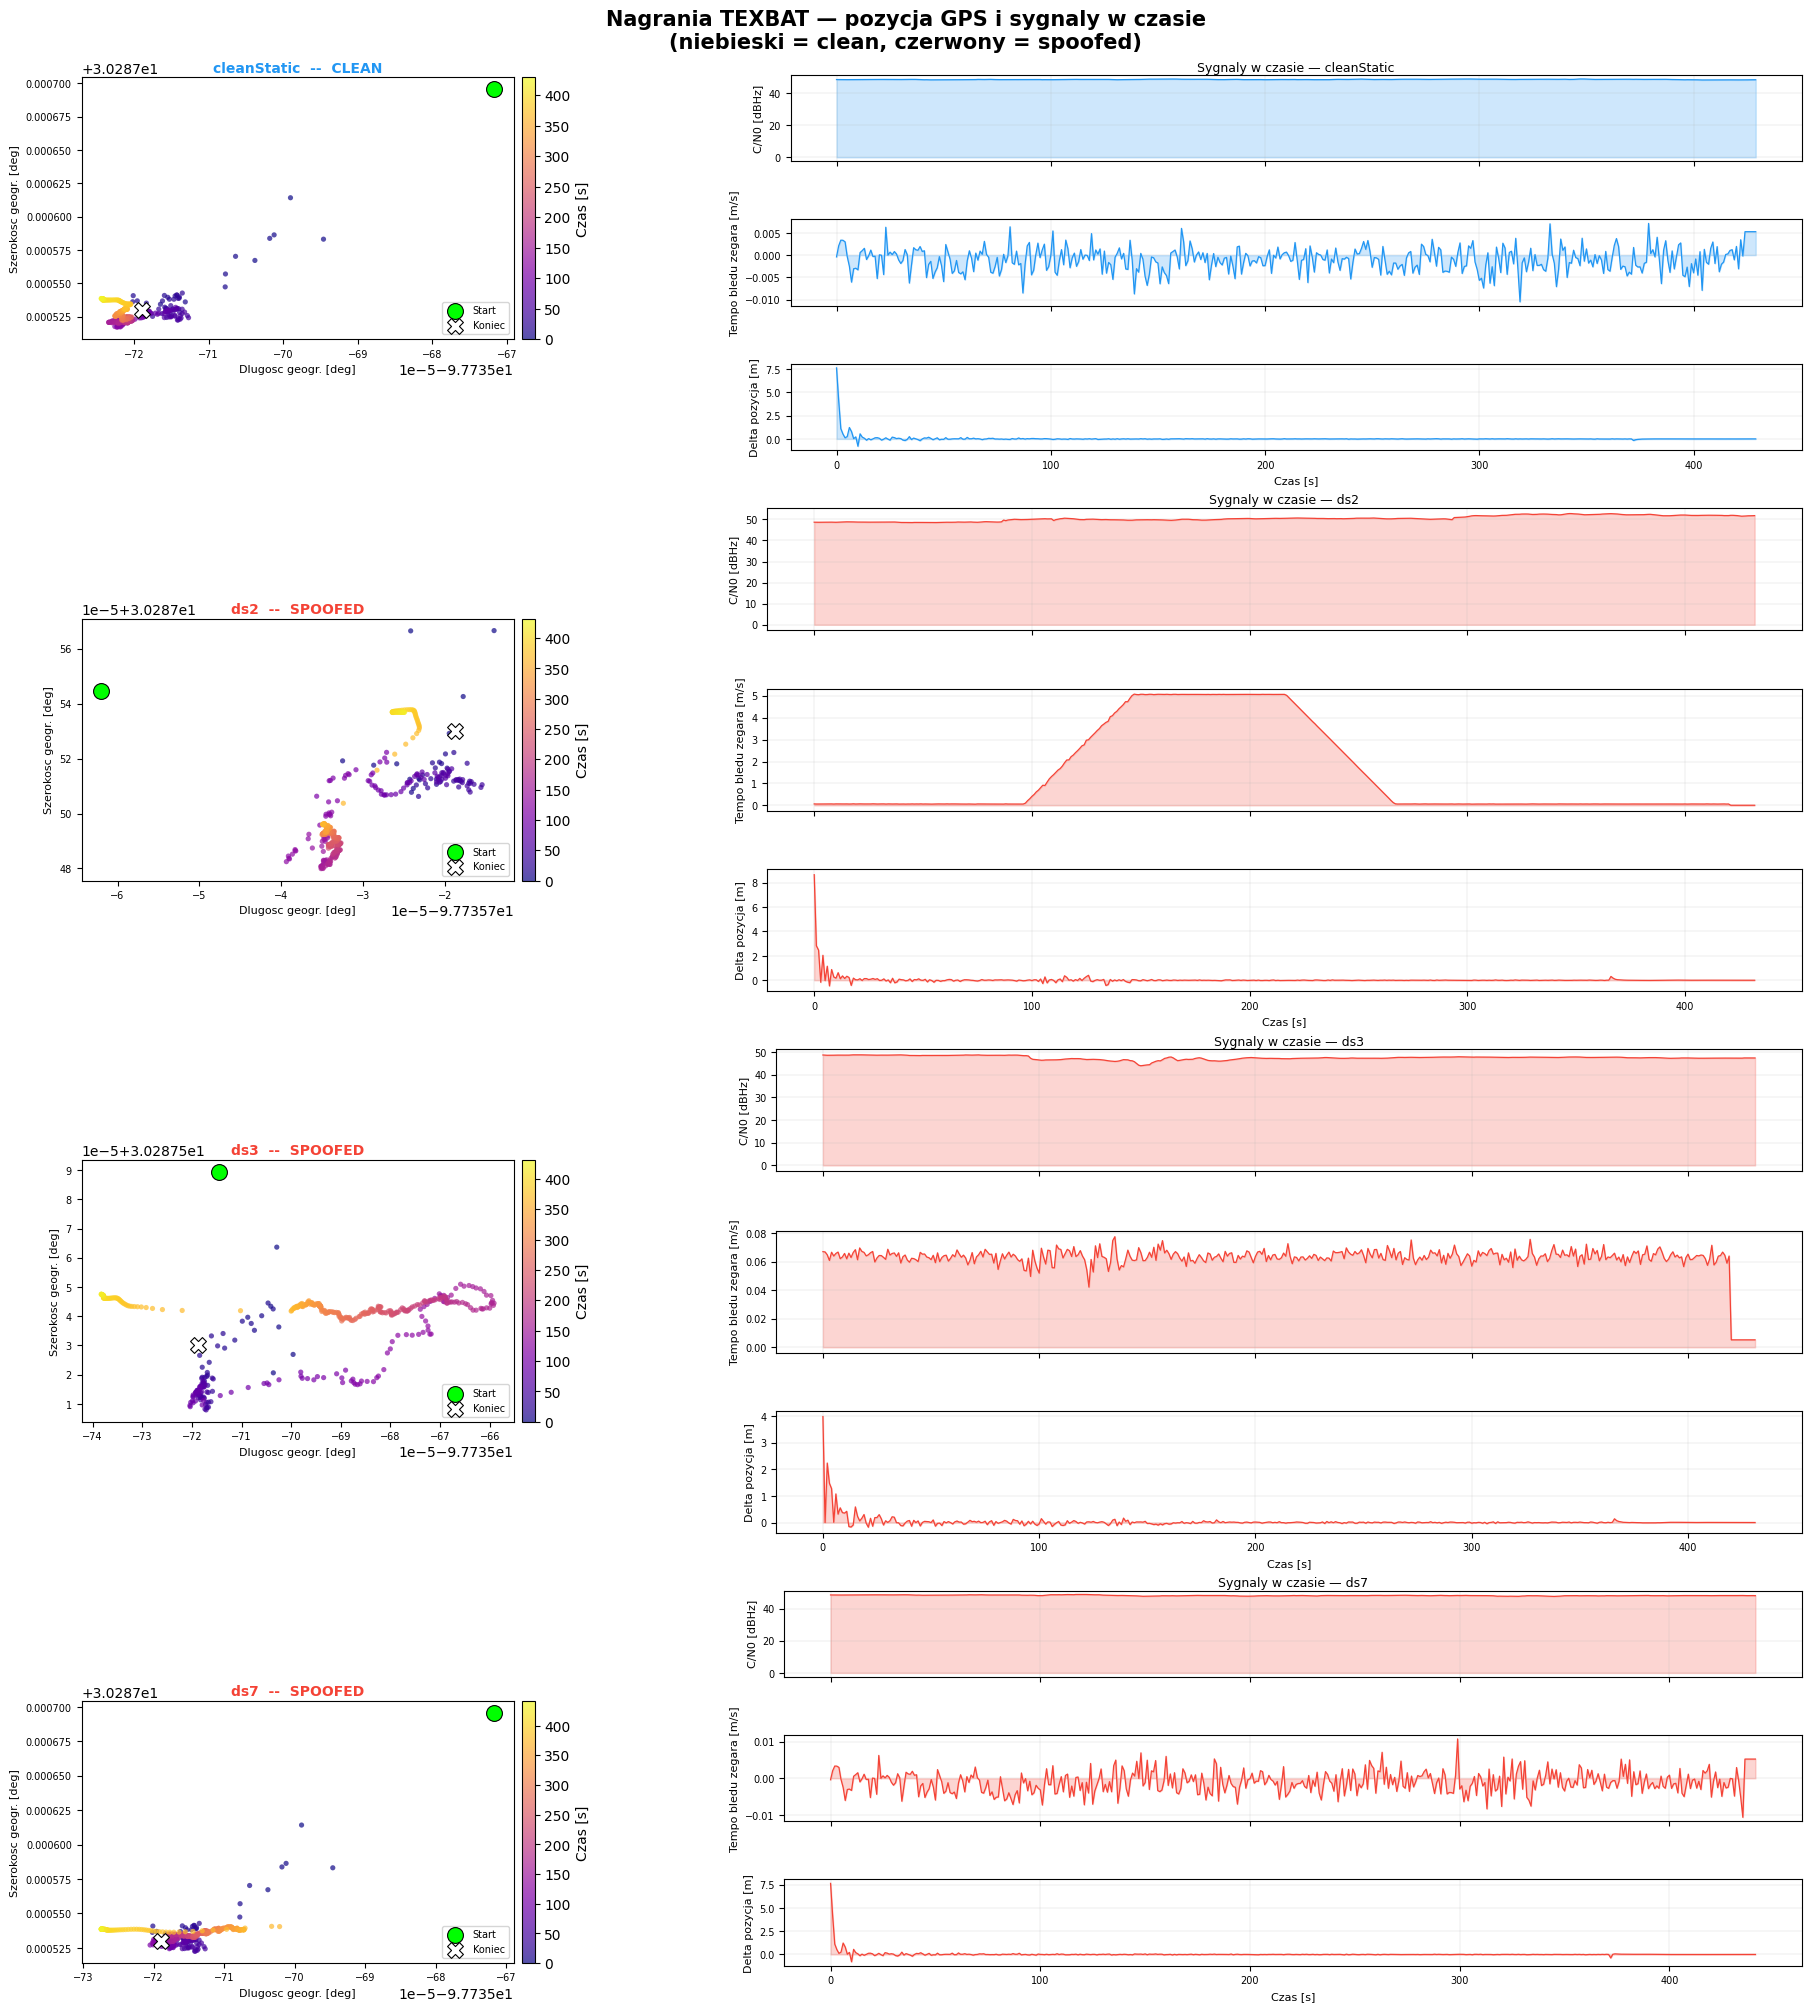

Rysunek 1 zapisany -> external_validation_outputs/viz_gps_tracks.png


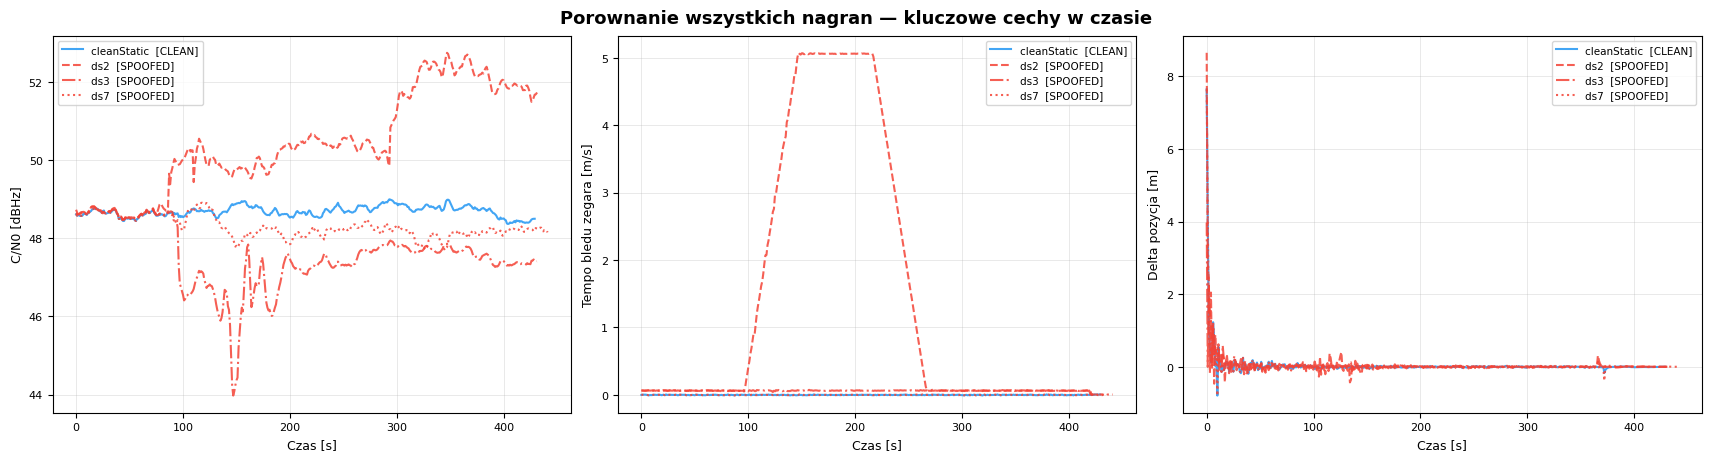

Rysunek 2 zapisany -> external_validation_outputs/viz_all_scenarios_comparison.png


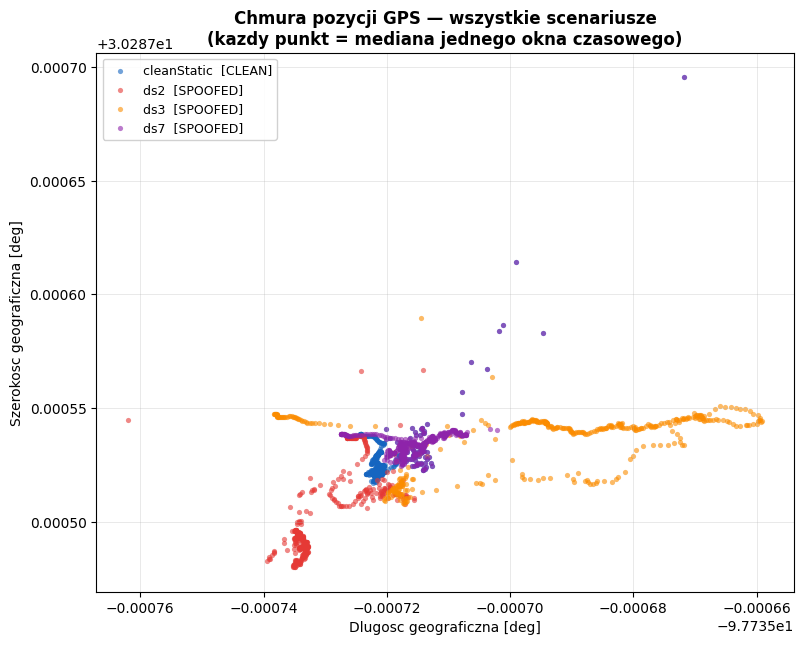

Rysunek 3 zapisany -> external_validation_outputs/viz_position_cloud.png


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

os.makedirs('external_validation_outputs', exist_ok=True)

# Załaduj dane (samodzielna sekcja, niezależna od wcześniejszych)
_df_viz = pd.read_csv('texbat_universal_features_v4/event_features_v4.csv')

SCENARIOS = ['cleanStatic', 'ds2', 'ds3', 'ds7']
SCENARIO_META = {
    'cleanStatic': {'label': 'cleanStatic  [CLEAN]',  'is_spoof': False},
    'ds2':         {'label': 'ds2  [SPOOFED]',        'is_spoof': True},
    'ds3':         {'label': 'ds3  [SPOOFED]',        'is_spoof': True},
    'ds7':         {'label': 'ds7  [SPOOFED]',        'is_spoof': True},
}
CLEAN_COLOR  = '#2196F3'
SPOOF_COLOR  = '#F44336'
SIGNAL_LABELS = ['C/N0 [dBHz]', 'Tempo bledu zegara [m/s]', 'Delta pozycja [m]']

# Agregacja mediany per przedział czasowy
_agg = (
    _df_viz.groupby(['scenario', 'time_bin'])
    .agg(
        lat=('latitude_deg',         'median'),
        lon=('longitude_deg',        'median'),
        cn0=('cn0_dbhz',             'median'),
        clk=('clock_error_rate_mps', 'median'),
        pos=('position_delta_m',     'median'),
    )
    .reset_index()
)

# ═══════════════════════════════════════════════════════════════════
# RYSUNEK 1 — Dashboard: pozycja GPS + sygnały per scenariusz
# ═══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 5 * len(SCENARIOS)), constrained_layout=True)
fig.suptitle(
    'Nagrania TEXBAT — pozycja GPS i sygnaly w czasie\n'
    '(niebieski = clean, czerwony = spoofed)',
    fontsize=15, fontweight='bold'
)
outer = gridspec.GridSpec(
    len(SCENARIOS), 2, figure=fig,
    width_ratios=[1, 2.5], hspace=0.45, wspace=0.3
)

for row_i, sc in enumerate(SCENARIOS):
    meta  = SCENARIO_META[sc]
    color = SPOOF_COLOR if meta['is_spoof'] else CLEAN_COLOR
    d     = _agg[_agg['scenario'] == sc].copy().sort_values('time_bin')

    # Panel lewy: chmura pozycji GPS
    ax_map = fig.add_subplot(outer[row_i, 0])
    sc_map = ax_map.scatter(
        d['lon'], d['lat'],
        c=d['time_bin'], cmap='plasma', s=14, alpha=0.70, linewidths=0
    )
    ax_map.scatter(d['lon'].iloc[0],  d['lat'].iloc[0],
                   s=130, color='lime',  zorder=5, label='Start',
                   edgecolors='black', linewidths=0.8)
    ax_map.scatter(d['lon'].iloc[-1], d['lat'].iloc[-1],
                   s=130, color='white', marker='X', zorder=5, label='Koniec',
                   edgecolors='black', linewidths=0.8)
    plt.colorbar(sc_map, ax=ax_map, label='Czas [s]', pad=0.01, fraction=0.046)
    ax_map.set_xlabel('Dlugosc geogr. [deg]', fontsize=8)
    ax_map.set_ylabel('Szerokosc geogr. [deg]', fontsize=8)
    status_txt = 'SPOOFED' if meta['is_spoof'] else 'CLEAN'
    ax_map.set_title(
        f'{sc}  --  {status_txt}',
        fontsize=10, fontweight='bold', color=color, pad=4
    )
    ax_map.legend(fontsize=7, loc='lower right')
    ax_map.tick_params(labelsize=7)

    # Panel prawy: trzy sygnaly w czasie
    inner = gridspec.GridSpecFromSubplotSpec(
        3, 1, subplot_spec=outer[row_i, 1], hspace=0.08
    )
    for sig_i, (sig_col, lbl) in enumerate(
        zip([d['cn0'], d['clk'], d['pos']], SIGNAL_LABELS)
    ):
        ax_s = fig.add_subplot(inner[sig_i])
        ax_s.fill_between(d['time_bin'], sig_col, alpha=0.22, color=color)
        ax_s.plot(d['time_bin'], sig_col, lw=0.9, color=color)
        ax_s.set_ylabel(lbl, fontsize=8)
        ax_s.tick_params(labelsize=7)
        ax_s.grid(True, lw=0.3, alpha=0.5)
        if sig_i == 0:
            ax_s.set_title(f'Sygnaly w czasie — {sc}', fontsize=9, pad=3)
        if sig_i < 2:
            ax_s.set_xticklabels([])
        else:
            ax_s.set_xlabel('Czas [s]', fontsize=8)

plt.savefig(
    'external_validation_outputs/viz_gps_tracks.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print("Rysunek 1 zapisany -> external_validation_outputs/viz_gps_tracks.png")

# ═══════════════════════════════════════════════════════════════════
# RYSUNEK 2 — Wszystkie scenariusze na jednym wykresie (3 cechy)
# ═══════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
fig2.suptitle(
    'Porownanie wszystkich nagran — kluczowe cechy w czasie',
    fontsize=13, fontweight='bold'
)
LINE_STYLES = {'cleanStatic': '-', 'ds2': '--', 'ds3': '-.', 'ds7': ':'}

for ax, sig_col, sig_lbl in zip(axes2, ['cn0', 'clk', 'pos'], SIGNAL_LABELS):
    for sc in SCENARIOS:
        meta  = SCENARIO_META[sc]
        color = SPOOF_COLOR if meta['is_spoof'] else CLEAN_COLOR
        d     = _agg[_agg['scenario'] == sc].sort_values('time_bin')
        ax.plot(
            d['time_bin'], d[sig_col],
            lw=1.5, color=color, linestyle=LINE_STYLES[sc],
            alpha=0.85, label=meta['label']
        )
    ax.set_xlabel('Czas [s]', fontsize=9)
    ax.set_ylabel(sig_lbl, fontsize=9)
    ax.grid(True, lw=0.4, alpha=0.5)
    ax.legend(fontsize=7.5)
    ax.tick_params(labelsize=8)

plt.savefig(
    'external_validation_outputs/viz_all_scenarios_comparison.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print("Rysunek 2 zapisany -> external_validation_outputs/viz_all_scenarios_comparison.png")

# ═══════════════════════════════════════════════════════════════════
# RYSUNEK 3 — Chmura pozycji GPS: wszystkie scenariusze razem
# ═══════════════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(9, 7))
ax3.set_title(
    'Chmura pozycji GPS — wszystkie scenariusze\n'
    '(kazdy punkt = mediana jednego okna czasowego)',
    fontsize=12, fontweight='bold'
)
SC_COLORS_IND = {
    'cleanStatic': '#1565C0',
    'ds2':         '#E53935',
    'ds3':         '#FB8C00',
    'ds7':         '#8E24AA',
}
for sc in SCENARIOS:
    d = _agg[_agg['scenario'] == sc]
    ax3.scatter(
        d['lon'], d['lat'],
        s=14, alpha=0.60,
        color=SC_COLORS_IND[sc],
        label=SCENARIO_META[sc]['label'],
        linewidths=0
    )

ax3.set_xlabel('Dlugosc geograficzna [deg]', fontsize=10)
ax3.set_ylabel('Szerokosc geograficzna [deg]', fontsize=10)
ax3.legend(fontsize=9, framealpha=0.9)
ax3.grid(True, lw=0.4, alpha=0.5)

plt.savefig(
    'external_validation_outputs/viz_position_cloud.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print("Rysunek 3 zapisany -> external_validation_outputs/viz_position_cloud.png")

## SEKCJA 22: Interaktywna mapa GPS — nagrania TEXBAT

Mapa renderuje sie inline ponizej (iframe). Mozna:
- **przyblizyc/oddalic** kolkiem myszy
- **wlaczyc/wylaczyc scenariusze** przez panel warstw (prawy gorny rog)
- **najechac** na punkt, by zobaczyc czas i wartosc bledu zegara

Trajektorie to polaczone punkty (mediana pozycji per okno 0.2 s). Kolko = start, kwadrat = koniec. Kolor = scenariusz.

In [76]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MeasureControl
from IPython.display import display

# ── dane ──────────────────────────────────────────────────────────
_df_map = pd.read_csv('texbat_universal_features_v4/event_features_v4.csv')

_agg_map = (
    _df_map.groupby(['scenario', 'time_bin'])
    .agg(
        lat=('latitude_deg',         'median'),
        lon=('longitude_deg',        'median'),
        label=('label_spoofed_scenario', 'first'),
        clk=('clock_error_rate_mps', 'median'),
        cn0=('cn0_dbhz',             'median'),
    )
    .reset_index()
    .sort_values(['scenario', 'time_bin'])
)

SC_STYLE = {
    'cleanStatic': {'color': '#1565C0', 'label': 'cleanStatic [CLEAN]',  'is_spoof': False},
    'ds2':         {'color': '#E53935', 'label': 'ds2 [SPOOFED]',        'is_spoof': True},
    'ds3':         {'color': '#FB8C00', 'label': 'ds3 [SPOOFED]',        'is_spoof': True},
    'ds7':         {'color': '#8E24AA', 'label': 'ds7 [SPOOFED]',        'is_spoof': True},
}
SCENARIOS = list(SC_STYLE.keys())

center = [_agg_map['lat'].mean(), _agg_map['lon'].mean()]

m = folium.Map(
    location=center,
    zoom_start=19,
    tiles='CartoDB positron',
    width='100%',
    height='600px',
)

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri',
    name='Satelita (Esri)',
    overlay=False,
    control=True,
).add_to(m)

for sc in SCENARIOS:
    style = SC_STYLE[sc]
    color = style['color']
    d = _agg_map[_agg_map['scenario'] == sc].reset_index(drop=True)

    group = folium.FeatureGroup(name=style['label'], show=True)

    coords = list(zip(d['lat'], d['lon']))
    folium.PolyLine(
        coords,
        color=color,
        weight=2.5,
        opacity=0.65,
        tooltip=f"{sc}  — trajektoria",
    ).add_to(group)

    folium.CircleMarker(
        location=[d['lat'].iloc[0], d['lon'].iloc[0]],
        radius=7,
        color='black',
        fill=True,
        fill_color=color,
        fill_opacity=1.0,
        tooltip=f"{sc} | START | t={d['time_bin'].iloc[0]:.1f}s",
    ).add_to(group)

    folium.RegularPolygonMarker(
        location=[d['lat'].iloc[-1], d['lon'].iloc[-1]],
        number_of_sides=4,
        radius=7,
        color='black',
        fill=True,
        fill_color=color,
        fill_opacity=1.0,
        rotation=45,
        tooltip=f"{sc} | KONIEC | t={d['time_bin'].iloc[-1]:.1f}s",
    ).add_to(group)

    for _, row in d.iloc[::10].iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=4,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.55,
            weight=1,
            tooltip=(
                f"{sc}<br>"
                f"t = {row['time_bin']:.1f} s<br>"
                f"clk_rate = {row['clk']:.4f} m/s<br>"
                f"C/N0 = {row['cn0']:.1f} dBHz"
            ),
        ).add_to(group)

    group.add_to(m)

legend_items = [
    ("#1565C0", "cleanStatic", "CLEAN"),
    ("#E53935", "ds2",         "SPOOFED"),
    ("#FB8C00", "ds3",         "SPOOFED"),
    ("#8E24AA", "ds7",         "SPOOFED"),
]
rows = "".join(
    f'<span style="color:{c}">&#9679;</span> {sc} <b>[{st}]</b><br>'
    for c, sc, st in legend_items
)
legend_html = (
    '<div style="position:fixed;bottom:30px;left:30px;'
    'background:rgba(255,255,255,0.92);border:1px solid #ccc;'
    'border-radius:8px;padding:10px 14px;font-family:monospace;'
    'font-size:13px;z-index:9999;box-shadow:2px 2px 6px rgba(0,0,0,0.2);">'
    '<b>Nagrania TEXBAT</b><br>'
    + rows +
    '<hr style="margin:5px 0">'
    '&#9679; = punkt co 10 okien &nbsp; &#9632; = koniec'
    '</div>'
)
m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl(collapsed=False).add_to(m)
MeasureControl(primary_length_unit='meters').add_to(m)

display(m)
